In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
root_folder = r"E:\D Drive\SEM-6\project\Dataset"

In [3]:
def explore_dataset(root_folder):
    patients = sorted([f for f in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, f))])
    dataset_info = []

    for patient in patients:
        data_path = os.path.join(root_folder, patient, "EYEDIAP", "Data")
        if not os.path.exists(data_path):
            print(f"Data folder not found for {patient}, skipping.")
            continue

        subfolders = sorted([f for f in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, f))])

        for sub in subfolders:
            sub_path = os.path.join(data_path, sub)
            files = os.listdir(sub_path)

            rgb_file = [f for f in files if "rgb_hd.mov" in f]
            eye_file = [f for f in files if "eye_tracking.txt" in f]
            gaze_file = [f for f in files if "screen_coordinates.txt" in f]
            head_file = [f for f in files if "head_pose.txt" in f]

            dataset_info.append({
                "Patient": patient,
                "Task": sub,
                "RGB_Video": rgb_file[0] if rgb_file else None,
                "Eye_Tracking": eye_file[0] if eye_file else None,
                "Screen_Coords": gaze_file[0] if gaze_file else None,
                "Head_Pose": head_file[0] if head_file else None
            })

    df_info = pd.DataFrame(dataset_info)
    return df_info

In [4]:
dataset_df = explore_dataset(root_folder)
print("Dataset Overview:")
print(dataset_df.head(20))

Data folder not found for EYEDIAP_GazeStateAnnotations, skipping.
Data folder not found for EYEDIAP_documentation, skipping.
Data folder not found for Eye_Crops, skipping.
Dataset Overview:
      Patient       Task   RGB_Video      Eye_Tracking  \
0    EYEDIAP1   1_A_CS_M  rgb_hd.mov  eye_tracking.txt   
1    EYEDIAP1   1_A_CS_S  rgb_hd.mov  eye_tracking.txt   
2    EYEDIAP1   1_A_DS_M  rgb_hd.mov  eye_tracking.txt   
3    EYEDIAP1   1_A_DS_S  rgb_hd.mov  eye_tracking.txt   
4    EYEDIAP1   1_A_FT_M  rgb_hd.mov  eye_tracking.txt   
5    EYEDIAP1   1_A_FT_S  rgb_hd.mov  eye_tracking.txt   
6   EYEDIAP10  10_A_CS_M  rgb_hd.mov  eye_tracking.txt   
7   EYEDIAP10  10_A_CS_S  rgb_hd.mov  eye_tracking.txt   
8   EYEDIAP10  10_A_DS_M  rgb_hd.mov  eye_tracking.txt   
9   EYEDIAP10  10_A_DS_S  rgb_hd.mov  eye_tracking.txt   
10  EYEDIAP10  10_A_FT_M  rgb_hd.mov  eye_tracking.txt   
11  EYEDIAP10  10_A_FT_S  rgb_hd.mov  eye_tracking.txt   
12  EYEDIAP11  11_A_CS_M  rgb_hd.mov  eye_tracking.txt  

In [5]:
def play_video(video_path, max_frames=100):
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imshow('Video Preview', frame)
        if cv2.waitKey(30) & 0xFF == ord('q'):
            break
        frame_count += 1
    cap.release()
    cv2.destroyAllWindows()

In [6]:
example_video_path = os.path.join(
    root_folder,
    dataset_df.iloc[0]['Patient'],
    "EYEDIAP",
    "Data",
    dataset_df.iloc[0]['Task'],
    dataset_df.iloc[0]['RGB_Video']
)

print(f"Playing example video: {example_video_path}")
play_video(example_video_path, max_frames=50)

Playing example video: E:\D Drive\SEM-6\project\Dataset\EYEDIAP1\EYEDIAP\Data\1_A_CS_M\rgb_hd.mov


In [7]:
def plot_gaze(gaze_file_path, x_col=1, y_col=2):
    """
    Plots gaze points from EYEDIAP screen_coordinates.txt
    x_col, y_col: the indices of columns containing screen X and Y
    """
    if not os.path.exists(gaze_file_path):
        print(f"Gaze file not found: {gaze_file_path}")
        return

    # Read file (tab or space separated)
    try:
        gaze = pd.read_csv(gaze_file_path, sep='\t', header=None)
    except:
        gaze = pd.read_csv(gaze_file_path, sep=' ', header=None)
    
    # Check if requested columns exist
    if gaze.shape[1] <= max(x_col, y_col):
        print(f"File has {gaze.shape[1]} columns, cannot use columns {x_col} and {y_col}")
        print(gaze.head())
        return
    
    x = gaze.iloc[:, x_col]
    y = gaze.iloc[:, y_col]

    plt.figure(figsize=(6,6))
    plt.scatter(x, y, c='red', s=10)
    plt.title('Gaze Points Distribution')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.gca().invert_yaxis()  # screen coordinates
    plt.show()

In [8]:
example_gaze_file = os.path.join(
    root_folder,
    dataset_df.iloc[0]['Patient'],
    "EYEDIAP",
    "Data",
    dataset_df.iloc[0]['Task'],
    dataset_df.iloc[0]['Screen_Coords']
)

# In EYEDIAP, usually column 1 = x, column 2 = y
plot_gaze(example_gaze_file, x_col=1, y_col=2)

File has 1 columns, cannot use columns 1 and 2
                                                   0
0  Screen target coordinates: 2D coordinates (x,y...
1         0;413.0000;477.0000;0.1165;-0.1441;-0.0632
2         1;416.0000;474.0000;0.1154;-0.1451;-0.0630
3         2;419.0000;472.0000;0.1143;-0.1457;-0.0629
4         3;422.0000;469.0000;0.1132;-0.1467;-0.0627


In [9]:
import sys
print(sys.executable)

e:\D Drive\SEM-6\RM\tf_env\Scripts\python.exe


In [10]:
import cv2
import os
import pandas as pd
import numpy as np

In [11]:
root_folder = r"E:\D Drive\SEM-6\project\Dataset"  # your dataset path
output_eye_folder = os.path.join(root_folder, "Eye_Crops")
os.makedirs(output_eye_folder, exist_ok=True)

In [12]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

In [13]:
EYE_SIZE = (64, 64)

In [14]:
def normalize_coordinates(x, y, screen_w=1920, screen_h=1080):
    """
    Normalize gaze coordinates to [0,1] scale
    """
    return x / screen_w, y / screen_h

In [15]:
def extract_frames(video_path, max_frames=None, resize_dim=(640, 480), brightness=1.0, contrast=1.0):
    """
    Extract frames from video, apply normalization
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Resize
        frame = cv2.resize(frame, resize_dim)
        # Brightness/contrast adjustment
        frame = cv2.convertScaleAbs(frame, alpha=contrast, beta=brightness)

        frames.append(frame)
        frame_idx += 1
        if max_frames and frame_idx >= max_frames:
            break

    cap.release()
    return frames

In [16]:
def detect_and_crop_eyes(frame):
    """
    Detect face and eyes, return list of eye crops
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    eyes_crops = []

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray)
        for i, (ex, ey, ew, eh) in enumerate(eyes[:2]):  # max 2 eyes
            eye_crop = roi_color[ey:ey+eh, ex:ex+ew]
            eye_crop = cv2.resize(eye_crop, EYE_SIZE)
            eyes_crops.append(eye_crop)

    return eyes_crops

In [17]:
def load_gaze_coordinates(gaze_file, screen_file):
    """Load and normalize gaze coordinates"""
    if not os.path.exists(gaze_file) or not os.path.exists(screen_file):
        print(f"Gaze or screen file missing: {gaze_file}")
        return None

    try:
        gaze_df = pd.read_csv(gaze_file, sep='\t', header=None)
        if gaze_df.shape[1] < 2:
            print(f"Unexpected gaze file format ({gaze_file}), shape: {gaze_df.shape}")
            return None
    except:
        print(f"Failed to read gaze file: {gaze_file}")
        return None

    # Normalize coordinates
    screen_w, screen_h = 1920, 1080  # adjust if needed
    gaze_norm = []
    for i in range(len(gaze_df)):
        try:
            x, y = float(gaze_df.iloc[i, 0]), float(gaze_df.iloc[i, 1])
            x_n, y_n = normalize_coordinates(x, y, screen_w, screen_h)
            gaze_norm.append((x_n, y_n))
        except:
            gaze_norm.append((None, None))
    return gaze_norm

In [18]:
def load_head_pose(head_pose_file):
    """Load head pose data if available"""
    if os.path.exists(head_pose_file):
        try:
            return pd.read_csv(head_pose_file, sep='\t', header=None)
        except:
            print(f"Failed to read head_pose file: {head_pose_file}")
            return None
    return None

# -------------------------------
# Process a single session
# -------------------------------
def process_session(session_folder, max_frames=None):
    video_path = os.path.join(session_folder, "rgb_hd.mov")
    gaze_file = os.path.join(session_folder, "eye_tracking.txt")
    screen_file = os.path.join(session_folder, "screen_coordinates.txt")
    head_pose_file = os.path.join(session_folder, "head_pose.txt")

    if not os.path.exists(video_path):
        print(f"Video not found: {video_path}")
        return None

    frames = extract_frames(video_path, max_frames=max_frames)
    gaze_coords = load_gaze_coordinates(gaze_file, screen_file)
    head_pose = load_head_pose(head_pose_file)

    eye_data = []

    for idx, frame in enumerate(frames):
        eye_crops = detect_and_crop_eyes(frame)

        # Align gaze if available
        gaze = gaze_coords[idx] if gaze_coords and idx < len(gaze_coords) else (None, None)

        eye_data.append({
            "frame_idx": idx,
            "eye_crops": eye_crops,
            "gaze": gaze
        })

        # Save eye crops
        for i, crop in enumerate(eye_crops):
            crop_name = f"{os.path.basename(session_folder)}_frame{idx}_eye{i}.png"
            cv2.imwrite(os.path.join(output_eye_folder, crop_name), crop)

    print(f"Processed session: {session_folder}, frames: {len(frames)}")
    return eye_data, gaze_coords, head_pose

# -------------------------------
# Process all patients & sessions
# -------------------------------
for patient in os.listdir(root_folder):
    patient_path = os.path.join(root_folder, patient, "EYEDIAP", "Data")
    if not os.path.exists(patient_path):
        continue

    for session in os.listdir(patient_path):
        session_folder = os.path.join(patient_path, session)
        process_session(session_folder, max_frames=200)  # limit frames for speed

Unexpected gaze file format (E:\D Drive\SEM-6\project\Dataset\EYEDIAP1\EYEDIAP\Data\1_A_CS_M\eye_tracking.txt), shape: (4458, 1)
Processed session: E:\D Drive\SEM-6\project\Dataset\EYEDIAP1\EYEDIAP\Data\1_A_CS_M, frames: 200
Unexpected gaze file format (E:\D Drive\SEM-6\project\Dataset\EYEDIAP1\EYEDIAP\Data\1_A_CS_S\eye_tracking.txt), shape: (4458, 1)
Processed session: E:\D Drive\SEM-6\project\Dataset\EYEDIAP1\EYEDIAP\Data\1_A_CS_S, frames: 200
Unexpected gaze file format (E:\D Drive\SEM-6\project\Dataset\EYEDIAP1\EYEDIAP\Data\1_A_DS_M\eye_tracking.txt), shape: (4466, 1)
Processed session: E:\D Drive\SEM-6\project\Dataset\EYEDIAP1\EYEDIAP\Data\1_A_DS_M, frames: 200
Unexpected gaze file format (E:\D Drive\SEM-6\project\Dataset\EYEDIAP1\EYEDIAP\Data\1_A_DS_S\eye_tracking.txt), shape: (4466, 1)
Processed session: E:\D Drive\SEM-6\project\Dataset\EYEDIAP1\EYEDIAP\Data\1_A_DS_S, frames: 200
Gaze or screen file missing: E:\D Drive\SEM-6\project\Dataset\EYEDIAP1\EYEDIAP\Data\1_A_FT_M\eye_tra

In [21]:
import os
import shutil
import re
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
source_folder = r"E:\D Drive\SEM-6\project\Dataset\Eye_Crops"  # flat eye images
output_root = r"E:\D Drive\SEM-6\project\Dataset\eye_crops"
dataset_root = r"E:\D Drive\SEM-6\project\Dataset"  # contains EYEDIAP1..16 folders

os.makedirs(output_root, exist_ok=True)

# -----------------------------
# Helper functions
# -----------------------------
def parse_filename(fname):
    """Parse filenames like 8_A_DS_M_frame35_eye0.png"""
    match = re.match(r"(\d+_[A-Z]+_[A-Z]+_[A-Z]+)_frame(\d+)_eye([01])\.png", fname)
    if match:
        session, frame_no, eye_no = match.groups()
        return session, int(frame_no), int(eye_no)
    else:
        return None, None, None

def load_coordinates(file_path, coord_type="screen"):
    """
    Load coordinates robustly:
    - coord_type = 'screen' for screen_coordinates.txt
    - coord_type = 'ball' for ball_tracking.txt
    Returns dataframe with columns ['x','y']
    """
    coords = []
    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            line = line.strip()
            if not line or line.lower().startswith("screen") or line.lower().startswith("floating"):
                continue
            parts = line.split(";")
            if coord_type == "screen":
                # Take HD camera 2D coordinates (columns 1,2)
                if len(parts) >= 3:
                    try:
                        x = float(parts[1])
                        y = float(parts[2])
                        coords.append([x, y])
                    except:
                        continue
            elif coord_type == "ball":
                # Take HD target 2D coordinates (columns 5,6)
                if len(parts) >= 7:
                    try:
                        x = float(parts[5])
                        y = float(parts[6])
                        coords.append([x, y])
                    except:
                        continue
    if coords:
        df = pd.DataFrame(coords, columns=['x','y'])
        return df
    else:
        return None

# -----------------------------
# Process all images
# -----------------------------
files = sorted(os.listdir(source_folder))
gaze_dict = {}  # session -> True/False (processed)

for f in files:
    session, frame_no, eye_no = parse_filename(f)
    if session is None:
        continue

    # -----------------------------
    # Create patient/session folders
    # -----------------------------
    patient_id = session.split('_')[0]
    patient_folder = os.path.join(output_root, f"EYEDIAP{patient_id}")
    session_folder = os.path.join(patient_folder, session)
    left_folder = os.path.join(session_folder, "left")
    right_folder = os.path.join(session_folder, "right")
    os.makedirs(left_folder, exist_ok=True)
    os.makedirs(right_folder, exist_ok=True)

    # -----------------------------
    # Copy images to proper folder
    # -----------------------------
    src = os.path.join(source_folder, f)
    if eye_no == 0:
        dst = os.path.join(left_folder, f"frame{frame_no:04d}.png")
    else:
        dst = os.path.join(right_folder, f"frame{frame_no:04d}.png")
    shutil.copy2(src, dst)

    # -----------------------------
    # Process gaze coordinates for this session
    # -----------------------------
    if session not in gaze_dict:
        sc_file = os.path.join(dataset_root, f"EYEDIAP{patient_id}", "EYEDIAP", "Data", session, "screen_coordinates.txt")
        ball_file = os.path.join(dataset_root, f"EYEDIAP{patient_id}", "EYEDIAP", "Data", session, "ball_tracking.txt")

        if os.path.exists(sc_file):
            df = load_coordinates(sc_file, "screen")
        elif os.path.exists(ball_file):
            df = load_coordinates(ball_file, "ball")
        else:
            df = None

        if df is not None:
            # Normalize 0-1
            screen_w, screen_h = 1920, 1080
            df['x'] = df['x'] / screen_w
            df['y'] = df['y'] / screen_h
            df.to_csv(os.path.join(session_folder, 'gaze_norm.csv'), index=False)
            gaze_dict[session] = True
        else:
            print(f"⚠️ No usable coordinates for session {session}")
            gaze_dict[session] = False

print("✅ Dataset reorganization complete. Ready for Phase 3!")

✅ Dataset reorganization complete. Ready for Phase 3!


In [31]:
import os
import pandas as pd
import re

# -----------------------------
dataset_root = r"E:\D Drive\SEM-6\project\Dataset"
eye_crops_root = r"E:\D Drive\SEM-6\project\Dataset\eye_crop"
screen_w, screen_h = 1920, 1080
# -----------------------------

def load_coordinates(file_path, coord_type="screen"):
    coords = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.lower().startswith(("screen","floating")):
                continue
            parts = line.split(";")
            try:
                if coord_type == "screen" and len(parts) >= 3:
                    coords.append([float(parts[1]), float(parts[2])])
                elif coord_type == "ball" and len(parts) >= 7:
                    coords.append([float(parts[5]), float(parts[6])])
            except:
                continue
    return pd.DataFrame(coords, columns=["x","y"]) if coords else None

# -----------------------------
# Iterate over patients and sessions
# -----------------------------
patients = sorted(os.listdir(eye_crops_root))
for patient in patients:
    patient_path = os.path.join(eye_crops_root, patient)
    if not os.path.isdir(patient_path):
        continue
    for session in sorted(os.listdir(patient_path)):
        session_path = os.path.join(patient_path, session)
        left_folder = os.path.join(session_path, "left")
        right_folder = os.path.join(session_path, "right")

        # Skip if no left/right frames
        if not os.path.isdir(left_folder) or not os.path.isdir(right_folder):
            continue

        left_frames = sorted(os.listdir(left_folder))
        right_frames = sorted(os.listdir(right_folder))
        n_frames = min(len(left_frames), len(right_frames))

        # Load coordinates
        patient_id = patient.replace("EYEDIAP","")
        sc_file = os.path.join(dataset_root, f"EYEDIAP{patient_id}", "EYEDIAP", "Data", session, "screen_coordinates.txt")
        ball_file = os.path.join(dataset_root, f"EYEDIAP{patient_id}", "EYEDIAP", "Data", session, "ball_tracking.txt")

        if os.path.exists(sc_file):
            df = load_coordinates(sc_file, "screen")
        elif os.path.exists(ball_file):
            df = load_coordinates(ball_file, "ball")
        else:
            df = None

        if df is None or len(df) == 0:
            print(f"⚠️ No usable coordinates for session {session}")
            continue

        # Keep only frames that exist
        df = df.iloc[:n_frames]

        # Normalize
        df["x"] = df["x"] / screen_w
        df["y"] = df["y"] / screen_h

        # Save
        df.to_csv(os.path.join(session_path, "gaze_norm.csv"), index=False)
        print(f"✅ Gaze CSV ready for session {session}, frames: {n_frames}")

print("✅ All sessions processed!")

✅ Gaze CSV ready for session 1_A_CS_M, frames: 105
✅ Gaze CSV ready for session 1_A_CS_S, frames: 198
✅ Gaze CSV ready for session 1_A_DS_M, frames: 114
✅ Gaze CSV ready for session 1_A_DS_S, frames: 196
✅ Gaze CSV ready for session 1_A_FT_M, frames: 52
✅ Gaze CSV ready for session 1_A_FT_S, frames: 80
✅ Gaze CSV ready for session 10_A_CS_M, frames: 139
✅ Gaze CSV ready for session 10_A_CS_S, frames: 128
✅ Gaze CSV ready for session 10_A_DS_M, frames: 163
✅ Gaze CSV ready for session 10_A_DS_S, frames: 97
✅ Gaze CSV ready for session 10_A_FT_M, frames: 57
✅ Gaze CSV ready for session 10_A_FT_S, frames: 105
✅ Gaze CSV ready for session 11_A_CS_M, frames: 165
✅ Gaze CSV ready for session 11_A_CS_S, frames: 193
✅ Gaze CSV ready for session 11_A_DS_M, frames: 163
✅ Gaze CSV ready for session 11_A_DS_S, frames: 200
✅ Gaze CSV ready for session 11_A_FT_M, frames: 52
✅ Gaze CSV ready for session 11_A_FT_S, frames: 86
✅ Gaze CSV ready for session 12_B_FT_M, frames: 98
✅ Gaze CSV ready for sess

In [32]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np

In [40]:
class EyeGazeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        
        for patient in sorted(os.listdir(root_dir)):
            patient_path = os.path.join(root_dir, patient)
            if not os.path.isdir(patient_path):
                continue
            for session in sorted(os.listdir(patient_path)):
                session_path = os.path.join(patient_path, session)
                gaze_file = os.path.join(session_path, "gaze_norm.csv")
                left_folder = os.path.join(session_path, "left")
                right_folder = os.path.join(session_path, "right")

                if not os.path.exists(gaze_file):
                    continue

                df = pd.read_csv(gaze_file)
                left_frames = sorted(os.listdir(left_folder))
                right_frames = sorted(os.listdir(right_folder))
                n_frames = min(len(df), len(left_frames), len(right_frames))

                for i in range(n_frames):
                    self.samples.append({
                        "left_img": os.path.join(left_folder, left_frames[i]),
                        "right_img": os.path.join(right_folder, right_frames[i]),
                        "gaze": df.iloc[i].values
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        left_img = Image.open(sample["left_img"]).convert("L")
        right_img = Image.open(sample["right_img"]).convert("L")
        gaze = torch.tensor(sample["gaze"], dtype=torch.float32)
        
        if self.transform:
            left_img = self.transform(left_img)   # shape [1, H, W]
            right_img = self.transform(right_img) # shape [1, H, W]

        # remove the singleton channel dimension
            left_img = left_img.squeeze(0)        # now shape [H, W]
            right_img = right_img.squeeze(0)      # now shape [H, W]

    # Stack left + right: shape [2, H, W]
        img = torch.stack([left_img, right_img], dim=0)
        return {"image": img, "gaze": gaze}

In [41]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

In [42]:
dataset = EyeGazeDataset(root_dir=r"E:\D Drive\SEM-6\project\Dataset\eye_crop", transform=transform)

# Example: 80% train, 10% val, 10% test
total_len = len(dataset)
train_len = int(0.8 * total_len)
val_len = int(0.1 * total_len)
test_len = total_len - train_len - val_len

train_ds, val_ds, test_ds = random_split(dataset, [train_len, val_len, test_len])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [43]:
class GazeCNN(nn.Module):
    def __init__(self):
        super(GazeCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1),  # 2-channel input (left+right)
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, 2)  # Output: x, y gaze
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GazeCNN().to(device)

In [44]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [45]:
epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        images = batch["image"].to(device)
        gaze = batch["gaze"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, gaze)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device)
            gaze = batch["gaze"].to(device)
            outputs = model(images)
            loss = criterion(outputs, gaze)
            val_loss += loss.item() * images.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

Epoch [1/20] Train Loss: 0.056214, Val Loss: 0.049757
Epoch [2/20] Train Loss: 0.048632, Val Loss: 0.043936
Epoch [3/20] Train Loss: 0.044701, Val Loss: 0.040238
Epoch [4/20] Train Loss: 0.042271, Val Loss: 0.039377
Epoch [5/20] Train Loss: 0.039775, Val Loss: 0.040838
Epoch [6/20] Train Loss: 0.038048, Val Loss: 0.034849
Epoch [7/20] Train Loss: 0.034994, Val Loss: 0.034668
Epoch [8/20] Train Loss: 0.033775, Val Loss: 0.034601
Epoch [9/20] Train Loss: 0.031894, Val Loss: 0.034274
Epoch [10/20] Train Loss: 0.030349, Val Loss: 0.034345
Epoch [11/20] Train Loss: 0.028721, Val Loss: 0.032693
Epoch [12/20] Train Loss: 0.027724, Val Loss: 0.031027
Epoch [13/20] Train Loss: 0.026249, Val Loss: 0.030704
Epoch [14/20] Train Loss: 0.024861, Val Loss: 0.030024
Epoch [15/20] Train Loss: 0.024062, Val Loss: 0.030460
Epoch [16/20] Train Loss: 0.023094, Val Loss: 0.027687
Epoch [17/20] Train Loss: 0.021781, Val Loss: 0.026916
Epoch [18/20] Train Loss: 0.020998, Val Loss: 0.026621
Epoch [19/20] Train

In [55]:
torch.save(model.state_dict(), r"E:\D Drive\SEM-6\project\gaze_models\best_gaze_model.pth")
print("✅ Model saved as best_gaze_model.pth")


✅ Model saved as best_gaze_model.pth


In [57]:
def euclidean_error(pred, true):
    return torch.sqrt(((pred - true)**2).sum(dim=1))

model.eval()
errors = []
with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        gaze = batch["gaze"].to(device)
        outputs = model(images)
        errors.append(euclidean_error(outputs, gaze).cpu().numpy())

errors = np.concatenate(errors)
print(f"Mean Euclidean gaze error: {errors.mean():.4f}")

KeyError: 'image'

## CNN + LSTM

In [66]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np

In [67]:
SEQ_LEN = 5           # number of consecutive frames per sample
BATCH_SIZE = 16
LR = 1e-4
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SCREEN_W, SCREEN_H = 1920, 1080

In [68]:
class EyeGazeSequenceDataset(Dataset):
    def __init__(self, root_dir, transform=None, seq_len=SEQ_LEN):
        self.samples = []
        self.transform = transform
        self.seq_len = seq_len

        for patient in sorted(os.listdir(root_dir)):
            patient_path = os.path.join(root_dir, patient)
            if not os.path.isdir(patient_path):
                continue
            for session in sorted(os.listdir(patient_path)):
                session_path = os.path.join(patient_path, session)
                gaze_file = os.path.join(session_path, "gaze_norm.csv")
                left_folder = os.path.join(session_path, "left")
                right_folder = os.path.join(session_path, "right")

                if not os.path.exists(gaze_file):
                    continue

                df = pd.read_csv(gaze_file)
                left_frames = sorted(os.listdir(left_folder))
                right_frames = sorted(os.listdir(right_folder))
                n_frames = min(len(df), len(left_frames), len(right_frames))

                # Generate sequences
                for i in range(n_frames - seq_len + 1):
                    seq_left = [os.path.join(left_folder, left_frames[i+j]) for j in range(seq_len)]
                    seq_right = [os.path.join(right_folder, right_frames[i+j]) for j in range(seq_len)]
                    seq_gaze = df.iloc[i:i+seq_len].values
                    self.samples.append({"left_seq": seq_left, "right_seq": seq_right, "gaze_seq": seq_gaze})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        seq_imgs = []
        for l, r in zip(sample["left_seq"], sample["right_seq"]):
            left_img = Image.open(l).convert("L")
            right_img = Image.open(r).convert("L")
            if self.transform:
                left_img = self.transform(left_img)
                right_img = self.transform(right_img)
            # Concatenate left+right channels correctly: [2, H, W]
            img = torch.cat([left_img, right_img], dim=0)
            seq_imgs.append(img)
        seq_imgs = torch.stack(seq_imgs, dim=0)  # [seq_len, 2, H, W]
        gaze_seq = torch.tensor(sample["gaze_seq"], dtype=torch.float32)
        return {"image_seq": seq_imgs, "gaze_seq": gaze_seq}


In [69]:
transform = transforms.Compose([
    transforms.RandomResizedCrop(64, scale=(0.9,1.0)),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

In [70]:
class CNNLSTM(nn.Module):
    def __init__(self, seq_len=SEQ_LEN):
        super().__init__()
        self.seq_len = seq_len
        # CNN for per-frame feature extraction
        self.cnn = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        cnn_output_size = 32*16*16  # 64x64 input after 2 maxpool layers
        self.lstm = nn.LSTM(input_size=cnn_output_size, hidden_size=128, batch_first=True)
        self.fc = nn.Linear(128, 2)  # output gaze (x,y)

    def forward(self, x_seq):
        # Handle potential extra dimensions
        if x_seq.dim() == 6:  # [B, S, C, 1, H, W]
            B, S, C, _, H, W = x_seq.shape
            x_seq = x_seq.view(B, S, C, H, W)
        batch_size, seq_len, c, h, w = x_seq.shape
        cnn_out = []
        for t in range(seq_len):
            frame_feat = self.cnn(x_seq[:, t])  # [B, feat_dim]
            cnn_out.append(frame_feat)
        cnn_out = torch.stack(cnn_out, dim=1)  # [B, S, feat_dim]
        lstm_out, _ = self.lstm(cnn_out)      # [B, S, 128]
        gaze_pred = self.fc(lstm_out)         # [B, S, 2]
        return gaze_pred

In [71]:
dataset = EyeGazeSequenceDataset(root_dir=r"E:\D Drive\SEM-6\project\Dataset\eye_crop", transform=transform)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_set, val_set, test_set = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [72]:
model = CNNLSTM().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch in train_loader:
        imgs = batch["image_seq"].to(DEVICE)
        gaze = batch["gaze_seq"].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, gaze)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image_seq"].to(DEVICE)
            gaze = batch["gaze_seq"].to(DEVICE)
            val_loss += criterion(model(imgs), gaze).item()
    val_loss /= len(val_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {train_loss:.5f}, Val Loss: {val_loss:.5f}")


Epoch [1/20] Train Loss: 0.05302, Val Loss: 0.04650
Epoch [2/20] Train Loss: 0.04495, Val Loss: 0.04141
Epoch [3/20] Train Loss: 0.04040, Val Loss: 0.03914
Epoch [4/20] Train Loss: 0.03797, Val Loss: 0.03849
Epoch [5/20] Train Loss: 0.03557, Val Loss: 0.03379
Epoch [6/20] Train Loss: 0.03349, Val Loss: 0.03253
Epoch [7/20] Train Loss: 0.03168, Val Loss: 0.03081
Epoch [8/20] Train Loss: 0.02948, Val Loss: 0.02986
Epoch [9/20] Train Loss: 0.02797, Val Loss: 0.02720
Epoch [10/20] Train Loss: 0.02655, Val Loss: 0.02597
Epoch [11/20] Train Loss: 0.02551, Val Loss: 0.02531
Epoch [12/20] Train Loss: 0.02394, Val Loss: 0.02538
Epoch [13/20] Train Loss: 0.02326, Val Loss: 0.02315
Epoch [14/20] Train Loss: 0.02224, Val Loss: 0.02220
Epoch [15/20] Train Loss: 0.02113, Val Loss: 0.02109
Epoch [16/20] Train Loss: 0.02010, Val Loss: 0.02064
Epoch [17/20] Train Loss: 0.01935, Val Loss: 0.01957
Epoch [18/20] Train Loss: 0.01901, Val Loss: 0.01916
Epoch [19/20] Train Loss: 0.01796, Val Loss: 0.01905
Ep

In [73]:
torch.save(model.state_dict(), r"E:\D Drive\SEM-6\project\gaze_models\best_gaze_model1.pth")
print("✅ Model saved as best_gaze_model1.pth")


✅ Model saved as best_gaze_model1.pth


In [74]:
# -----------------------------
# EVALUATION: Mean Euclidean Error, Fixation Stability, PRL Location
# -----------------------------
def evaluate_with_prl(loader, model, fovea_coord=(0.5, 0.5)):
    """
    loader      : DataLoader for test/validation
    model       : trained CNN+LSTM
    fovea_coord : assumed fovea location in normalized coordinates (x,y)
    """
    model.eval()
    errors = []
    fixation_var = []
    prl_offsets = []

    with torch.no_grad():
        for batch in loader:
            imgs = batch["image_seq"].to(DEVICE)
            gaze_true = batch["gaze_seq"].to(DEVICE)  # [B, S, 2]
            gaze_pred = model(imgs)                   # [B, S, 2]

            # 1️⃣ Euclidean gaze error
            diff = gaze_pred - gaze_true
            euc = torch.sqrt((diff**2).sum(dim=2))  # [B, seq_len]
            errors.append(euc.cpu().numpy())

            # 2️⃣ Fixation stability (variance per sequence)
            fixation_var.append(gaze_pred.var(dim=1).mean(dim=1).cpu().numpy())

            # 3️⃣ PRL location relative to fovea
            fovea = torch.tensor(fovea_coord, dtype=torch.float32, device=DEVICE)
            prl_offset_seq = gaze_pred - fovea       # [B, seq_len, 2]
            prl_offset_mag = torch.sqrt((prl_offset_seq**2).sum(dim=2))  # [B, seq_len]
            prl_offsets.append(prl_offset_mag.mean(dim=1).cpu().numpy())  # average per sequence

    errors = np.concatenate(errors)
    fixation_var = np.concatenate(fixation_var)
    prl_offsets = np.concatenate(prl_offsets)

    print(f"Mean Euclidean gaze error: {errors.mean():.4f}")
    print(f"Mean fixation stability (variance): {fixation_var.mean():.4f}")
    print(f"Mean PRL offset from fovea: {prl_offsets.mean():.4f}")

# Evaluate on test set
evaluate_with_prl(test_loader, model)

Mean Euclidean gaze error: 0.1555
Mean fixation stability (variance): 0.0041
Mean PRL offset from fovea: 0.3110


## HYPERPARAMETER TUNING

In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
SEQ_LEN = 7
BATCH_SIZE = 16
LR = 1e-4
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SCREEN_W, SCREEN_H = 1920, 1080
HIDDEN_SIZE = 128
CNN_CHANNELS = [16, 32]
ROOT_DIR = r"E:\D Drive\SEM-6\project\Dataset\eye_crop"

In [9]:
class EyeGazeSequenceDataset(Dataset):
    def __init__(self, root_dir, transform=None, seq_len=SEQ_LEN):
        self.samples = []
        self.transform = transform
        self.seq_len = seq_len

        for patient in sorted(os.listdir(root_dir)):
            patient_path = os.path.join(root_dir, patient)
            if not os.path.isdir(patient_path):
                continue
            for session in sorted(os.listdir(patient_path)):
                session_path = os.path.join(patient_path, session)
                gaze_file = os.path.join(session_path, "gaze_norm.csv")
                left_folder = os.path.join(session_path, "left")
                right_folder = os.path.join(session_path, "right")
                if not os.path.exists(gaze_file):
                    continue

                df = pd.read_csv(gaze_file)
                left_frames = sorted(os.listdir(left_folder))
                right_frames = sorted(os.listdir(right_folder))
                n_frames = min(len(df), len(left_frames), len(right_frames))

                for i in range(n_frames - seq_len + 1):
                    seq_left = [os.path.join(left_folder, left_frames[i+j]) for j in range(seq_len)]
                    seq_right = [os.path.join(right_folder, right_frames[i+j]) for j in range(seq_len)]
                    seq_gaze = df.iloc[i:i+seq_len].values
                    self.samples.append({"left_seq": seq_left, "right_seq": seq_right, "gaze_seq": seq_gaze})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        seq_imgs = []
        for l,r in zip(sample["left_seq"], sample["right_seq"]):
            left_img = Image.open(l).convert("L")
            right_img = Image.open(r).convert("L")
            if self.transform:
                left_img = self.transform(left_img)
                right_img = self.transform(right_img)
            img = torch.stack([left_img, right_img], dim=0)  # [2,1,H,W]
            seq_imgs.append(img)
        seq_imgs = torch.stack(seq_imgs, dim=0)  # [seq_len, 2, 1, H, W]
        seq_imgs = seq_imgs.squeeze(2)           # [seq_len, 2, H, W] ✅
        gaze_seq = torch.tensor(sample["gaze_seq"], dtype=torch.float32)
        return {"image_seq": seq_imgs, "gaze_seq": gaze_seq}

In [10]:
transform = transforms.Compose([
    transforms.RandomResizedCrop(64, scale=(0.9,1.0)),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

In [11]:
class CNNLSTM(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, cnn_channels=CNN_CHANNELS, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.seq_len = seq_len
        self.cnn = nn.Sequential(
            nn.Conv2d(2, cnn_channels[0], 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(cnn_channels[0], cnn_channels[1], 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        cnn_output_size = cnn_channels[1]*16*16
        self.lstm = nn.LSTM(input_size=cnn_output_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x_seq):
        batch_size, seq_len, c, h, w = x_seq.shape
        cnn_out = []
        for t in range(seq_len):
            frame_feat = self.cnn(x_seq[:,t])
            cnn_out.append(frame_feat)
        cnn_out = torch.stack(cnn_out, dim=1)
        lstm_out, _ = self.lstm(cnn_out)
        gaze_pred = self.fc(lstm_out)
        return gaze_pred

In [12]:
dataset = EyeGazeSequenceDataset(ROOT_DIR, transform=transform, seq_len=SEQ_LEN)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
# -----------------------------
# TRAIN LOOP + BEST MODEL BASED ON GAZE+PRL
# -----------------------------
model = CNNLSTM().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
best_metric = float("inf")

# Function to compute PRL offset (distance from fovea center)
def compute_prl_offset(gaze_seq):
    # Assuming fovea at (0.5,0.5) normalized
    fovea = torch.tensor([0.5,0.5], device=gaze_seq.device)
    offsets = torch.norm(gaze_seq - fovea, dim=2)  # [batch, seq_len]
    return offsets.mean().item()  # mean over batch & sequence

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch in train_loader:
        imgs = batch["image_seq"].to(DEVICE)
        gaze = batch["gaze_seq"].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, gaze)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    all_diff = []
    all_prl_offsets = []
    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image_seq"].to(DEVICE)
            gaze_true = batch["gaze_seq"].to(DEVICE)
            gaze_pred = model(imgs)
            all_diff.append((gaze_pred - gaze_true).cpu().numpy())
            all_prl_offsets.append(compute_prl_offset(gaze_pred))
    all_diff = np.concatenate(all_diff, axis=0)
    euclidean_error = np.sqrt((all_diff**2).sum(axis=2)).mean()
    prl_offset = np.mean(all_prl_offsets)
    
    combined_metric = euclidean_error + prl_offset  # can weight differently if needed
    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {train_loss:.5f}, Val Euclidean: {euclidean_error:.5f}, PRL Offset: {prl_offset:.5f}")

    if combined_metric < best_metric:
        best_metric = combined_metric
        torch.save(model.state_dict(), "best_gaze_prl_model.pth")
        print("✅ Saved best model based on gaze + PRL offset.")

Epoch [1/20] Train Loss: 0.05215, Val Euclidean: 0.26879, PRL Offset: 0.24774
✅ Saved best model based on gaze + PRL offset.
Epoch [2/20] Train Loss: 0.04331, Val Euclidean: 0.24361, PRL Offset: 0.25612
✅ Saved best model based on gaze + PRL offset.
Epoch [3/20] Train Loss: 0.03884, Val Euclidean: 0.22956, PRL Offset: 0.25950
✅ Saved best model based on gaze + PRL offset.
Epoch [4/20] Train Loss: 0.03643, Val Euclidean: 0.22418, PRL Offset: 0.21785
✅ Saved best model based on gaze + PRL offset.
Epoch [5/20] Train Loss: 0.03360, Val Euclidean: 0.21287, PRL Offset: 0.27106
Epoch [6/20] Train Loss: 0.03125, Val Euclidean: 0.21781, PRL Offset: 0.32789
Epoch [7/20] Train Loss: 0.02927, Val Euclidean: 0.19377, PRL Offset: 0.28819
Epoch [8/20] Train Loss: 0.02772, Val Euclidean: 0.18672, PRL Offset: 0.28227
Epoch [9/20] Train Loss: 0.02548, Val Euclidean: 0.17909, PRL Offset: 0.28006
Epoch [10/20] Train Loss: 0.02445, Val Euclidean: 0.17727, PRL Offset: 0.30820
Epoch [11/20] Train Loss: 0.023

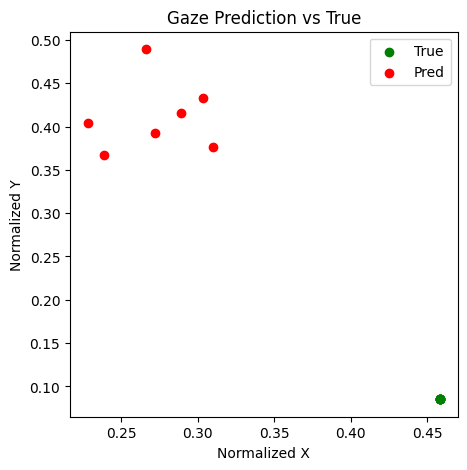

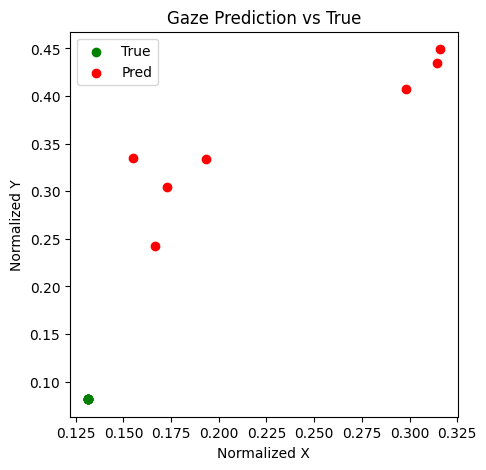

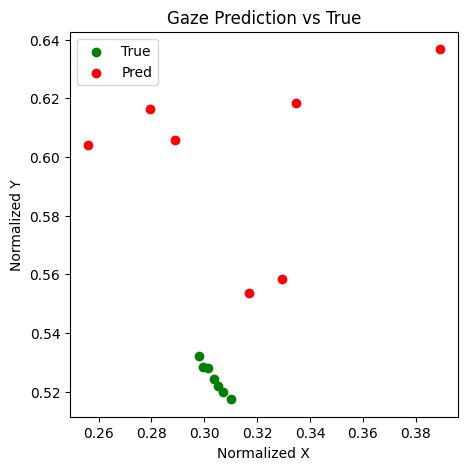

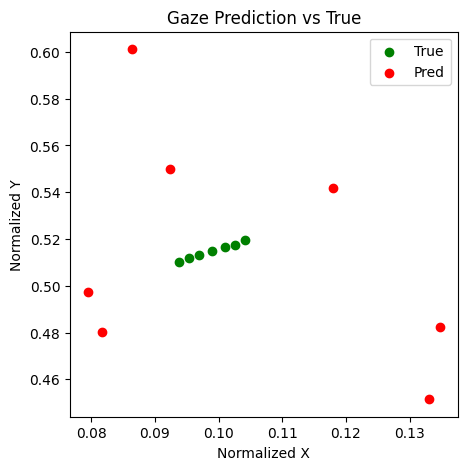

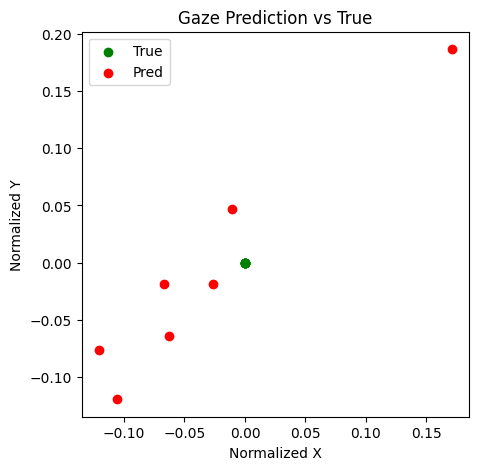

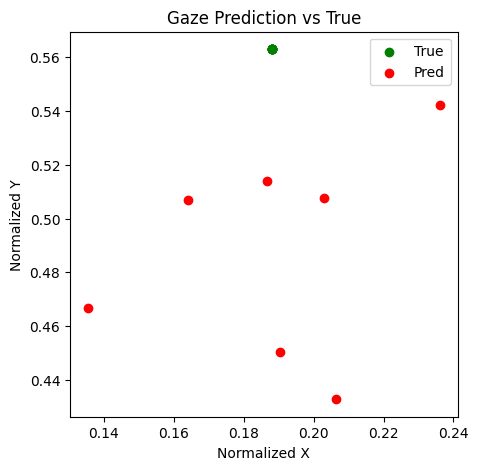

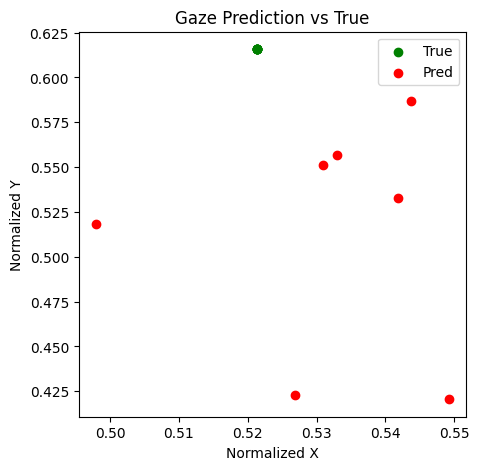

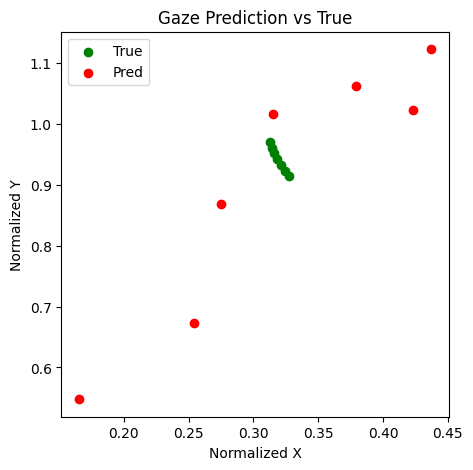

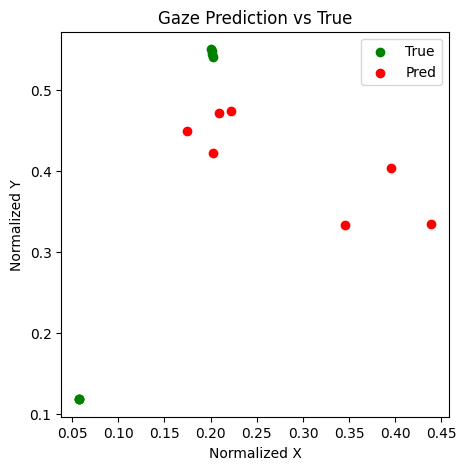

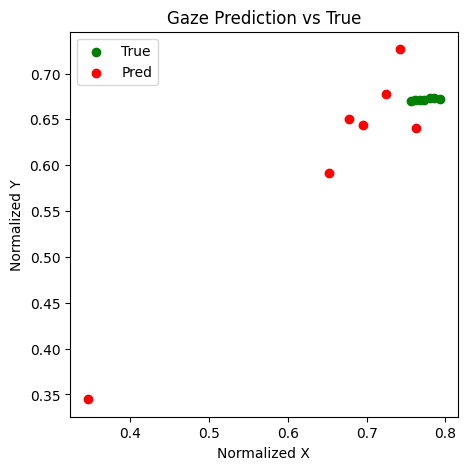

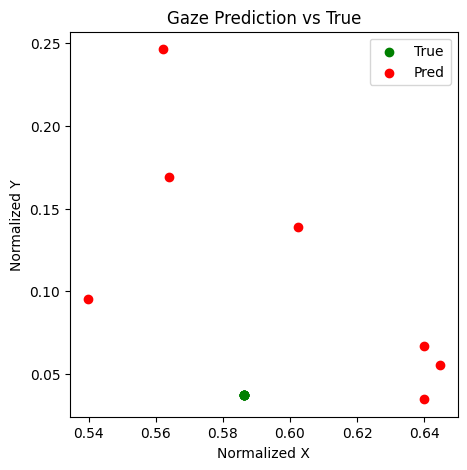

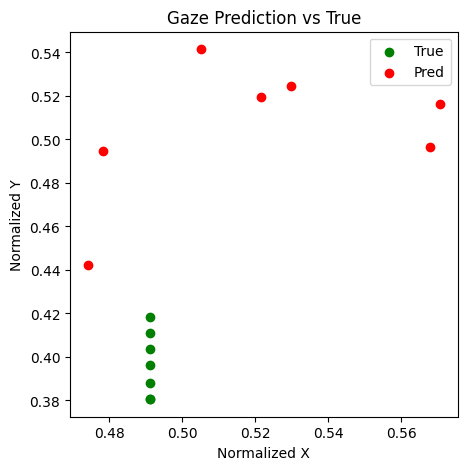

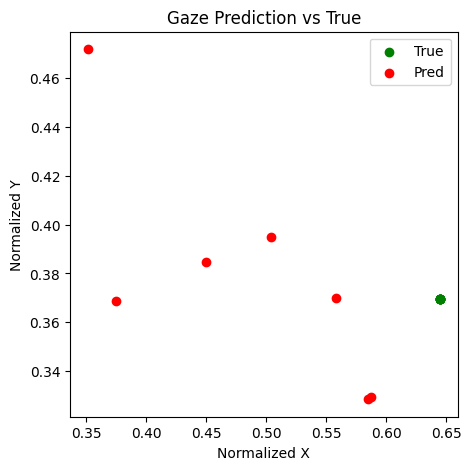

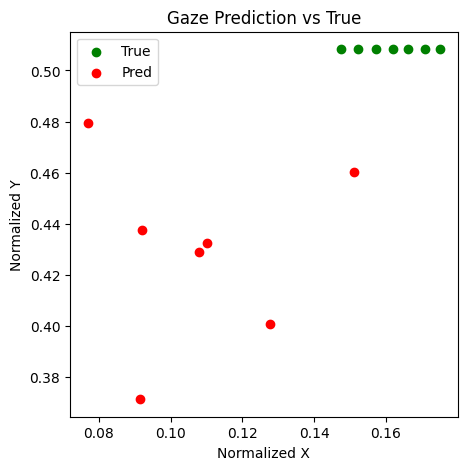

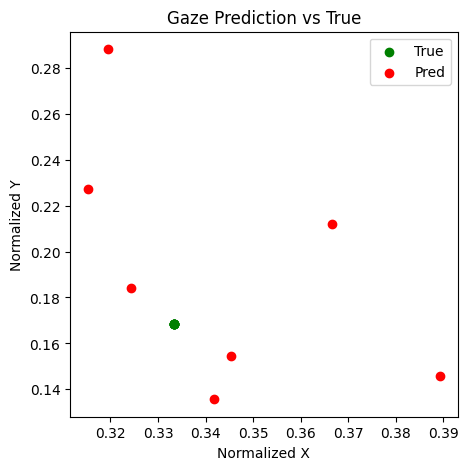

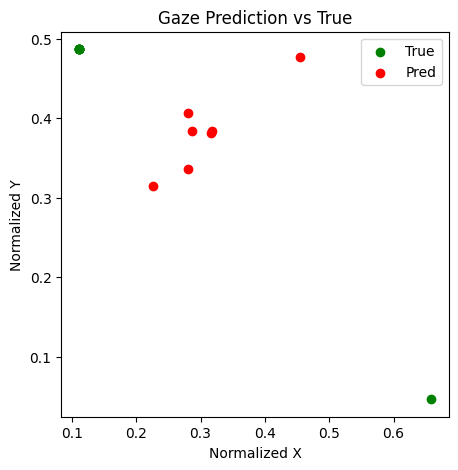

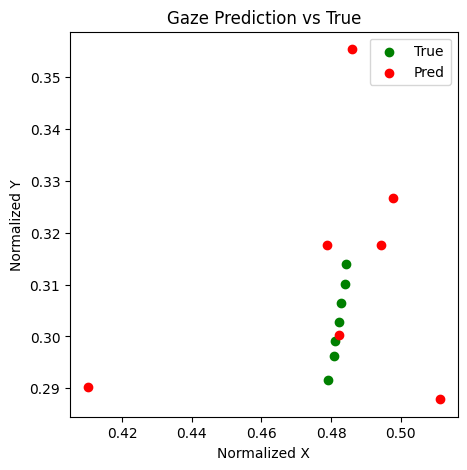

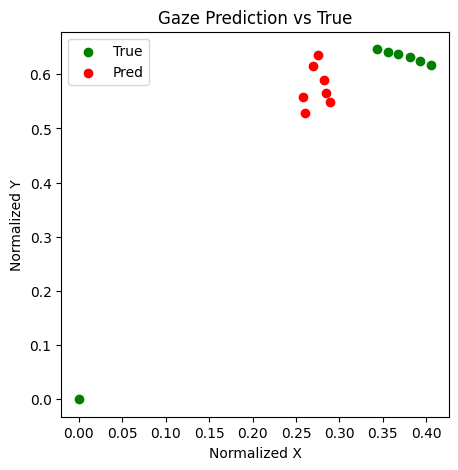

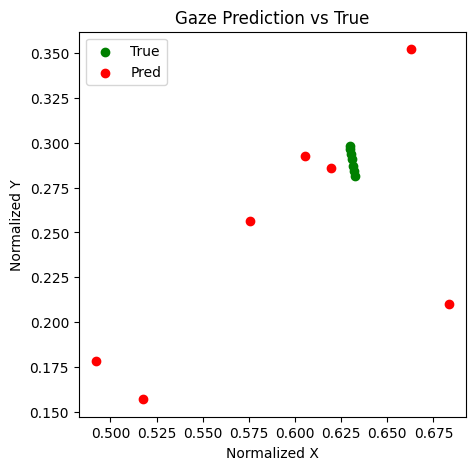

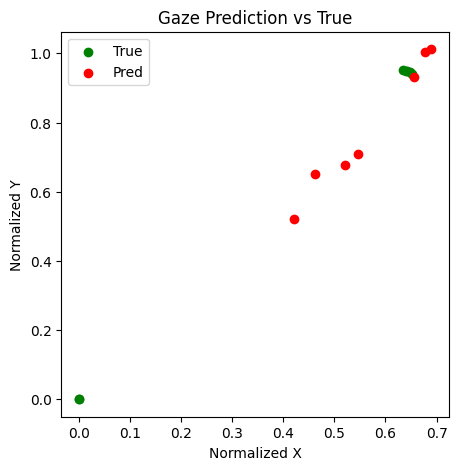

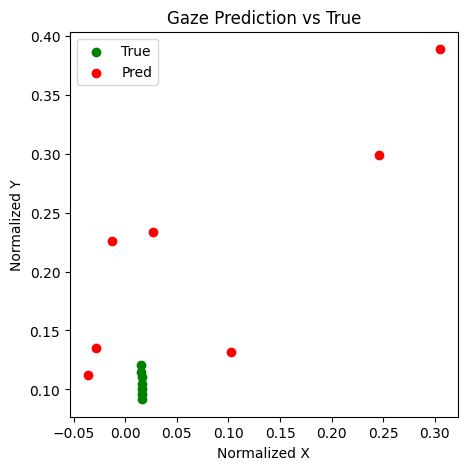

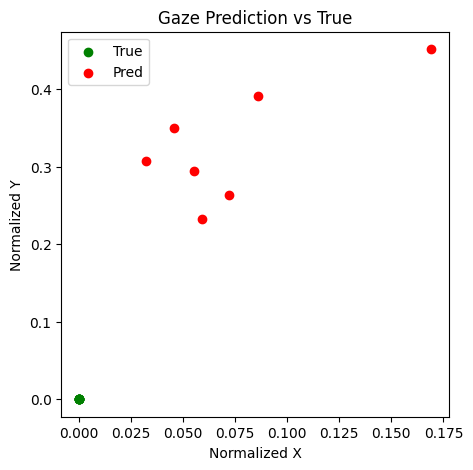

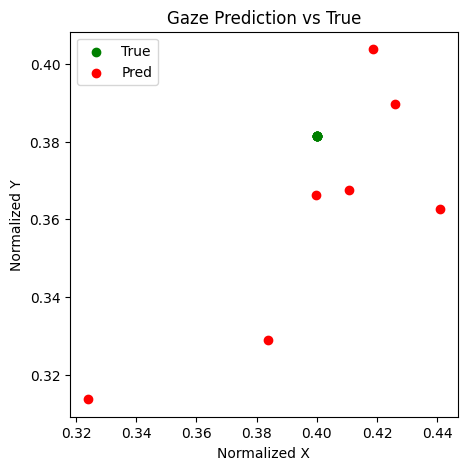

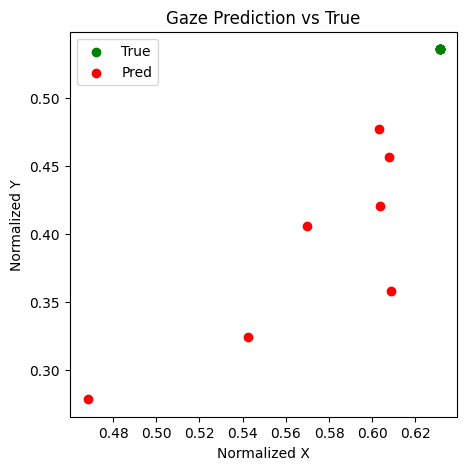

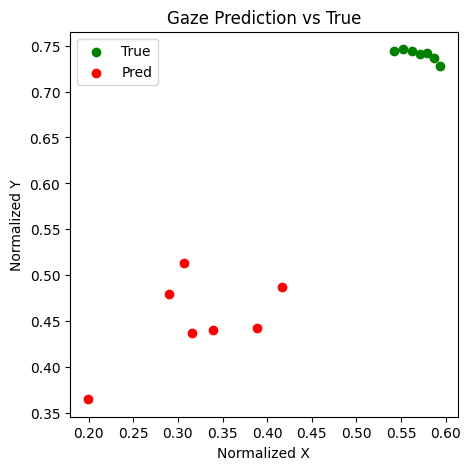

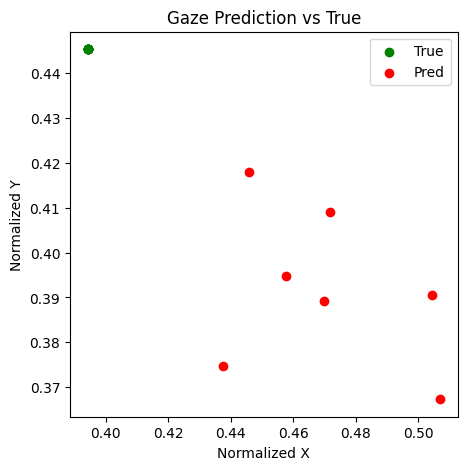

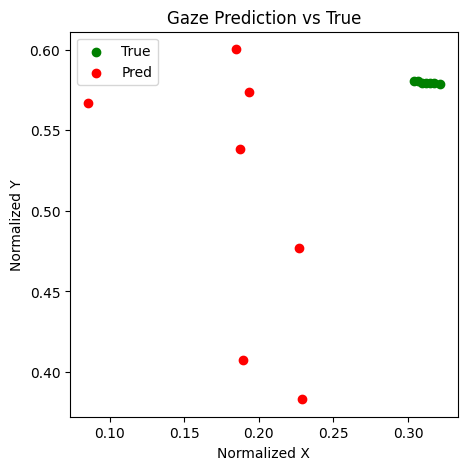

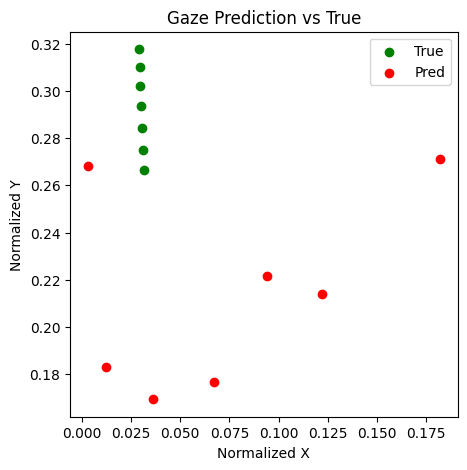

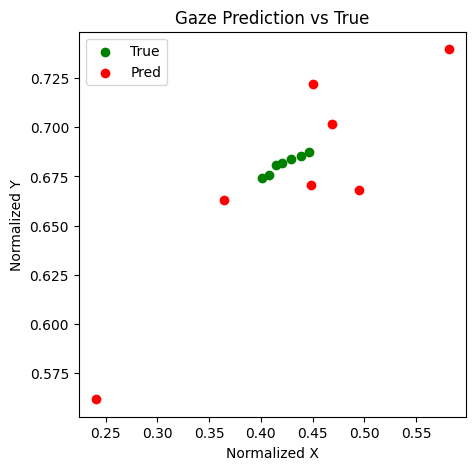

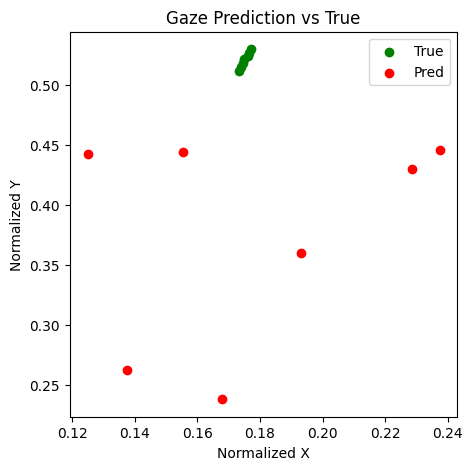

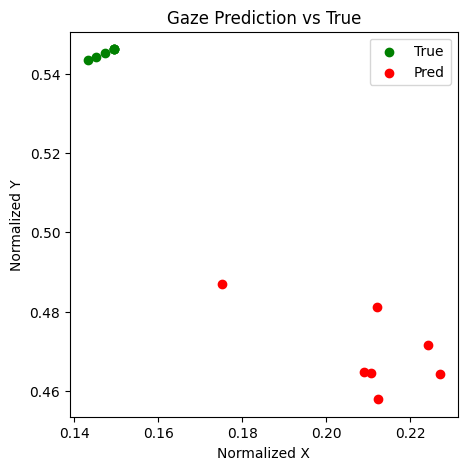

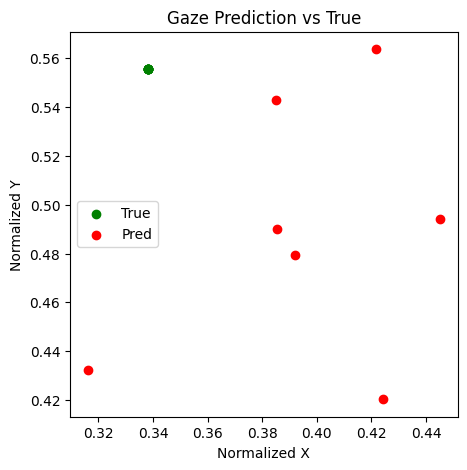

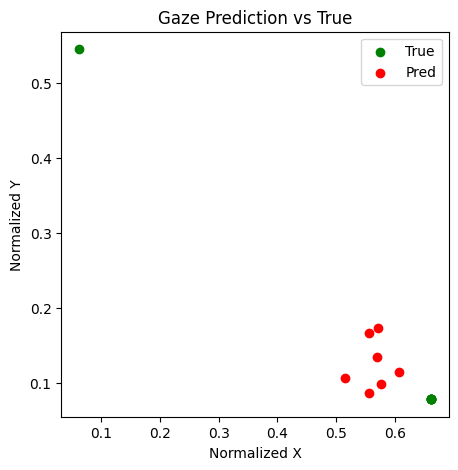

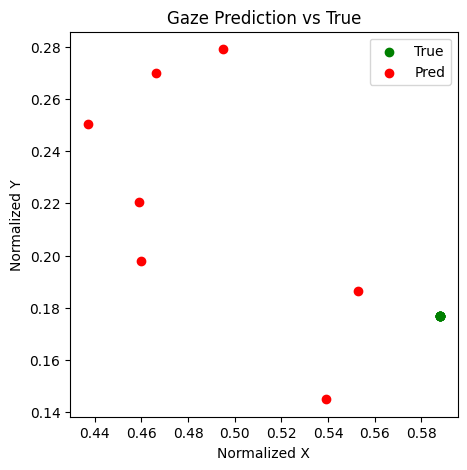

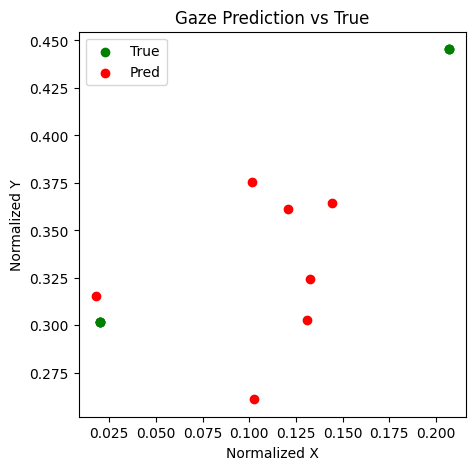

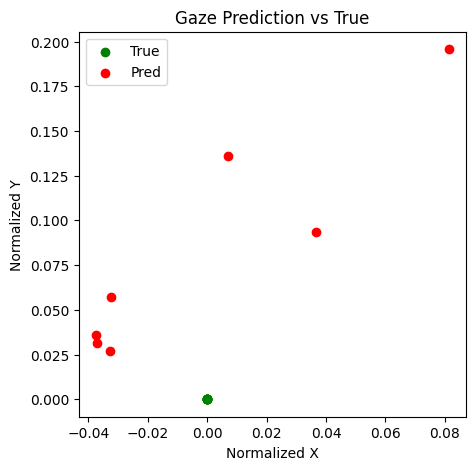

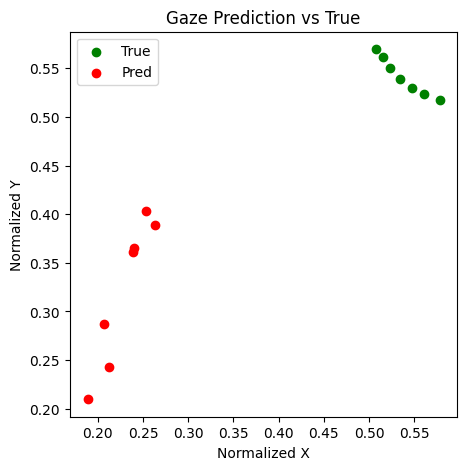

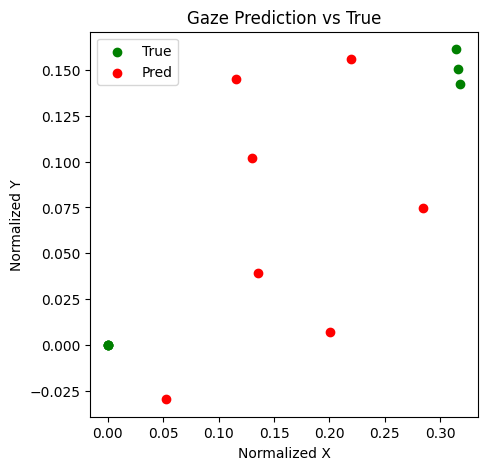

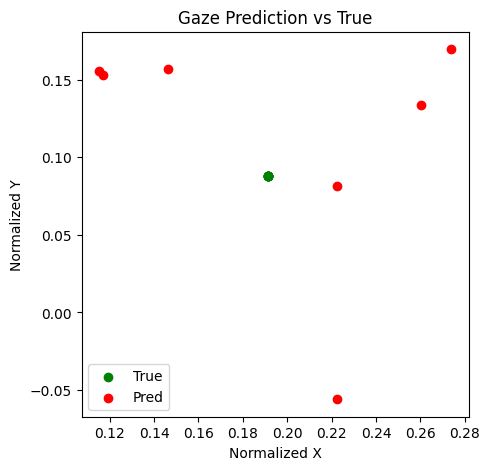

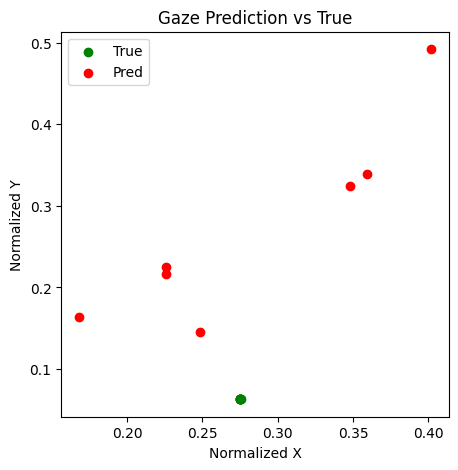

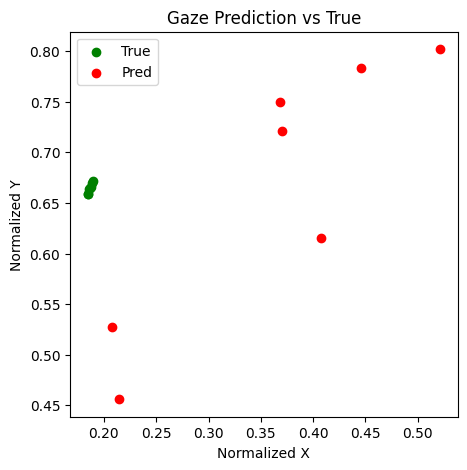

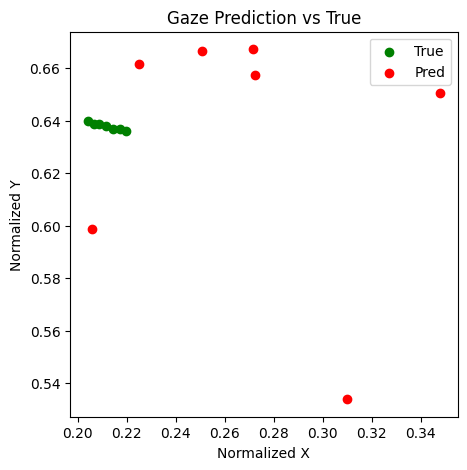

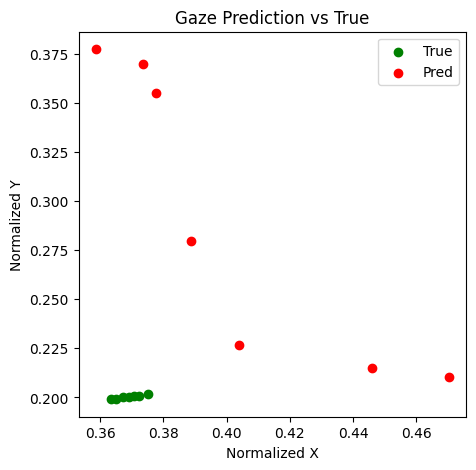

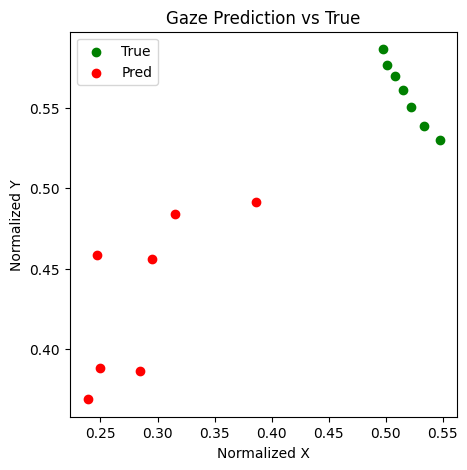

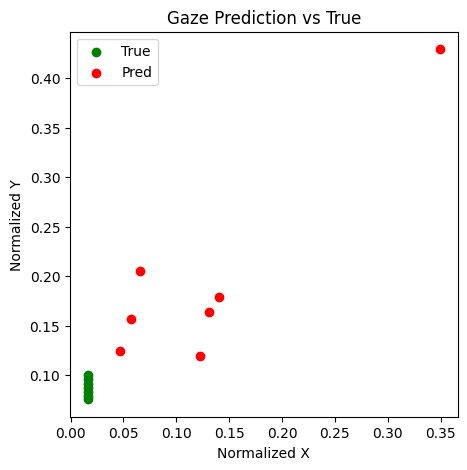

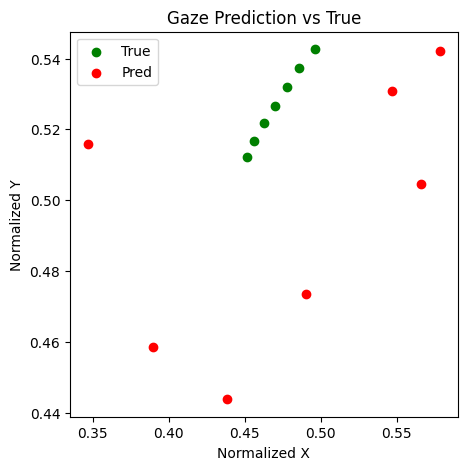

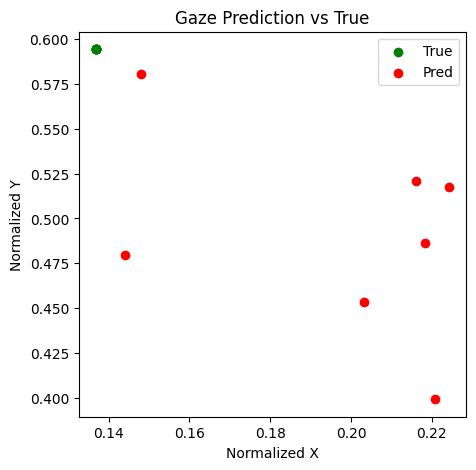

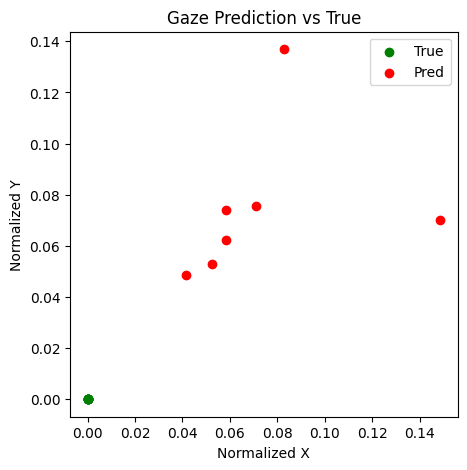

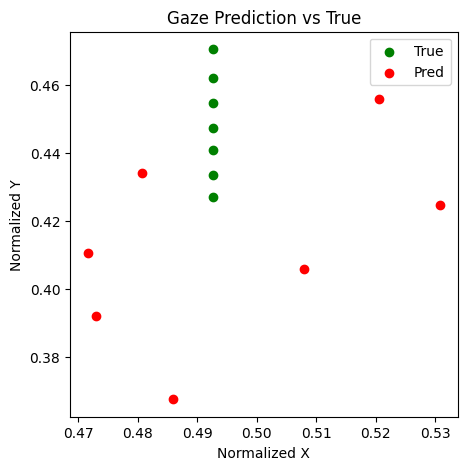

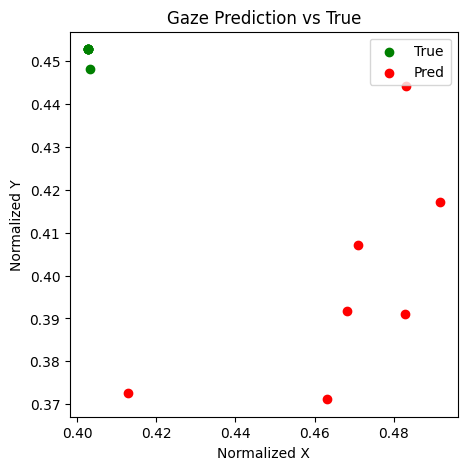

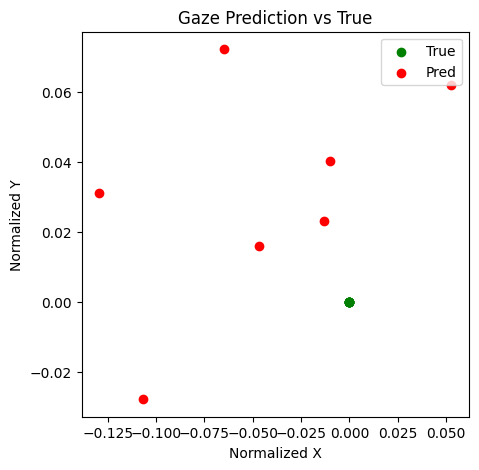

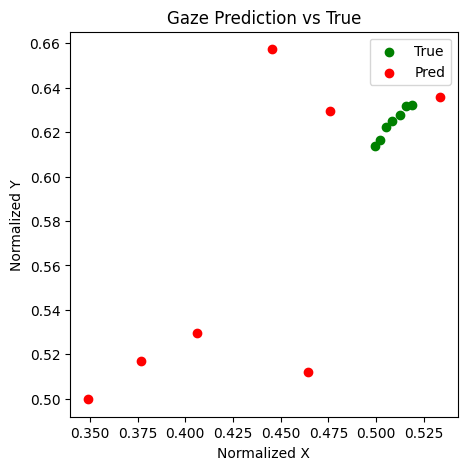

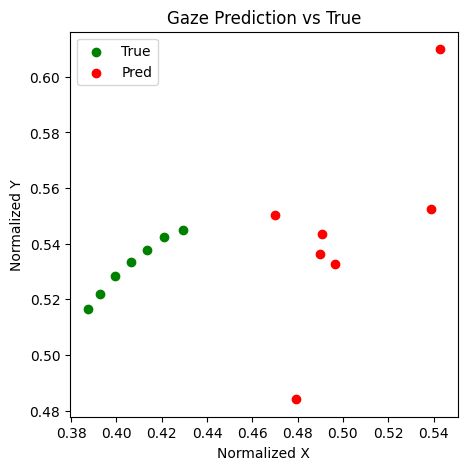

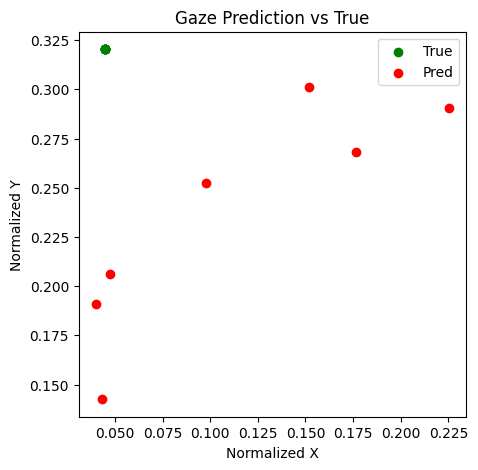

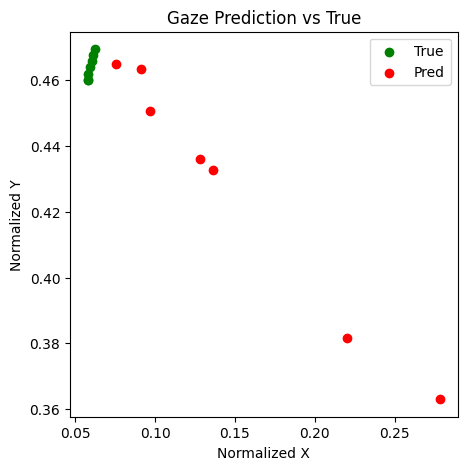

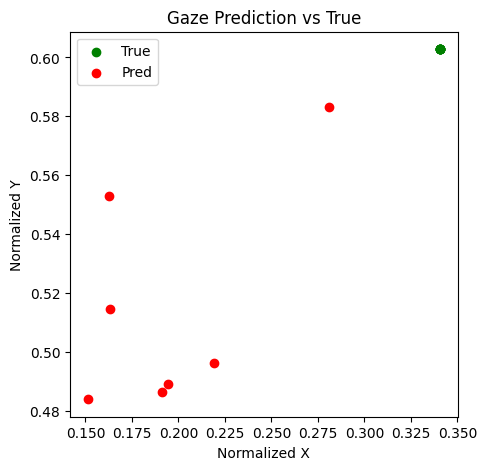

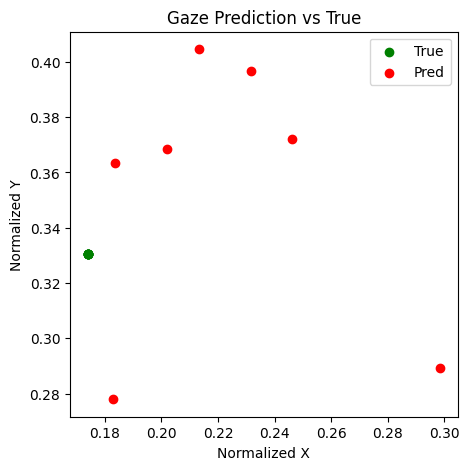

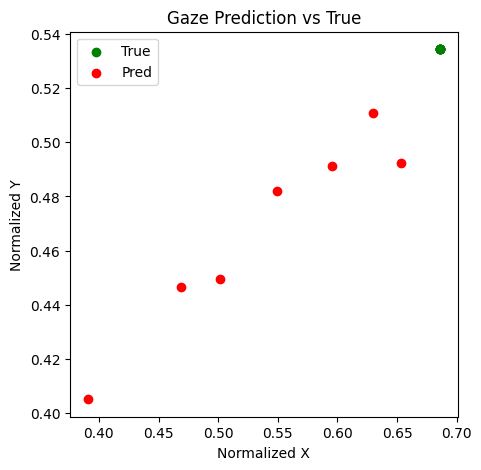

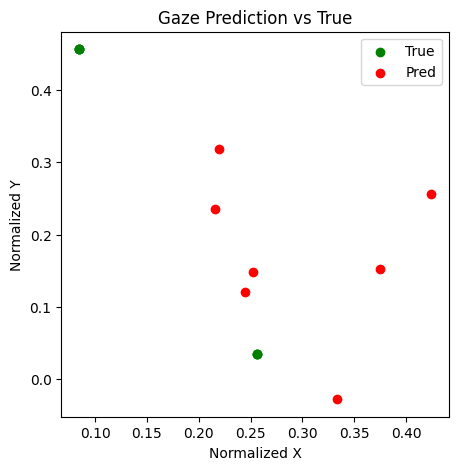

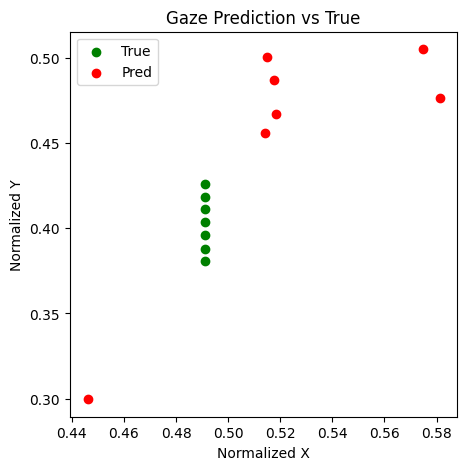

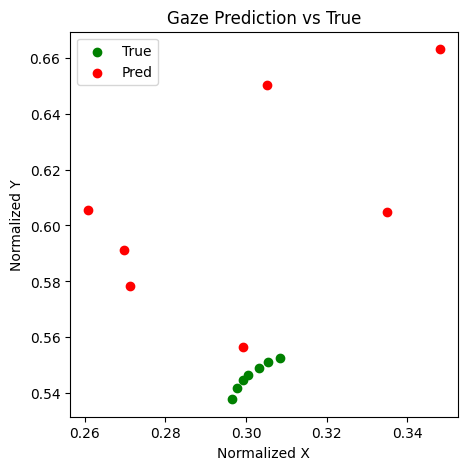

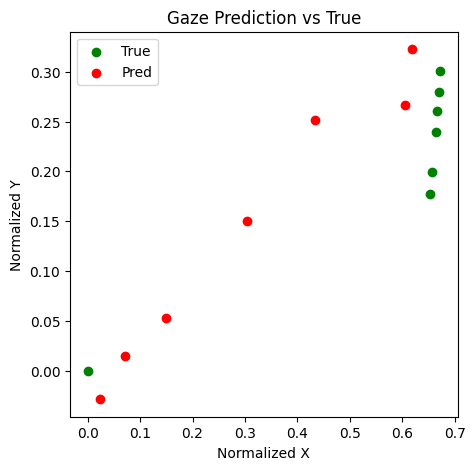

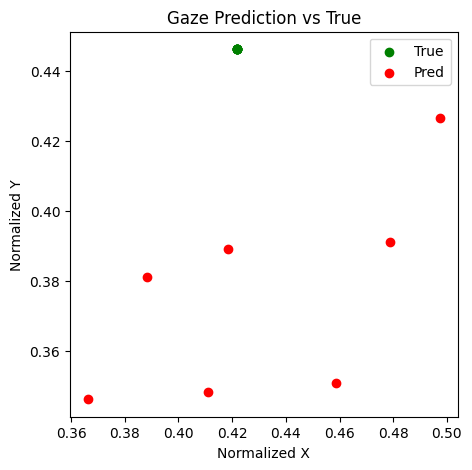

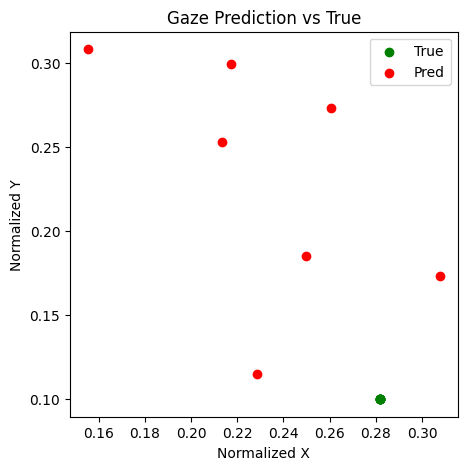

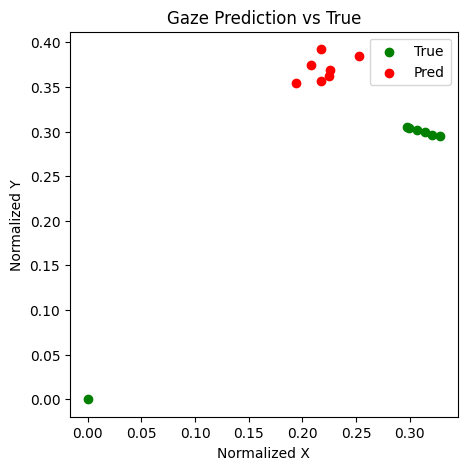

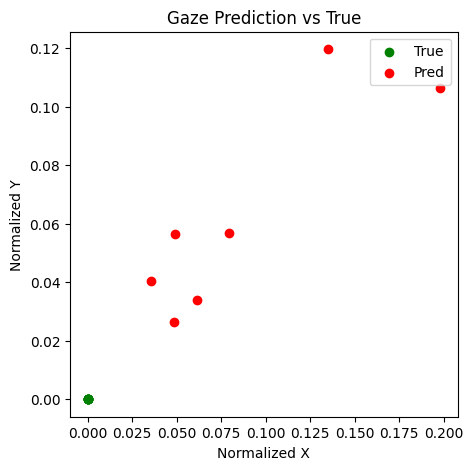

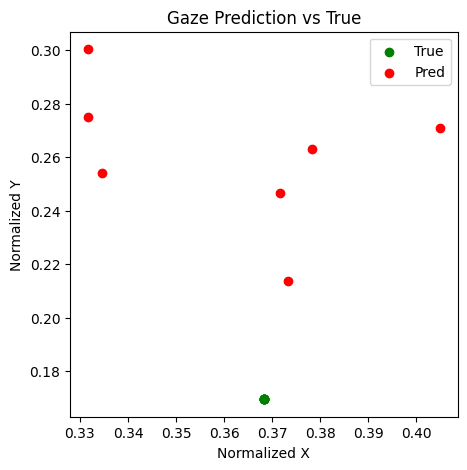

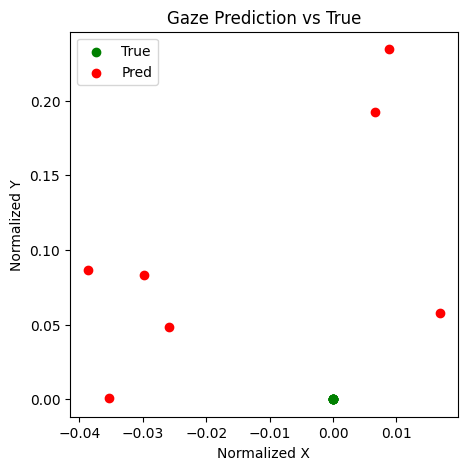

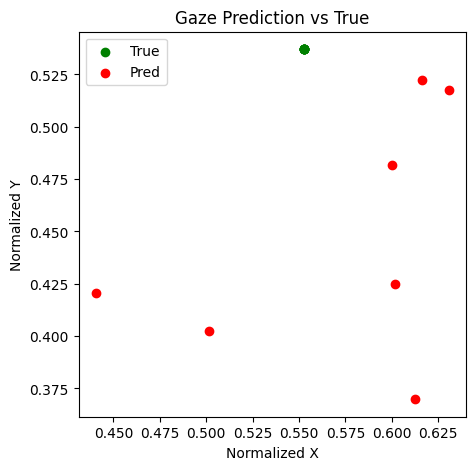

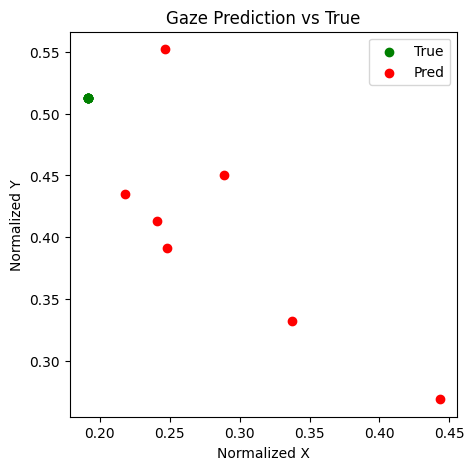

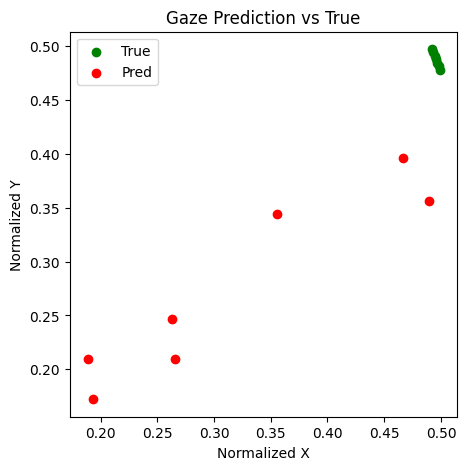

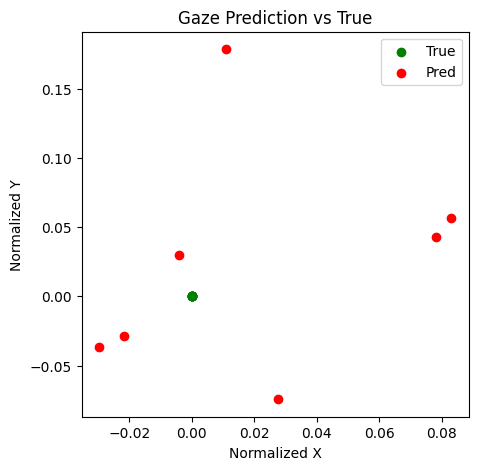

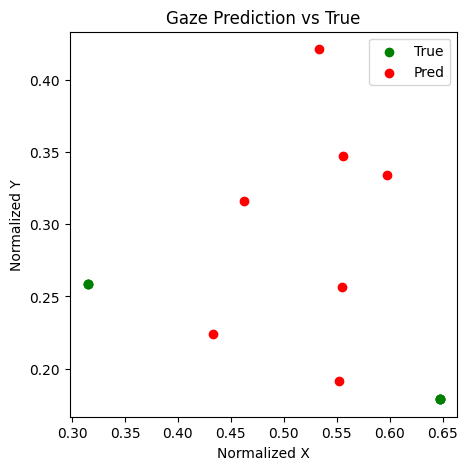

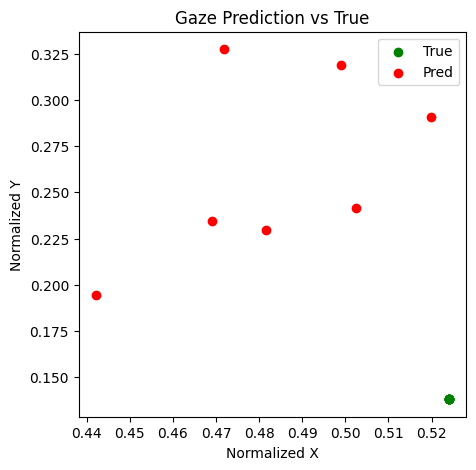

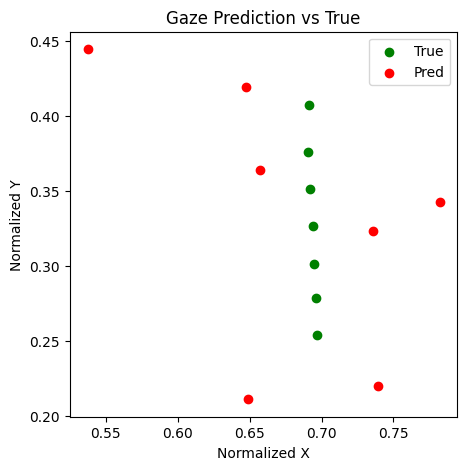

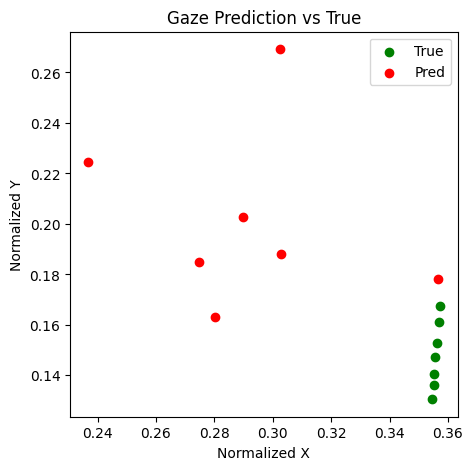

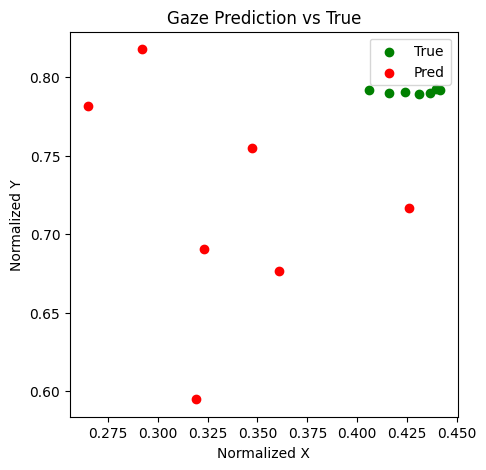

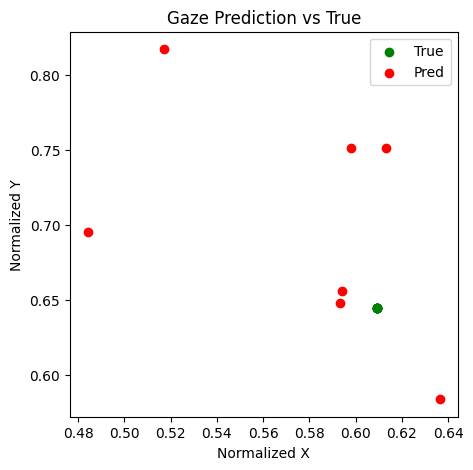

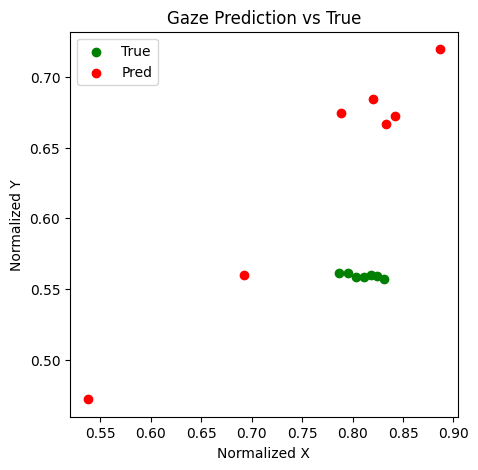

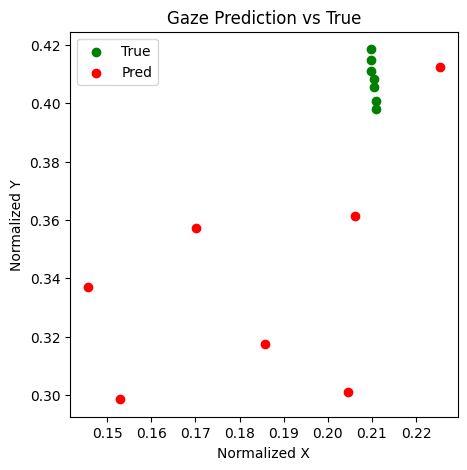

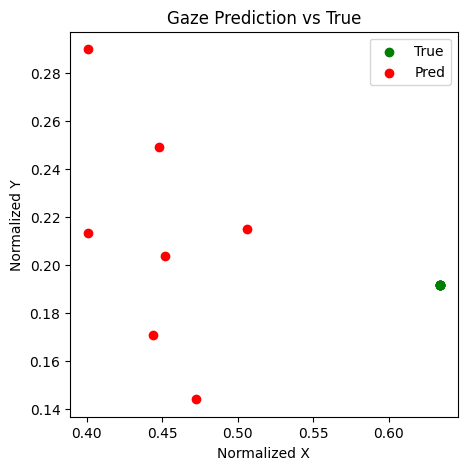

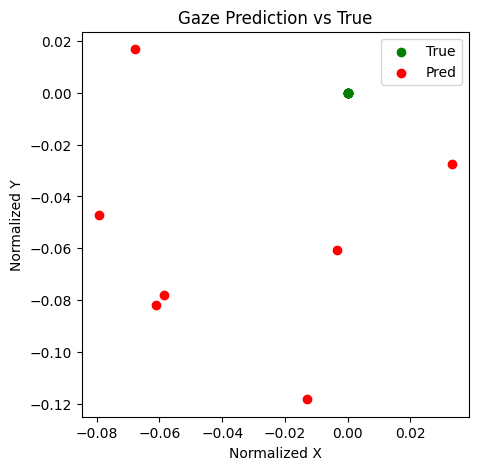

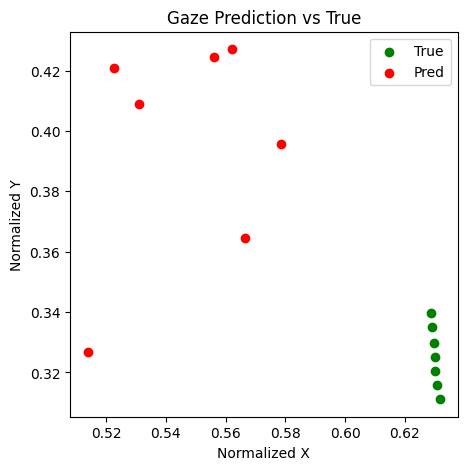

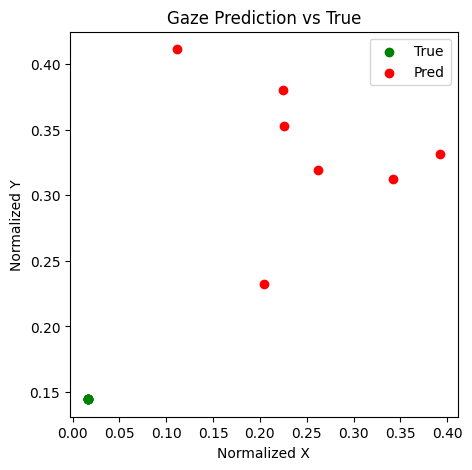

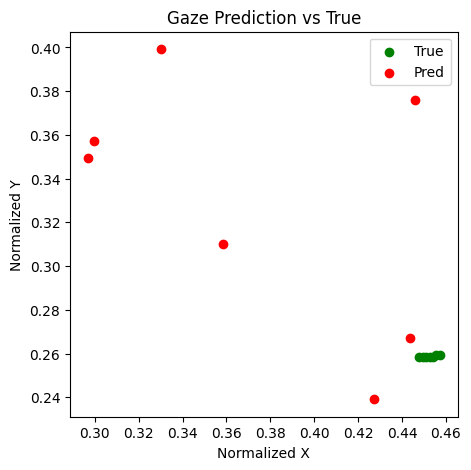

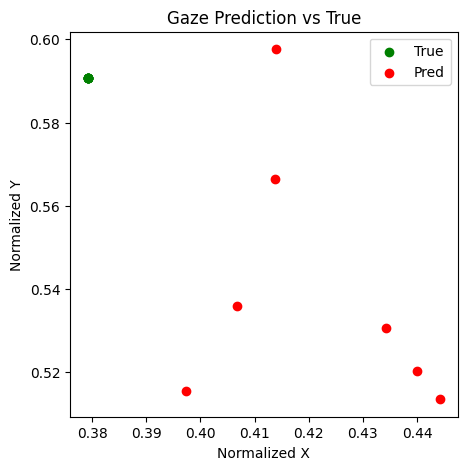

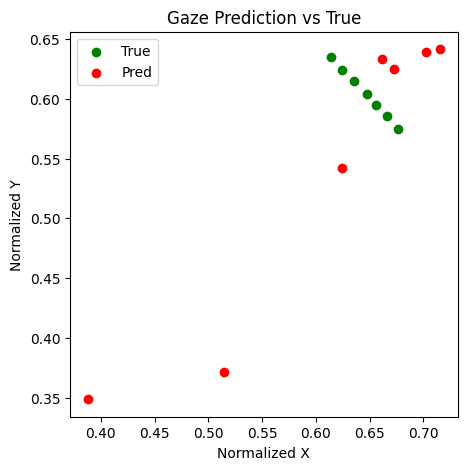

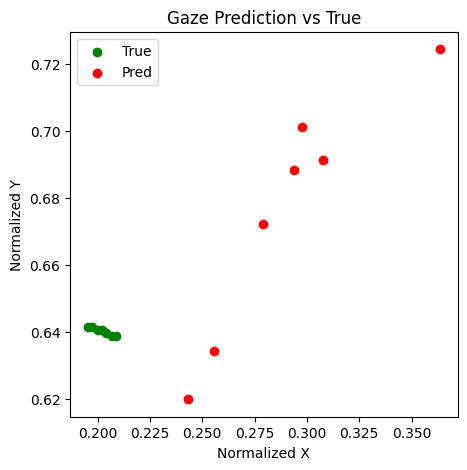

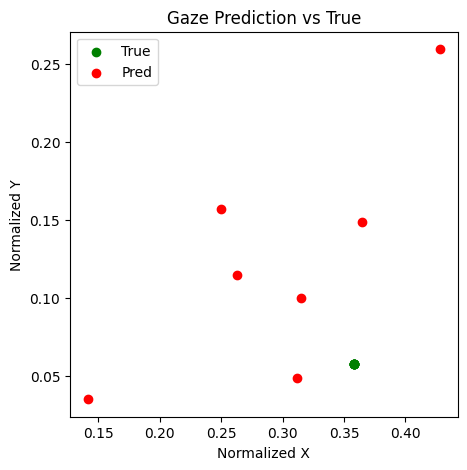

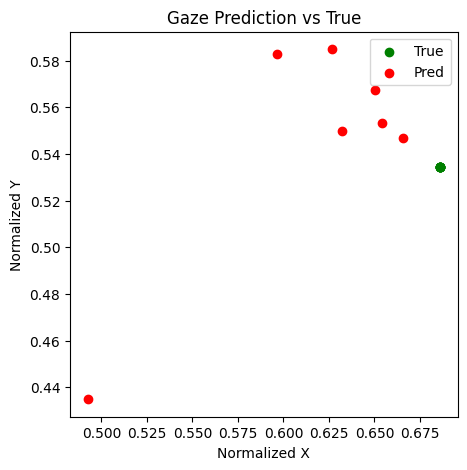

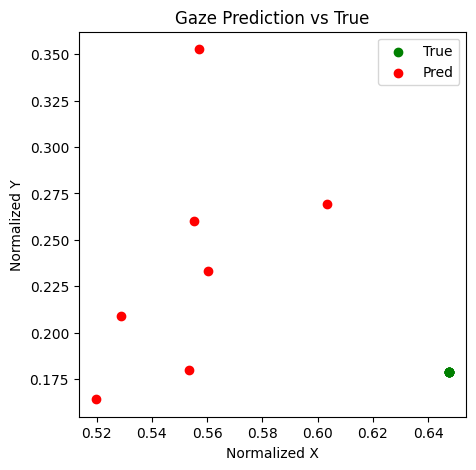

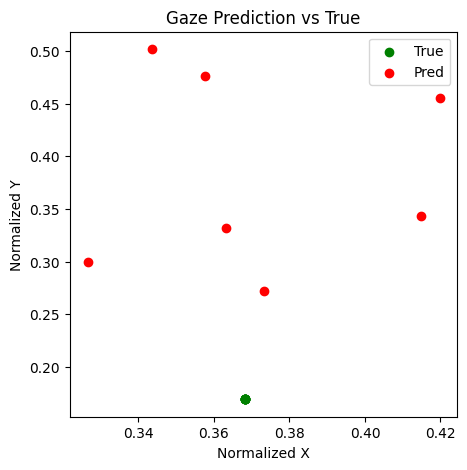

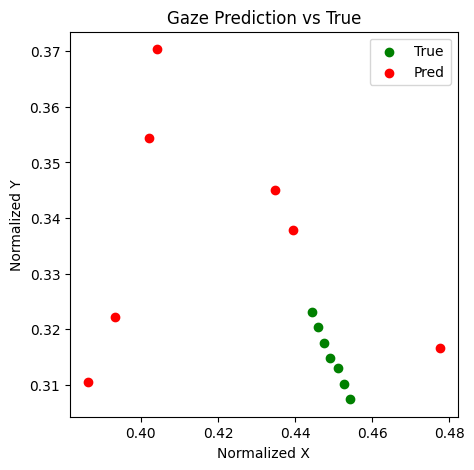

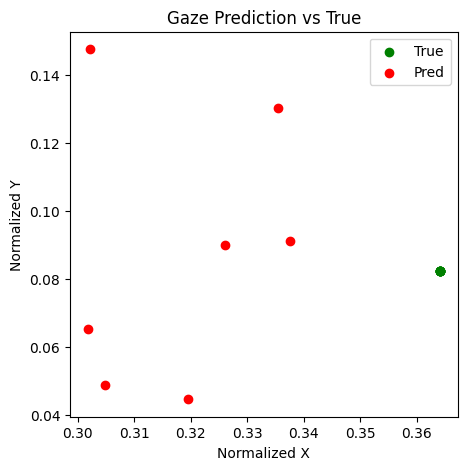

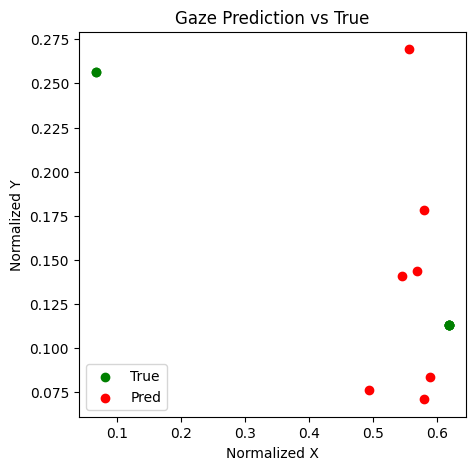

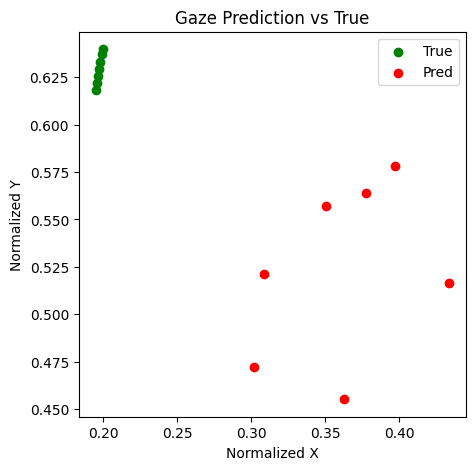

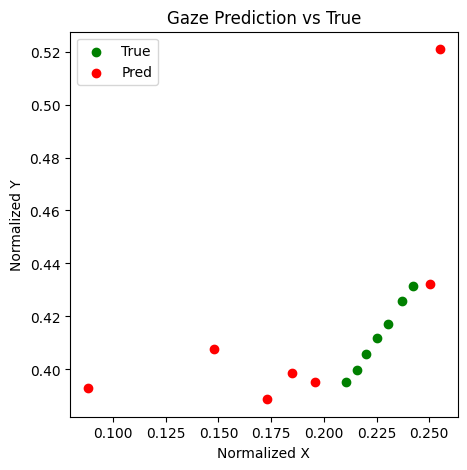

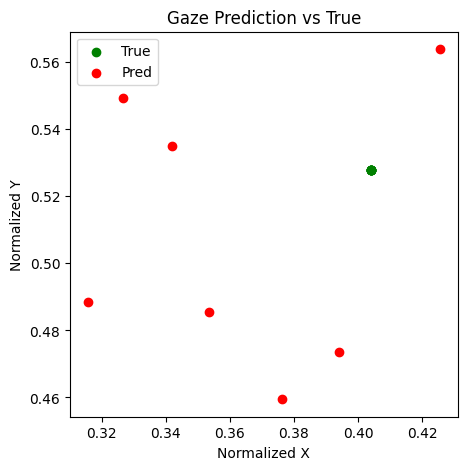

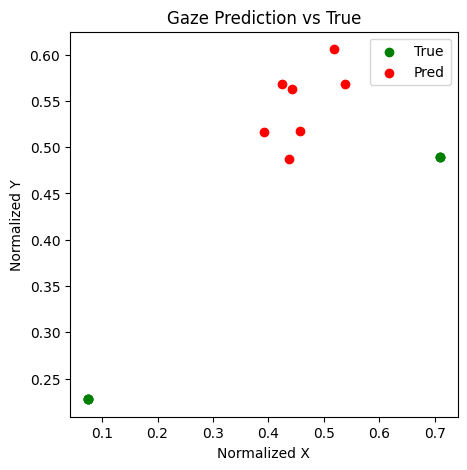

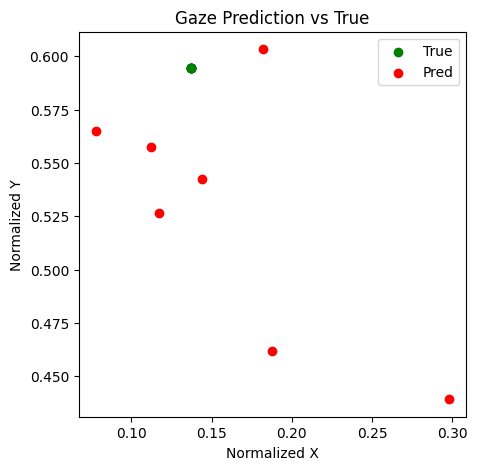

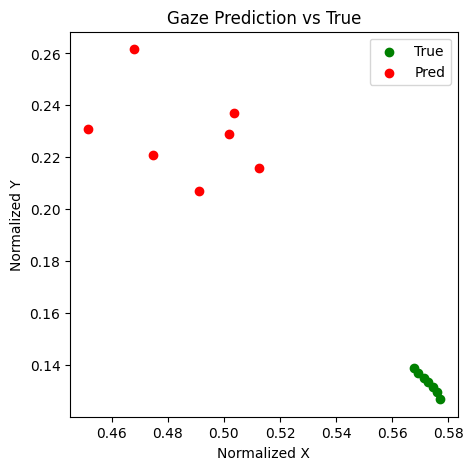

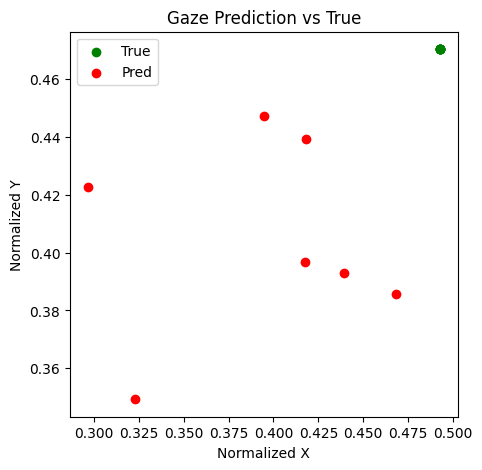

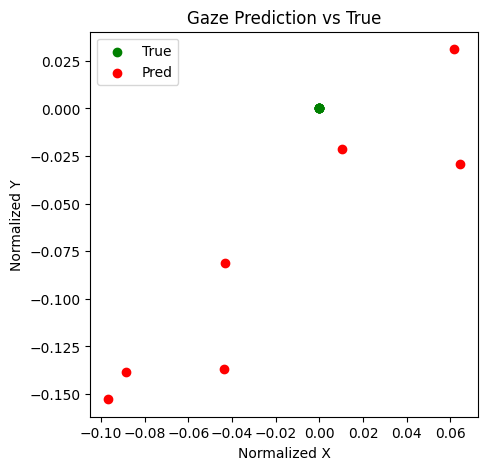

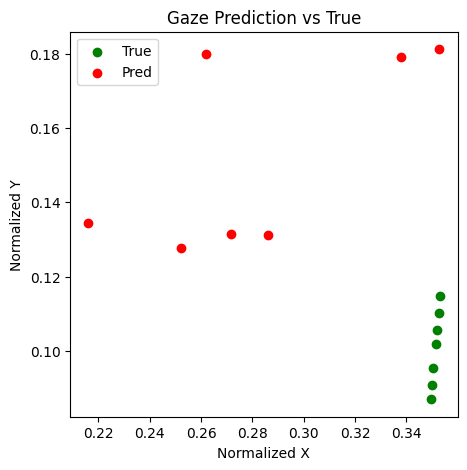

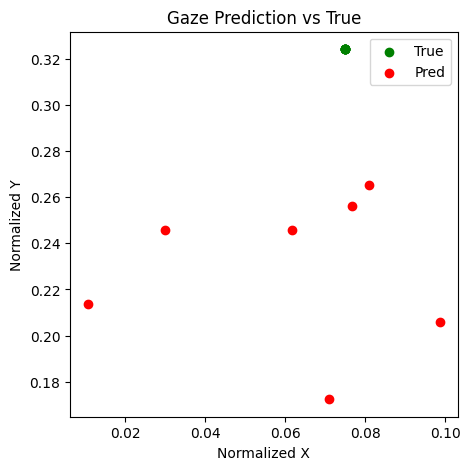

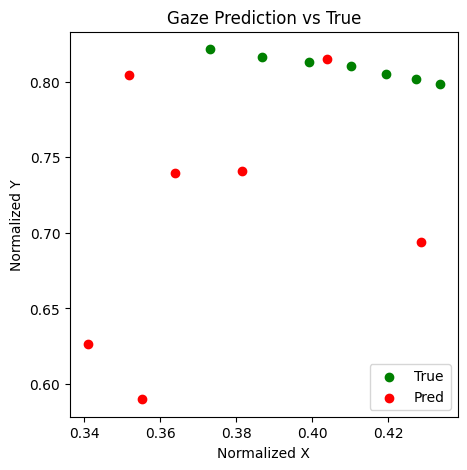

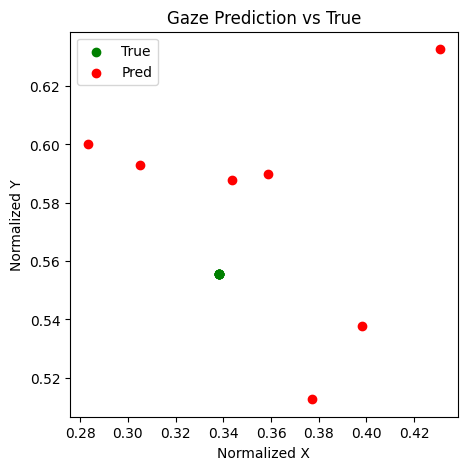

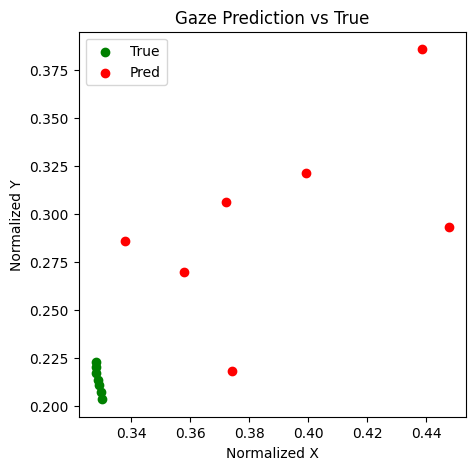

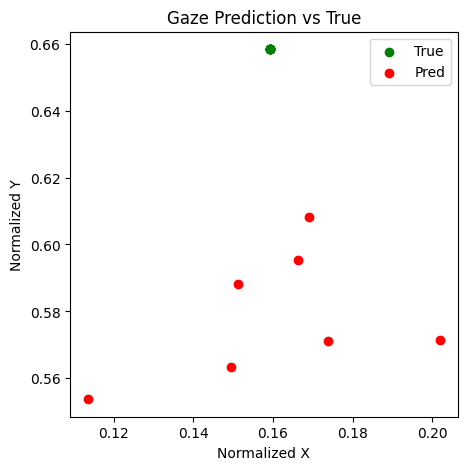

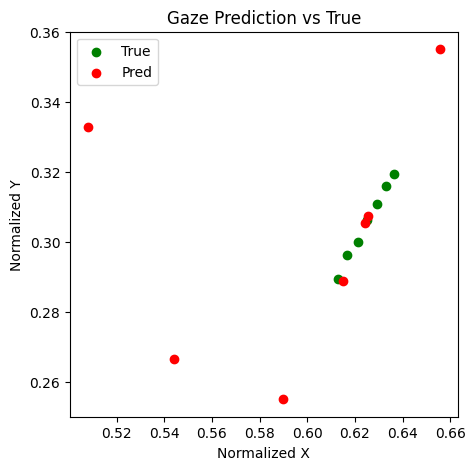

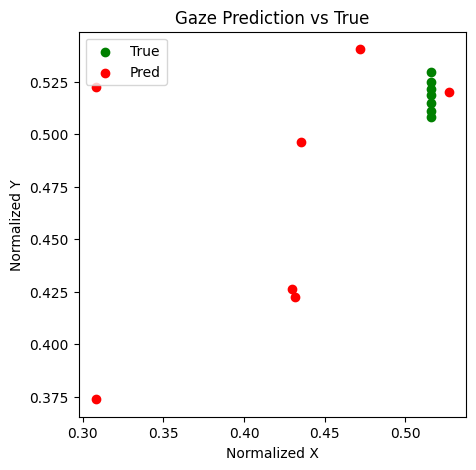

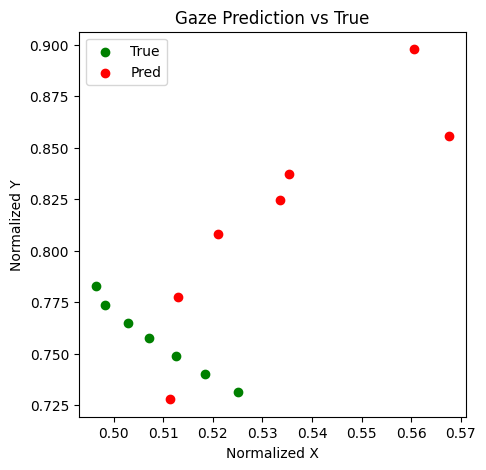

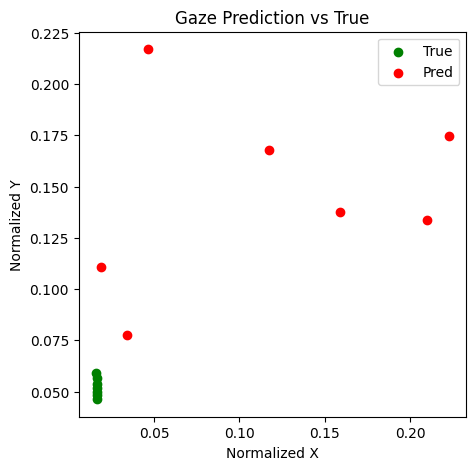

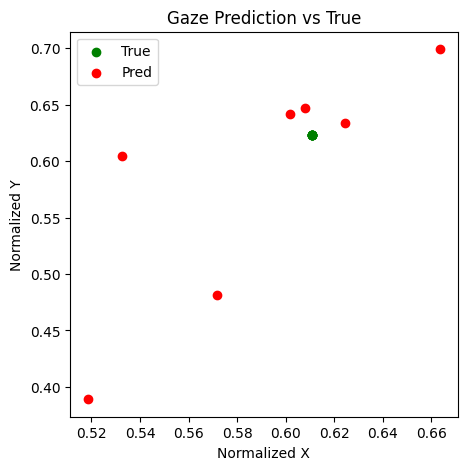

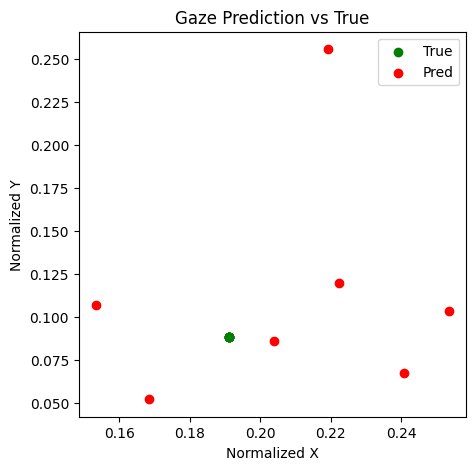

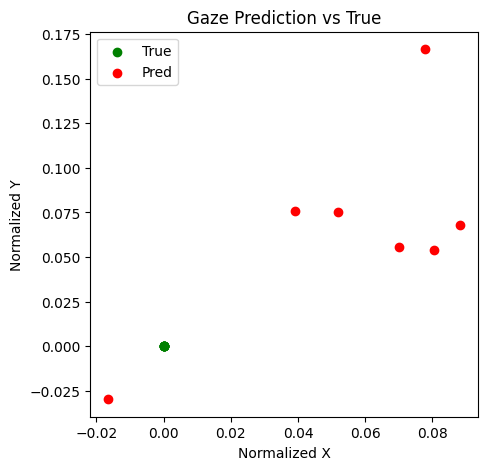

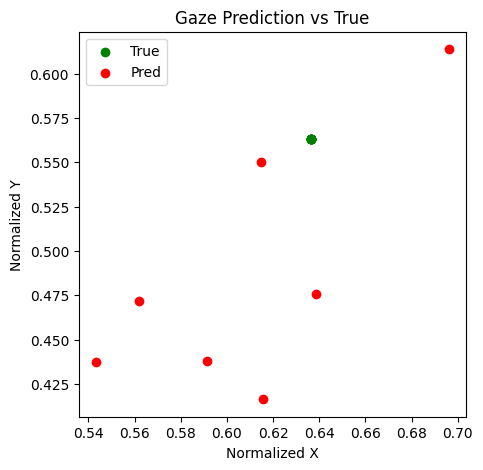

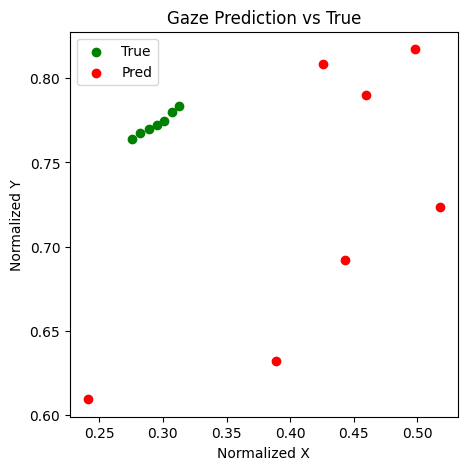

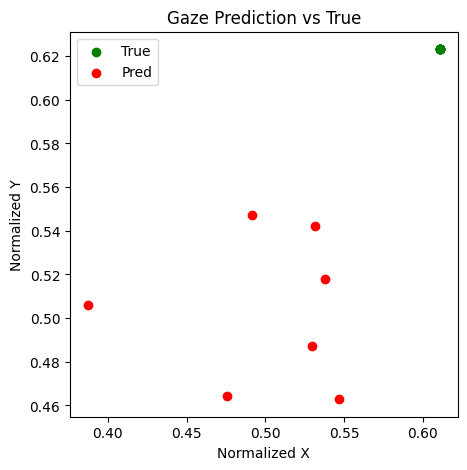

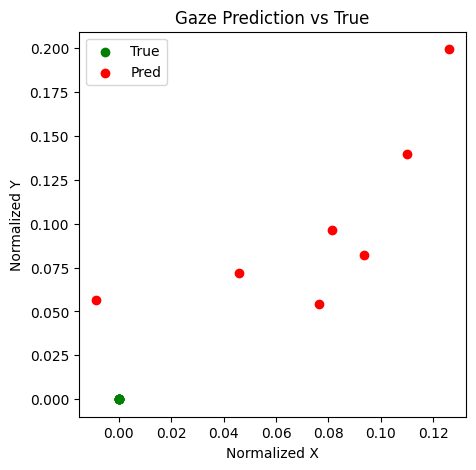

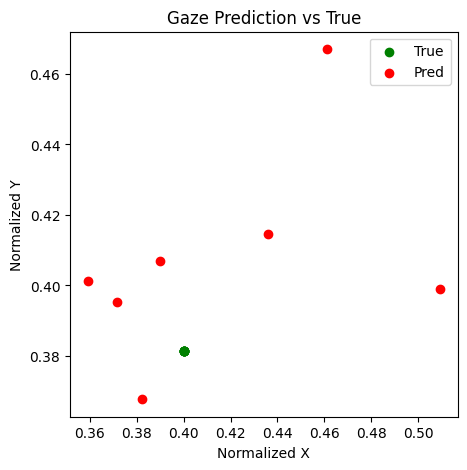

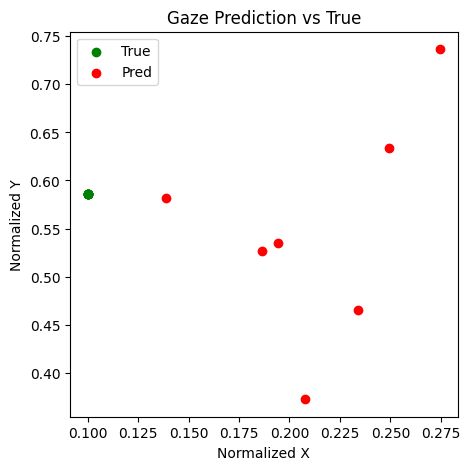

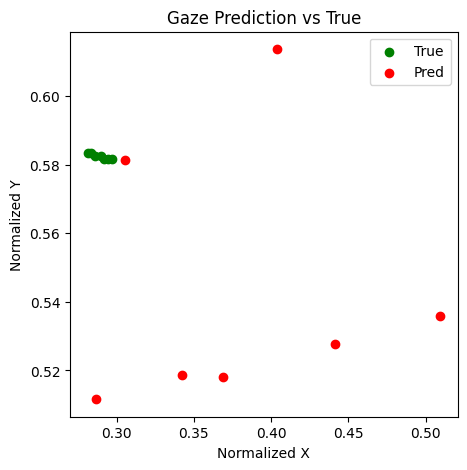

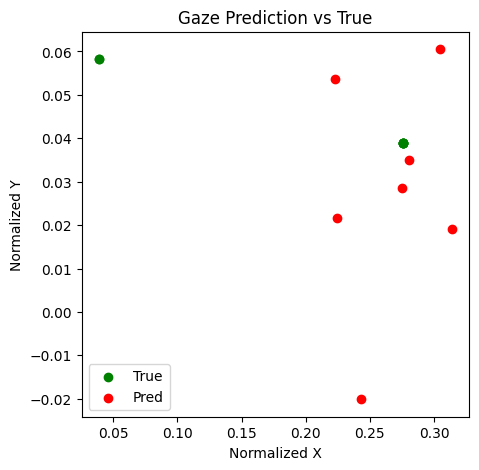

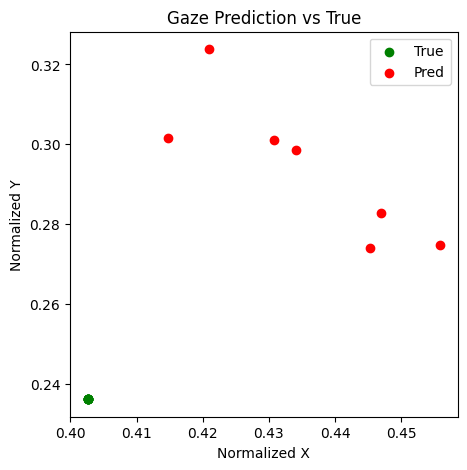

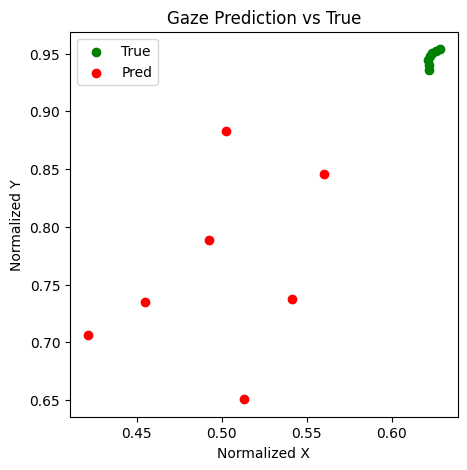

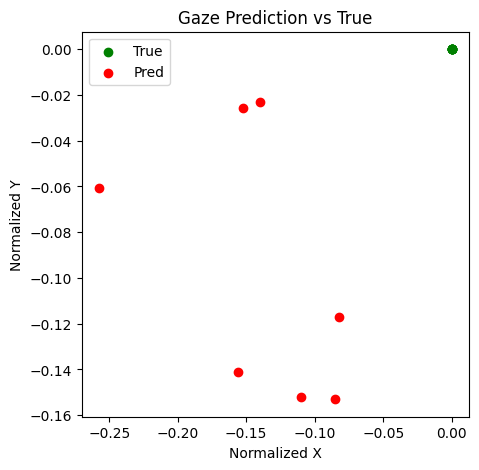

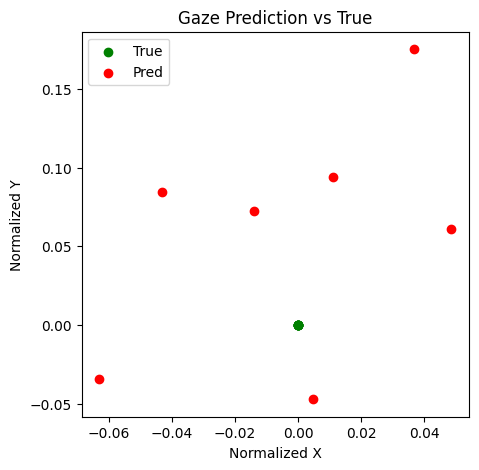

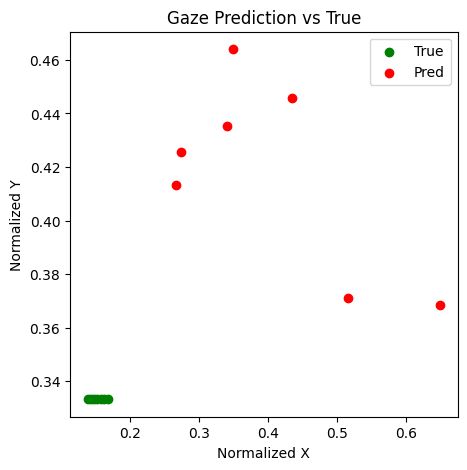

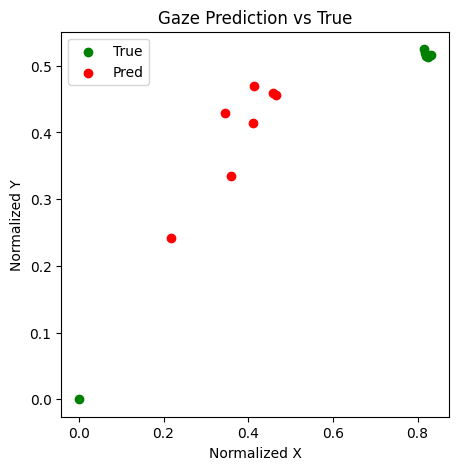

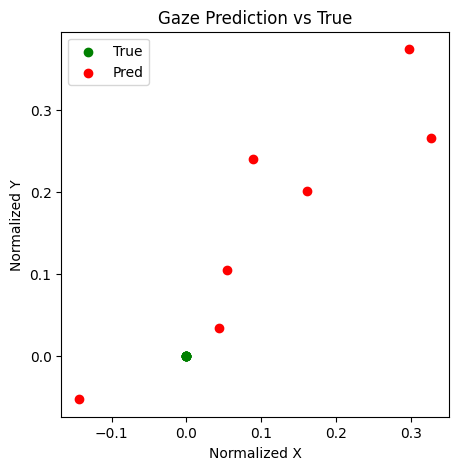

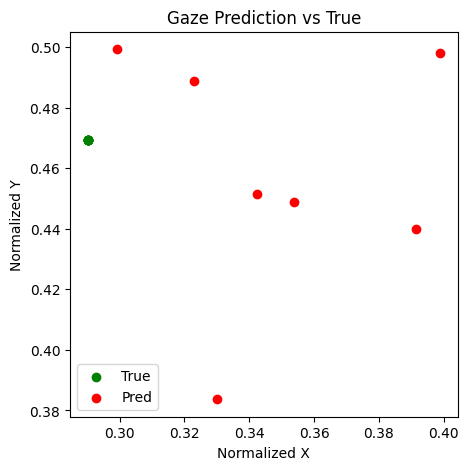

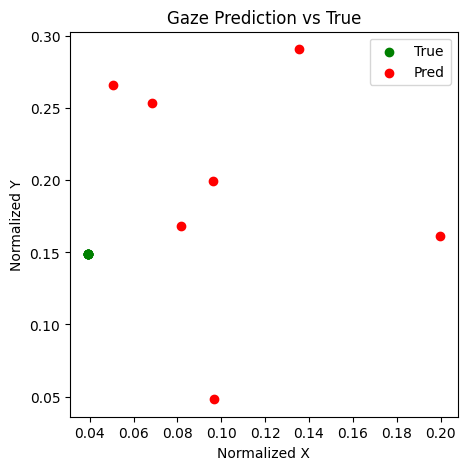

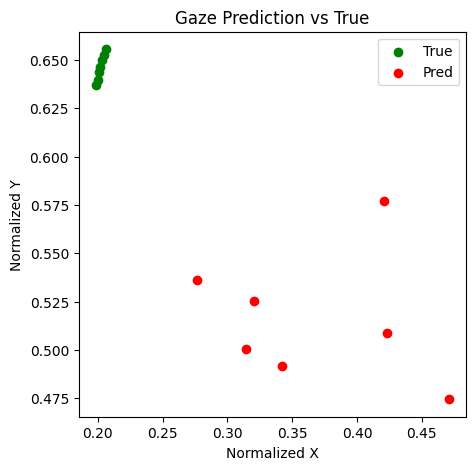

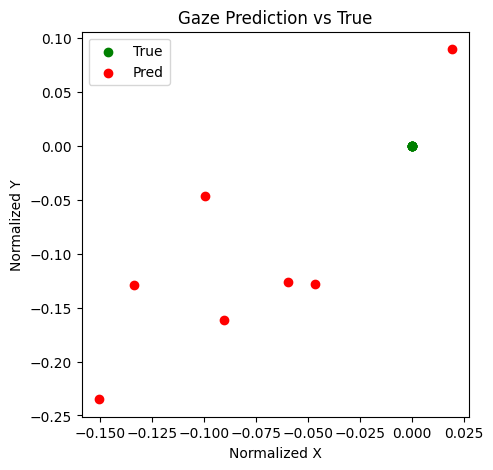

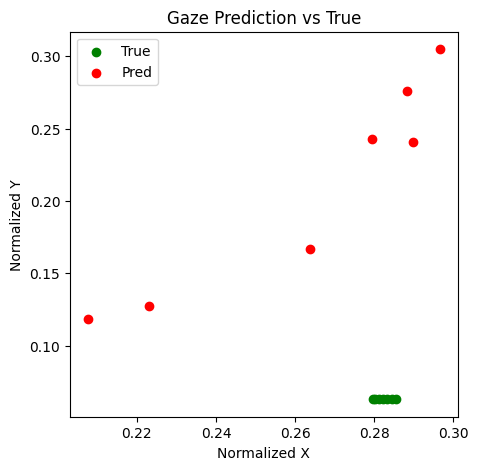

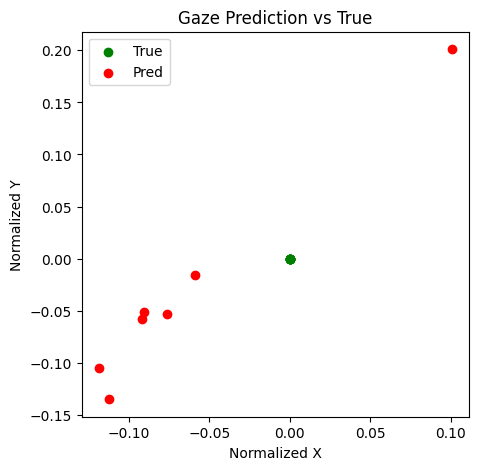

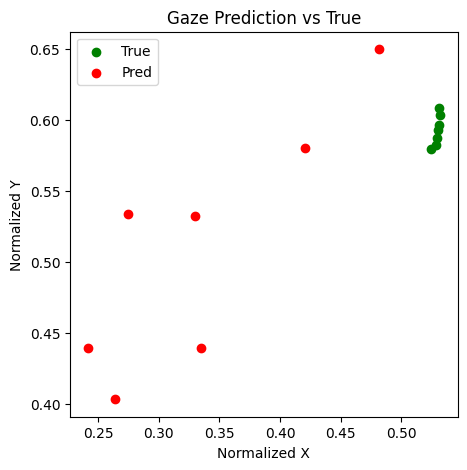

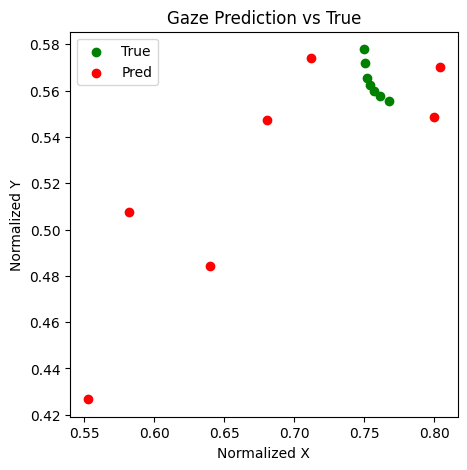

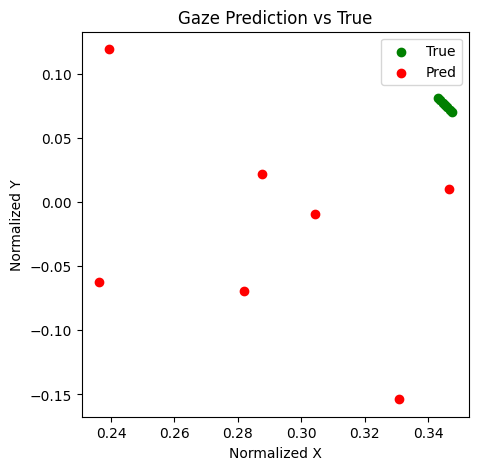

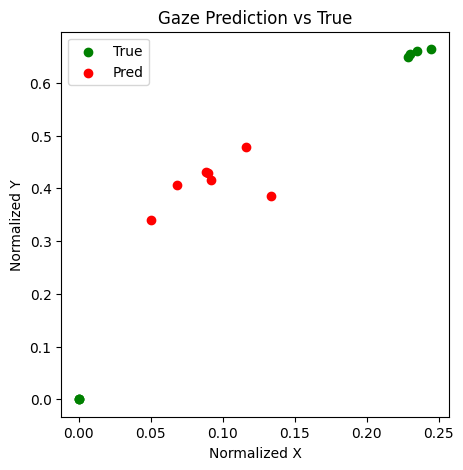

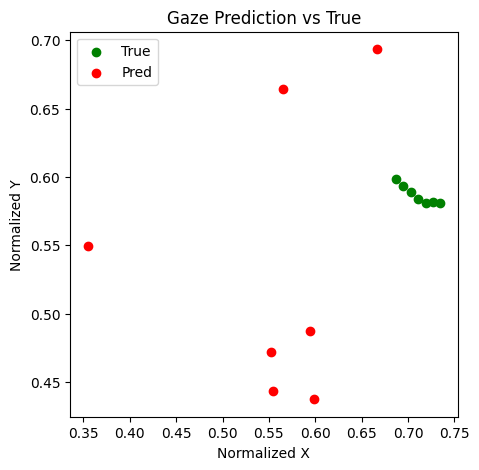

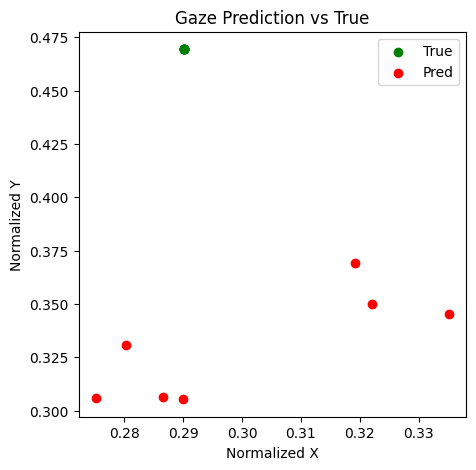

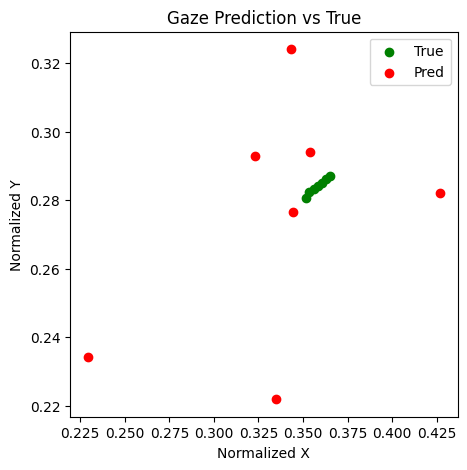

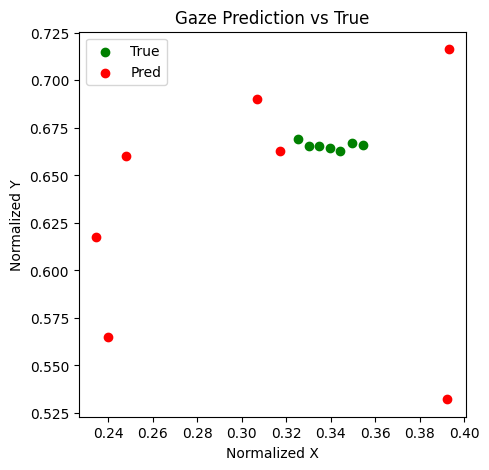

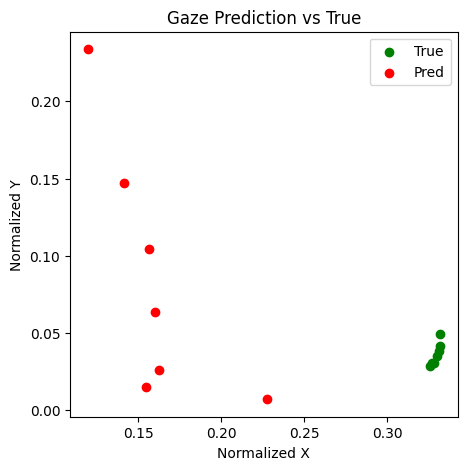

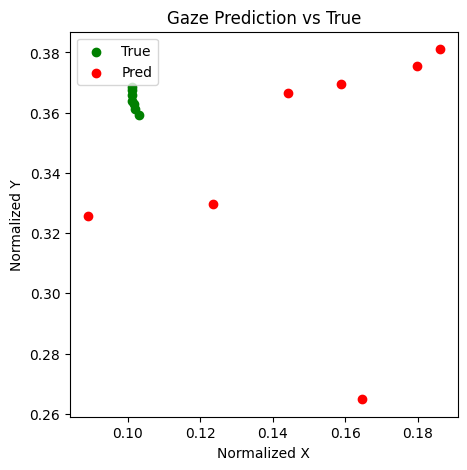

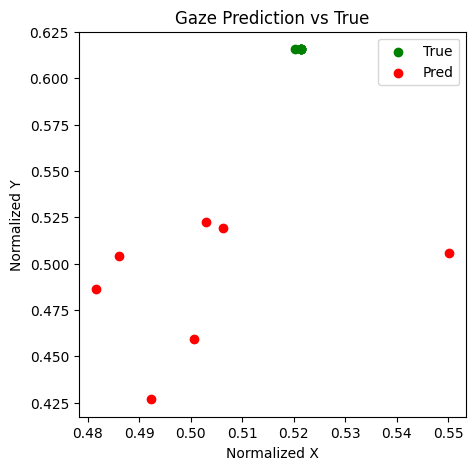

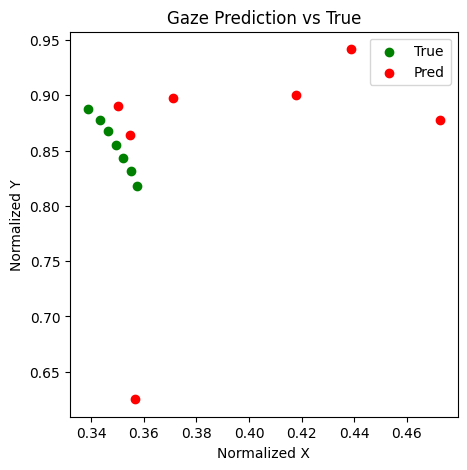

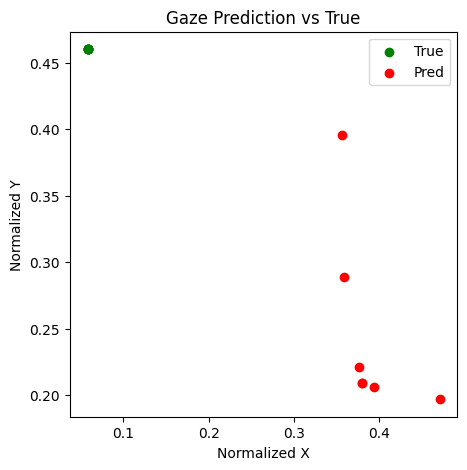

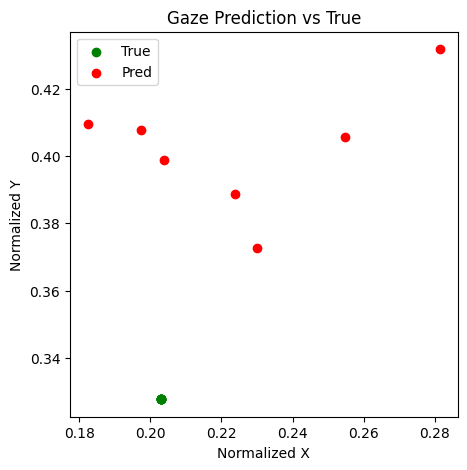

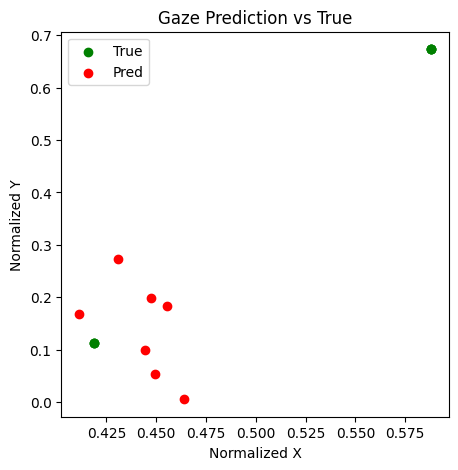

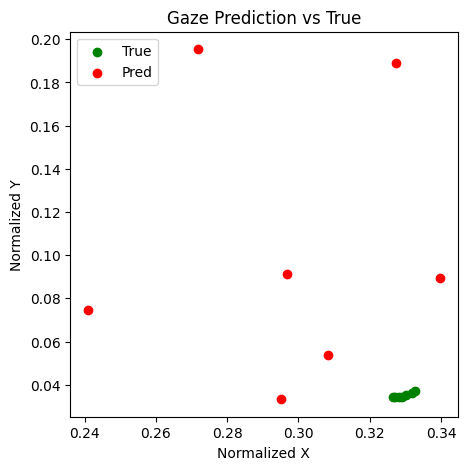

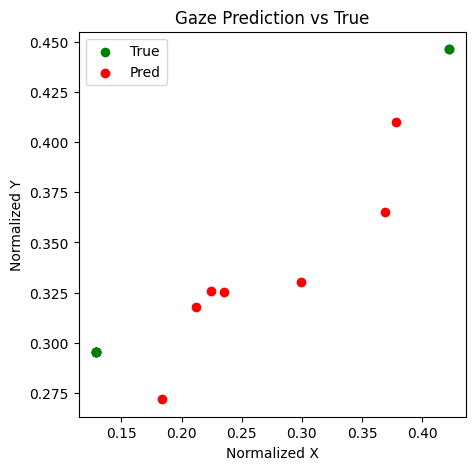

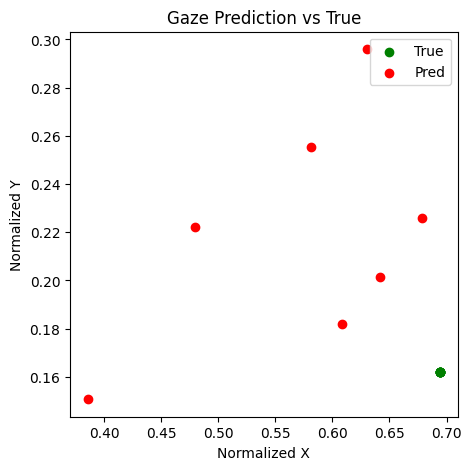

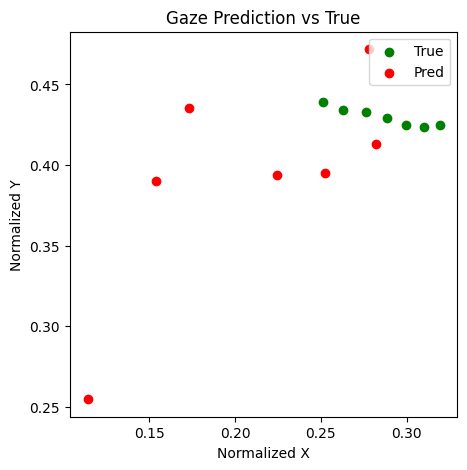

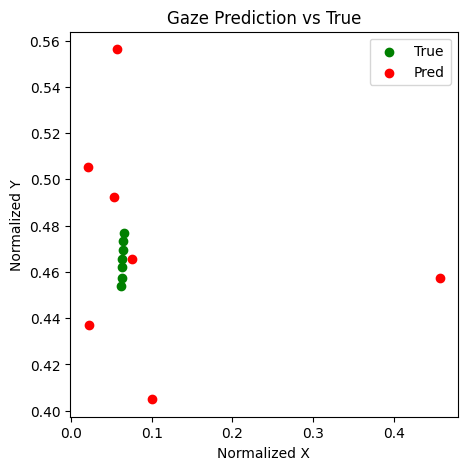

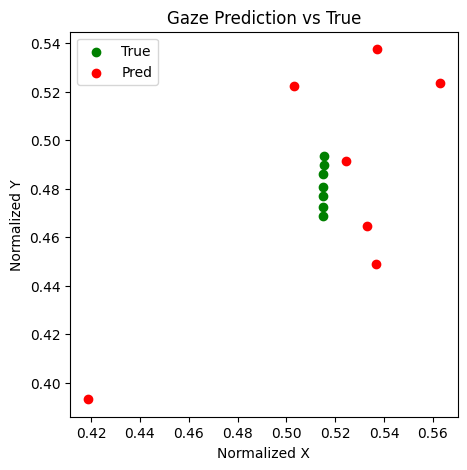

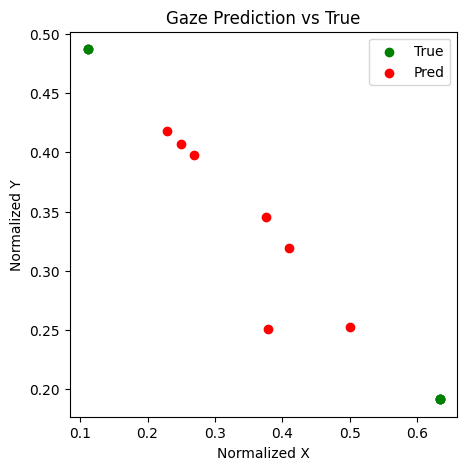

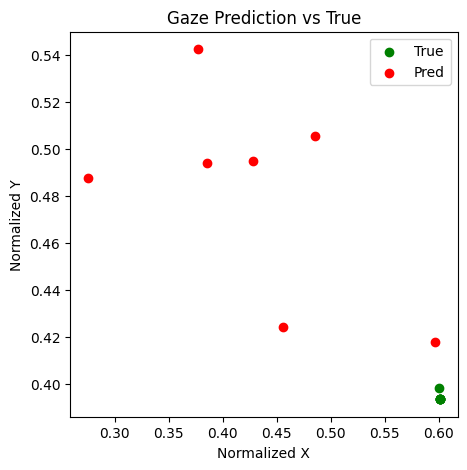

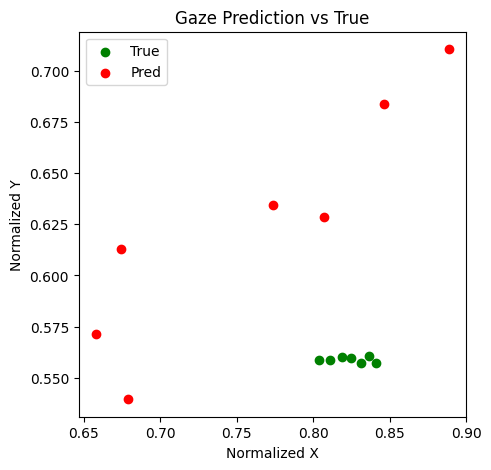

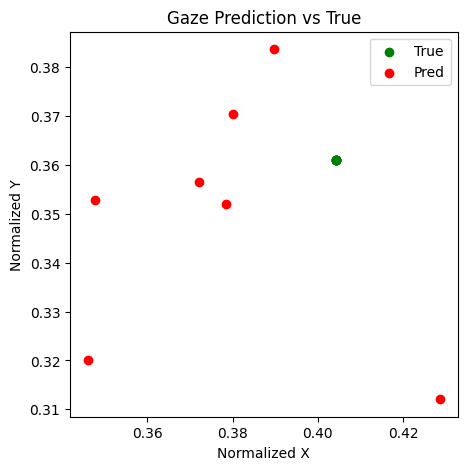

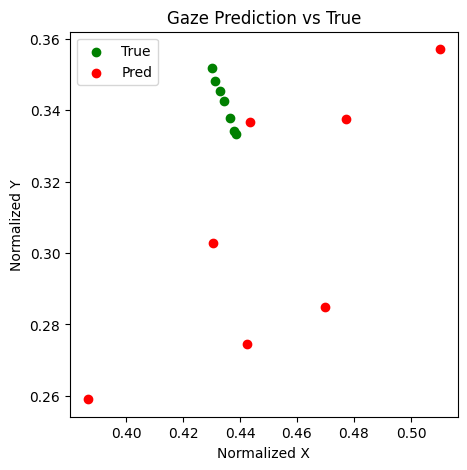

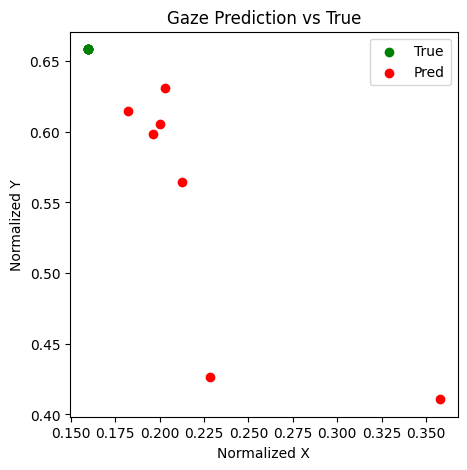

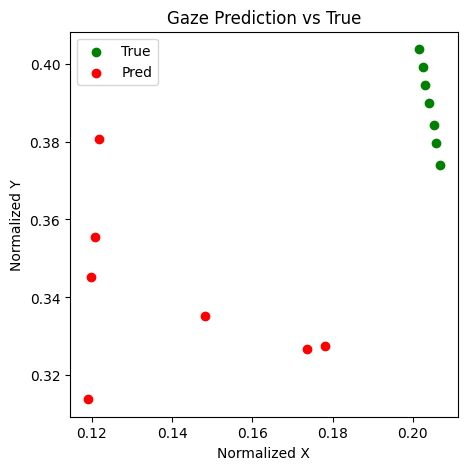

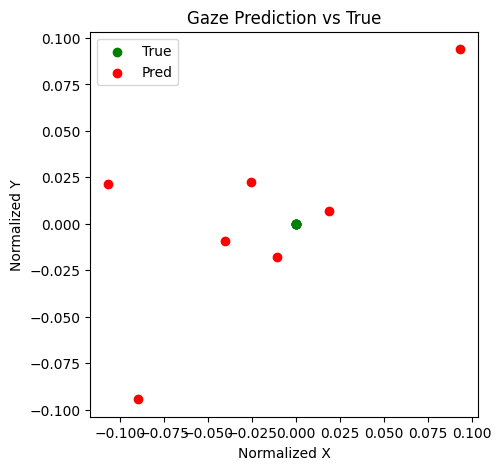

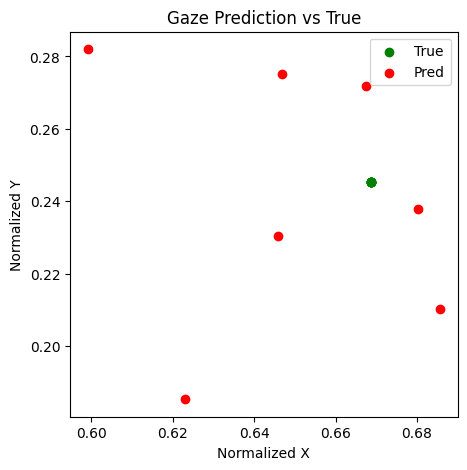

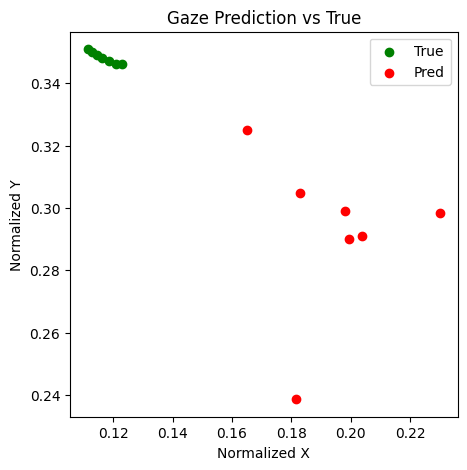

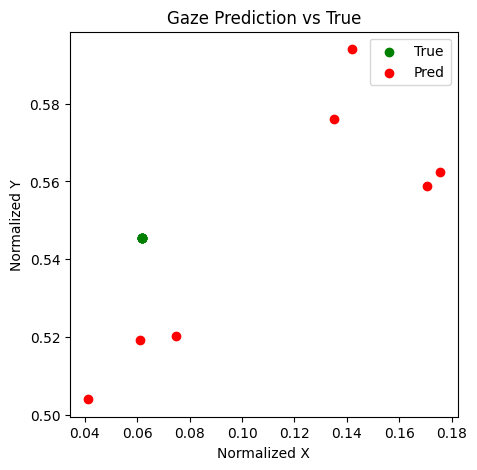

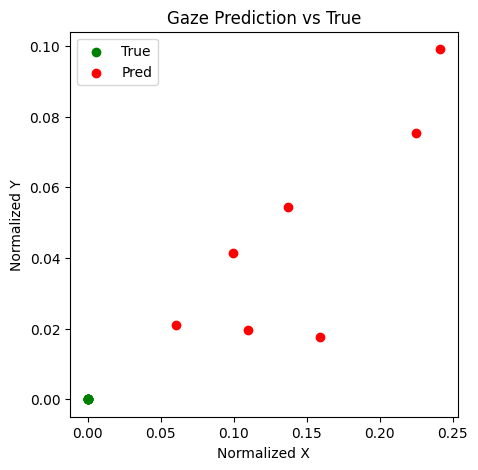

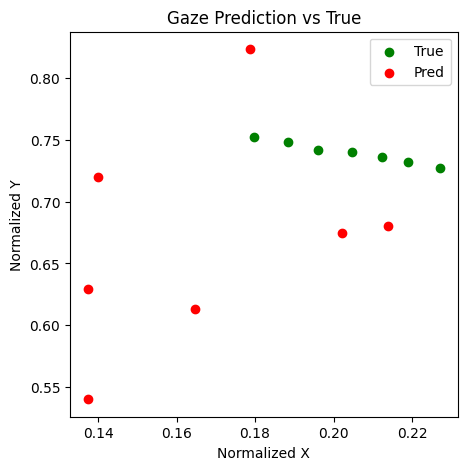

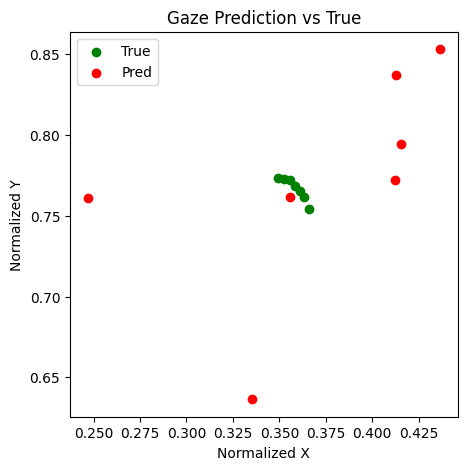

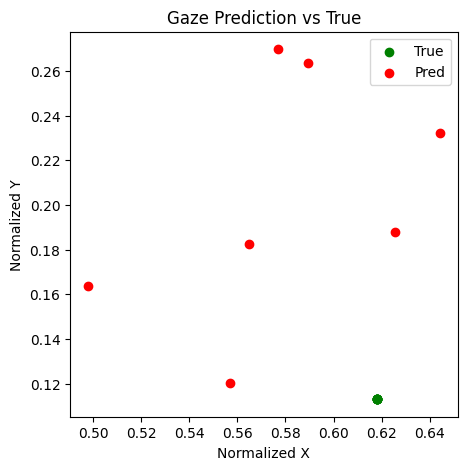

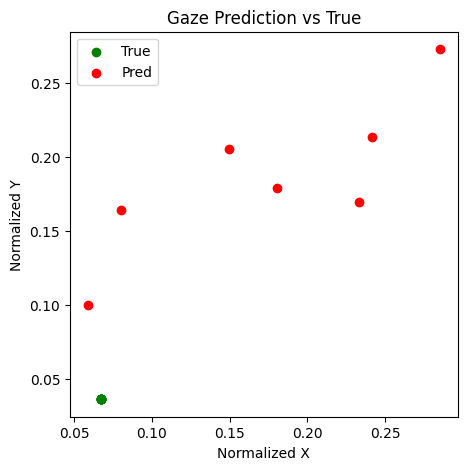

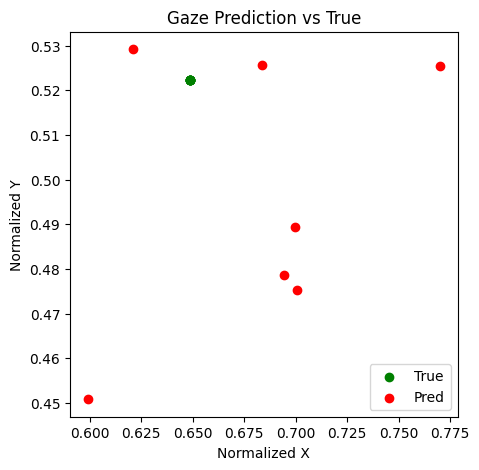

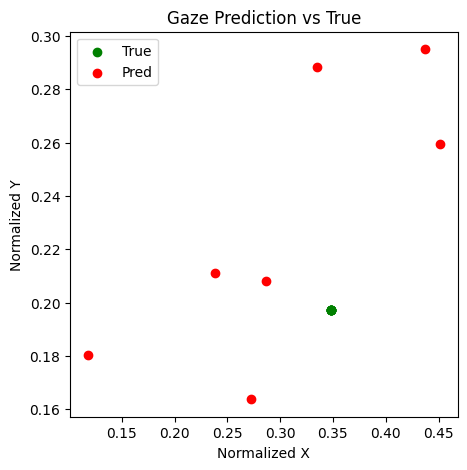

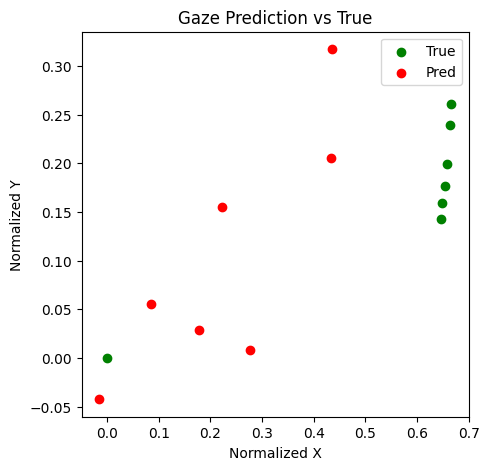

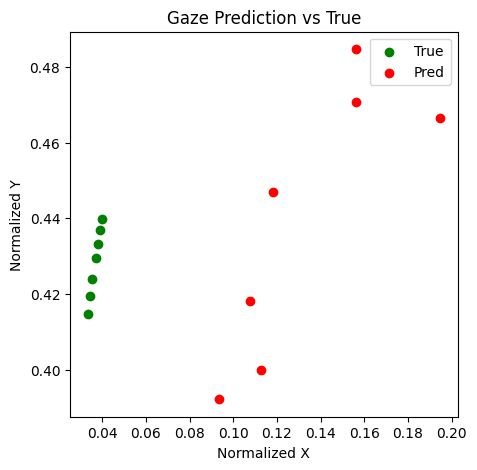

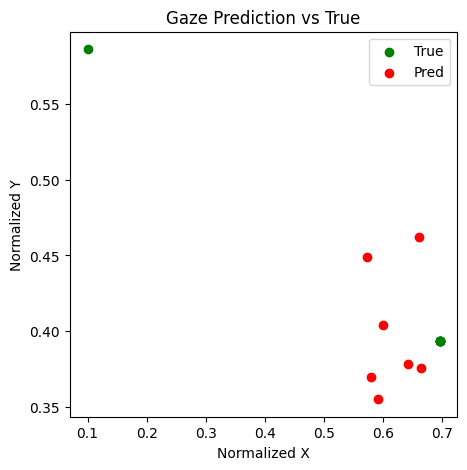

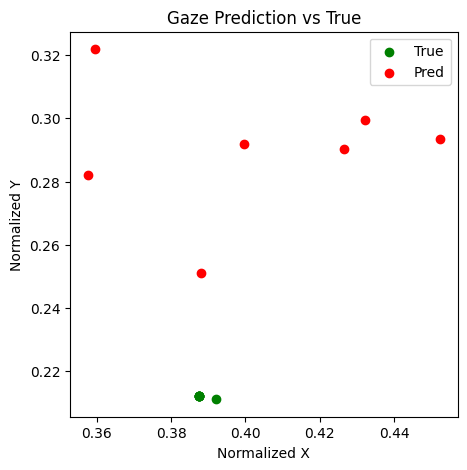

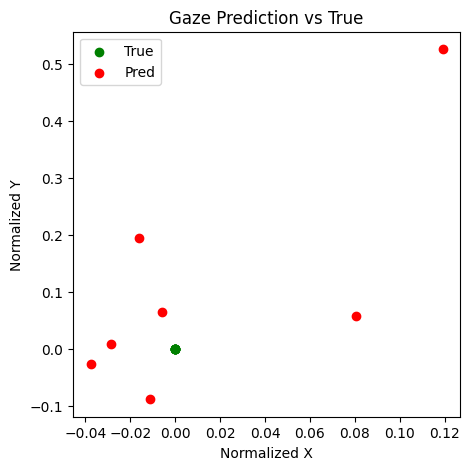

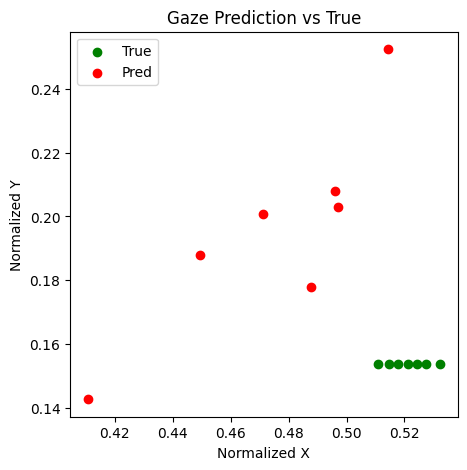

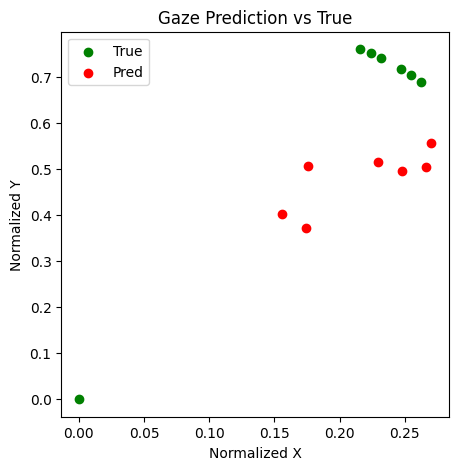

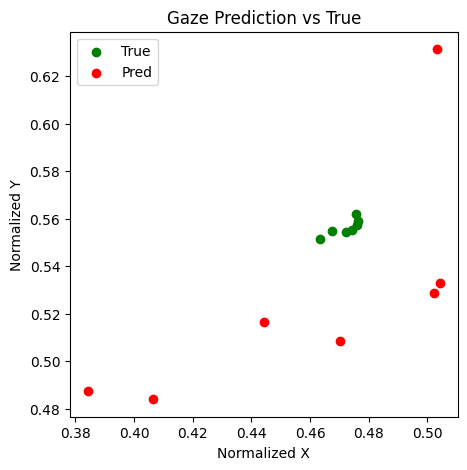

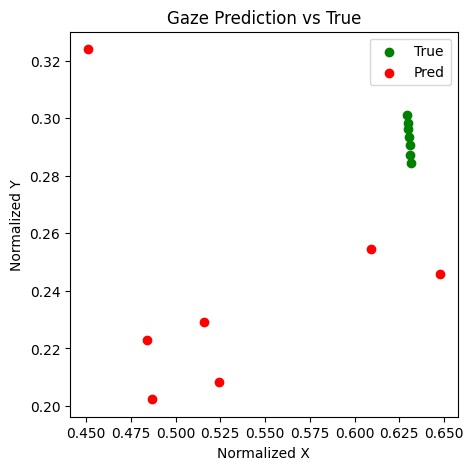

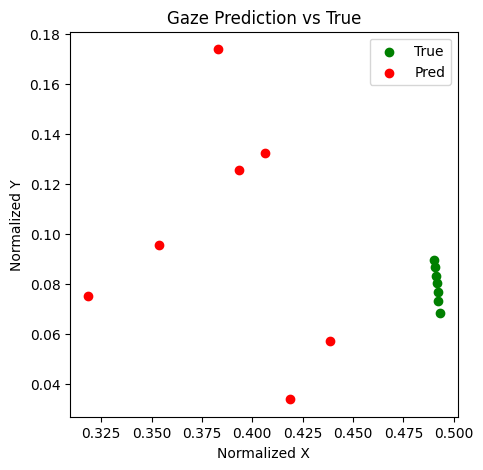

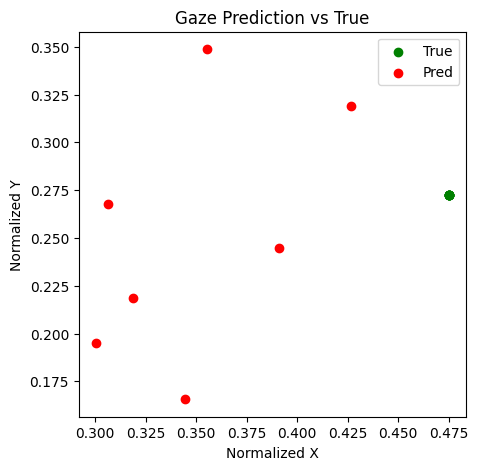

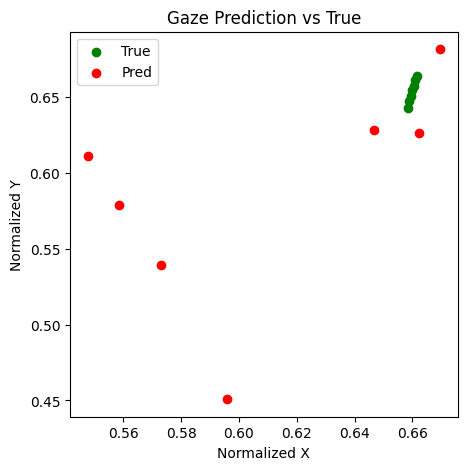

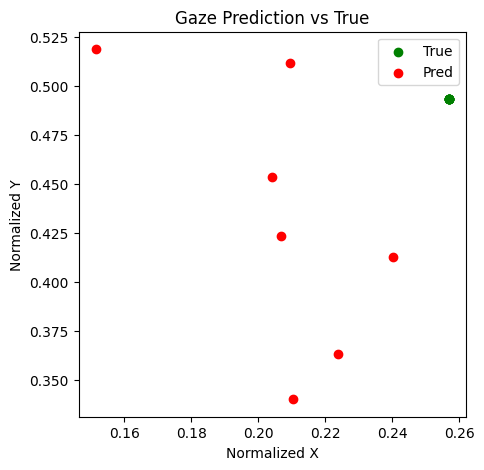

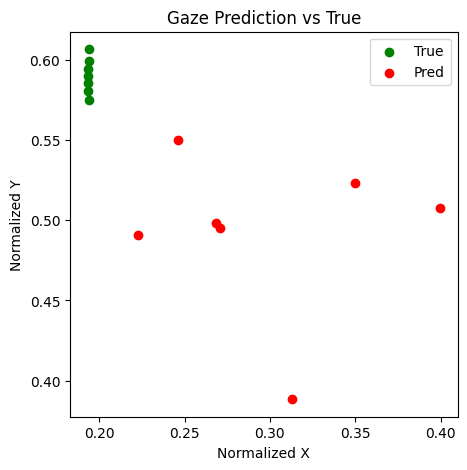

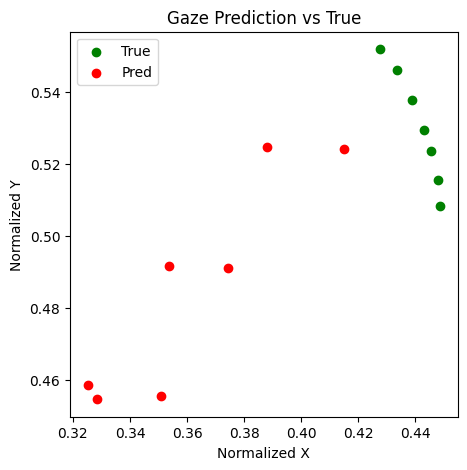

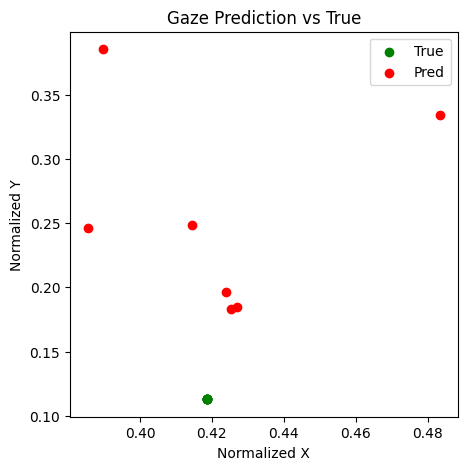

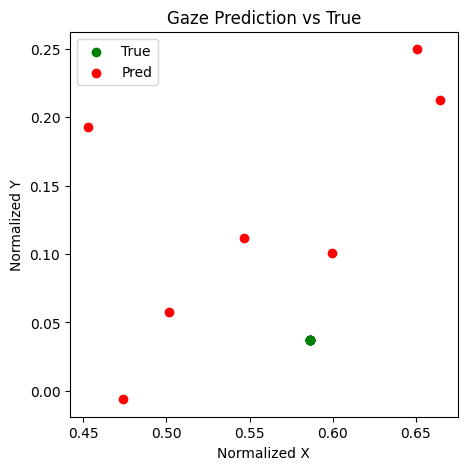

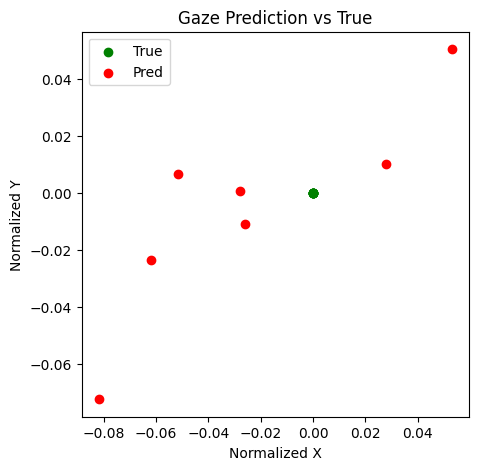

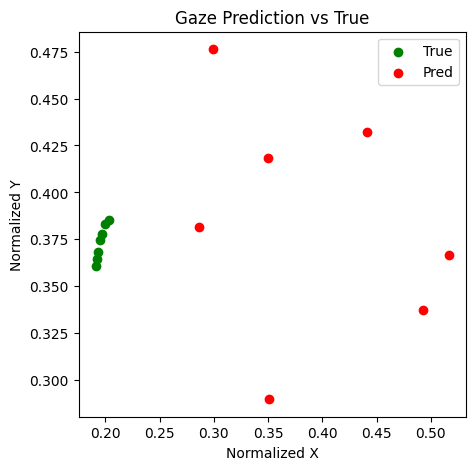

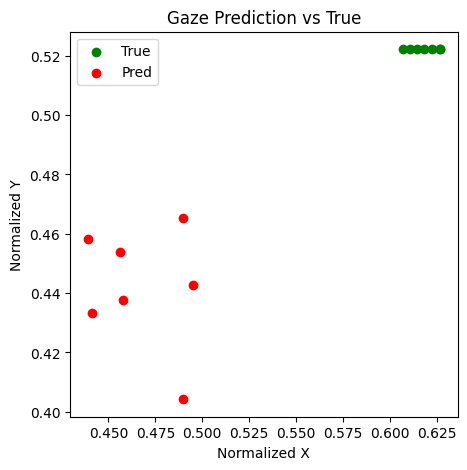

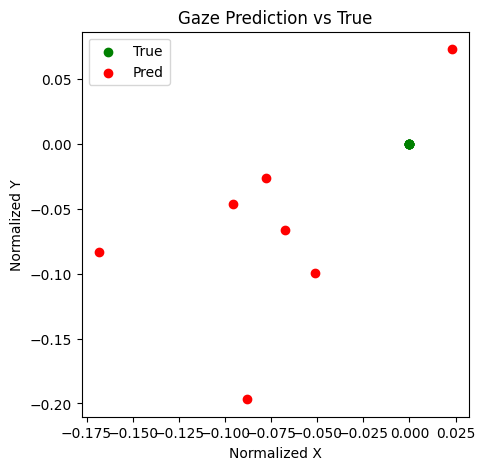

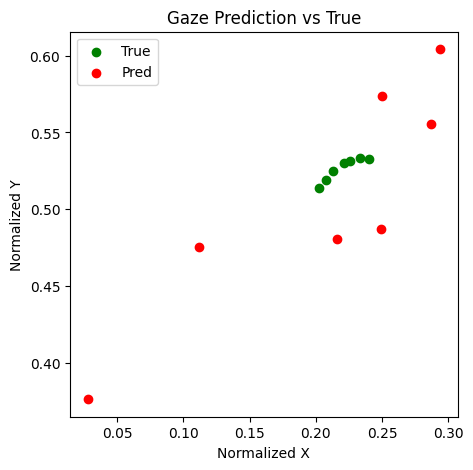

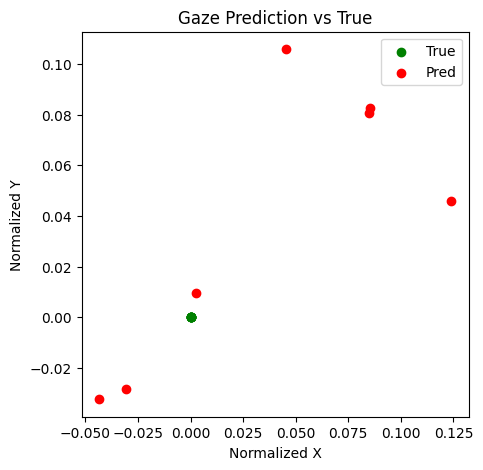

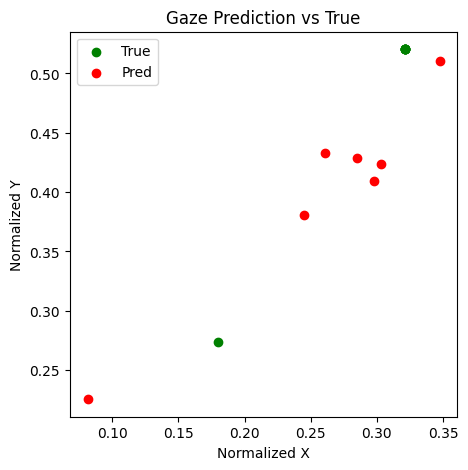

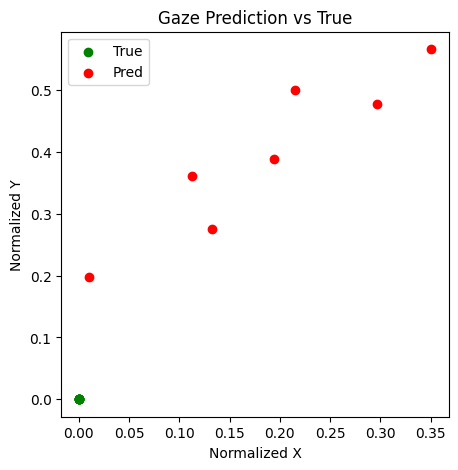

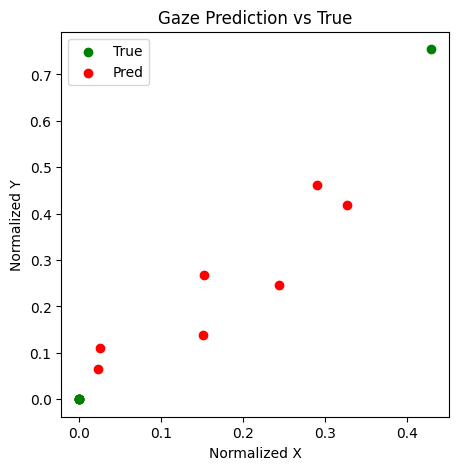

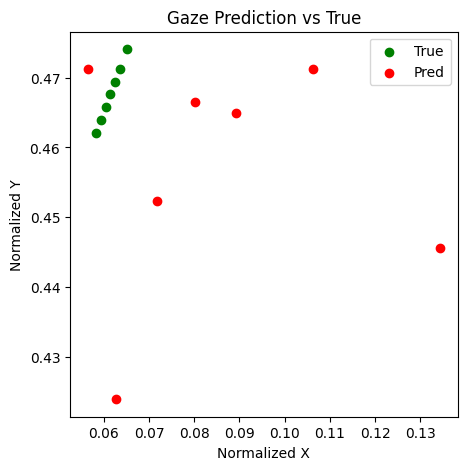

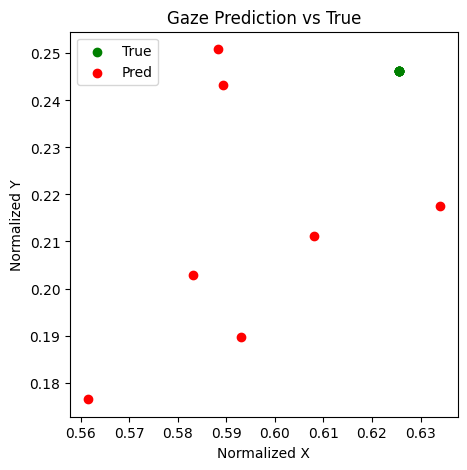

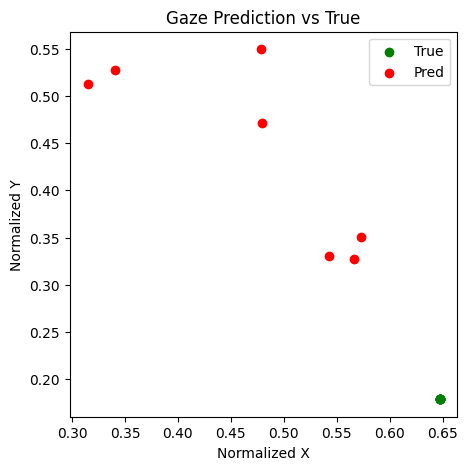

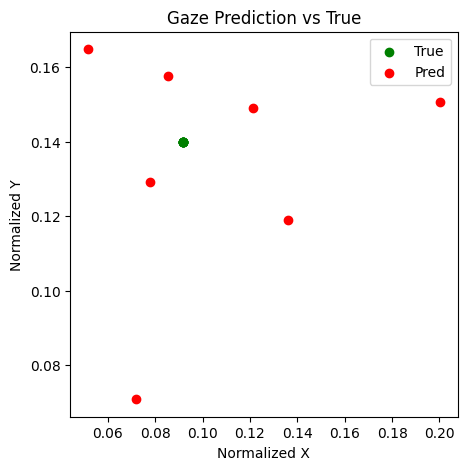

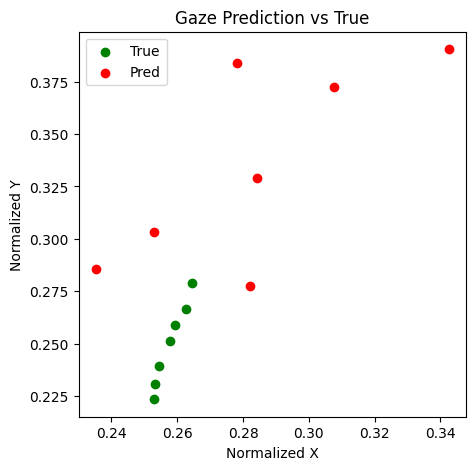

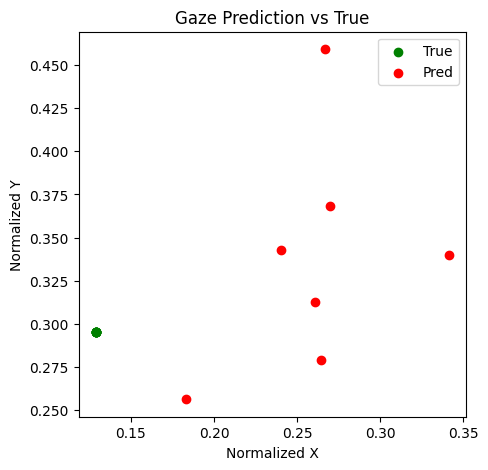

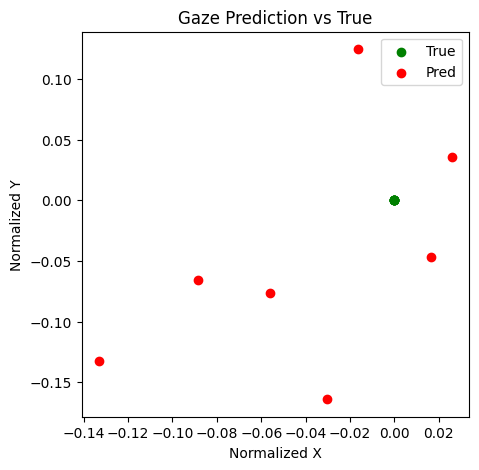

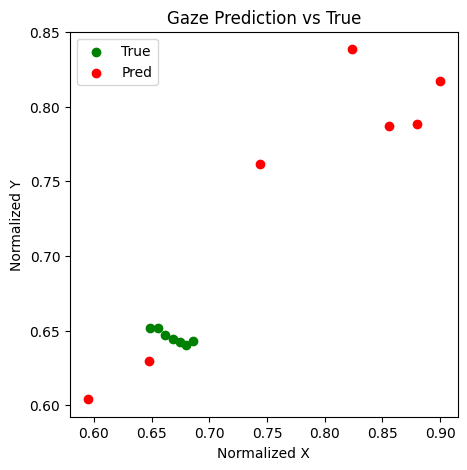

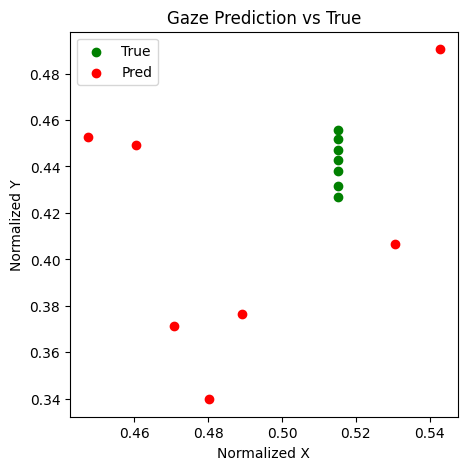

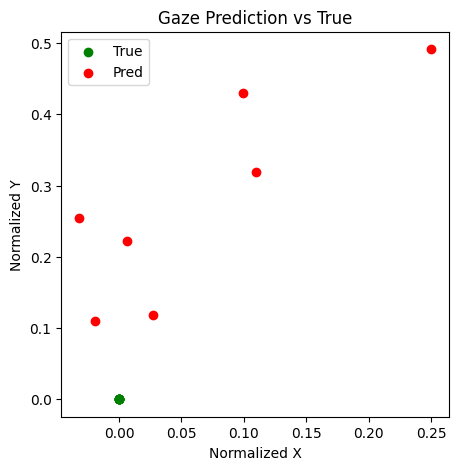

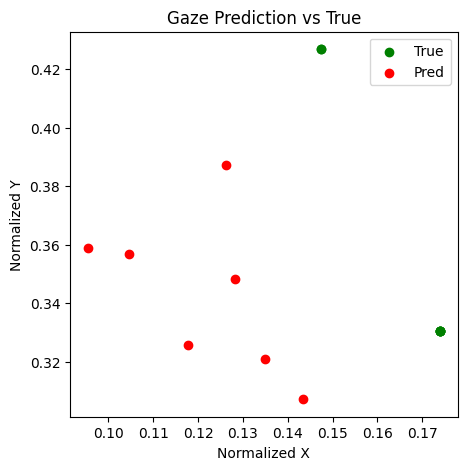

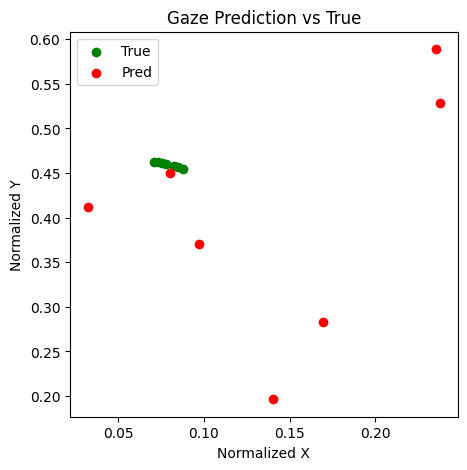

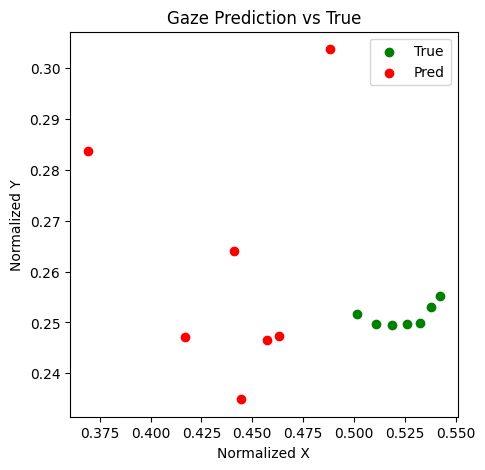

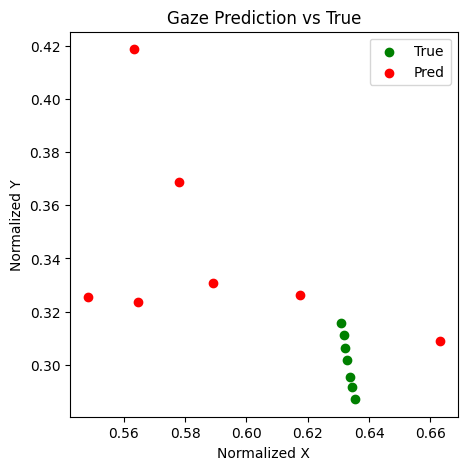

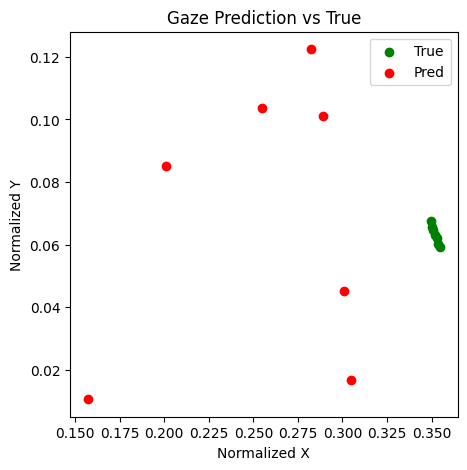

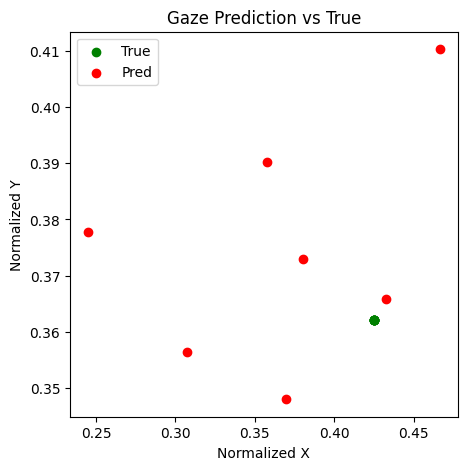

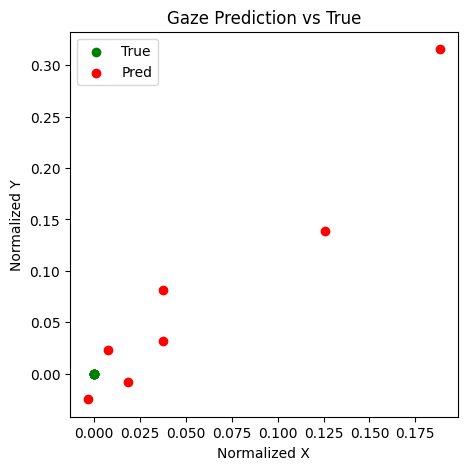

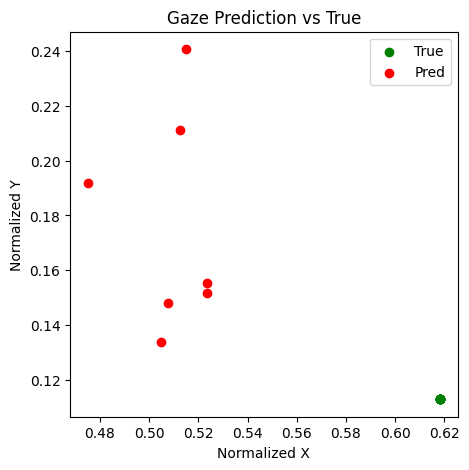

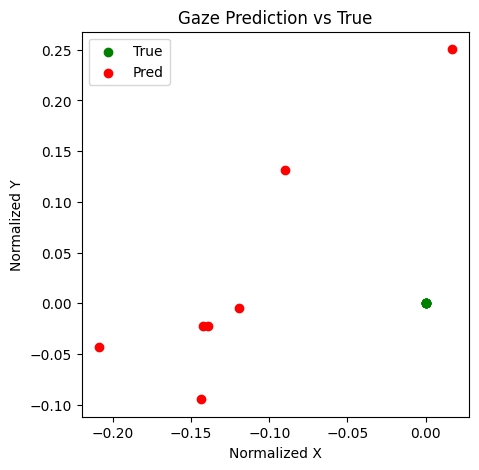

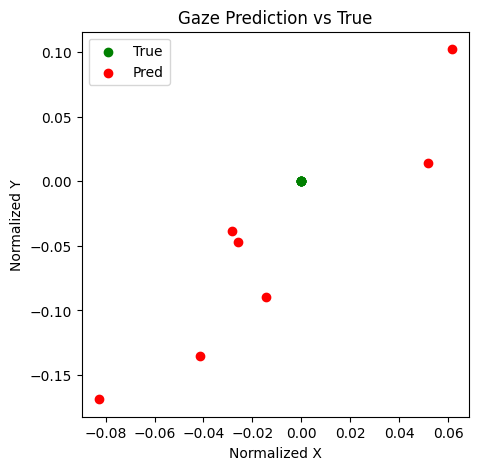

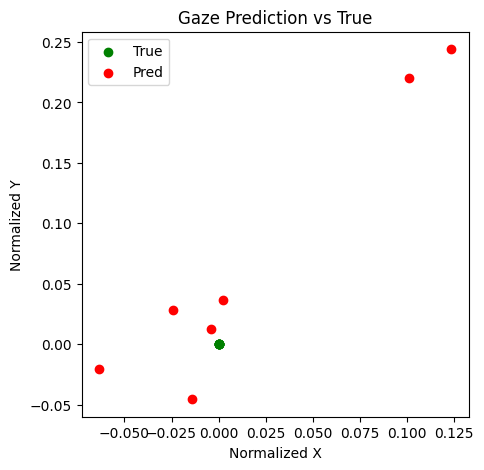

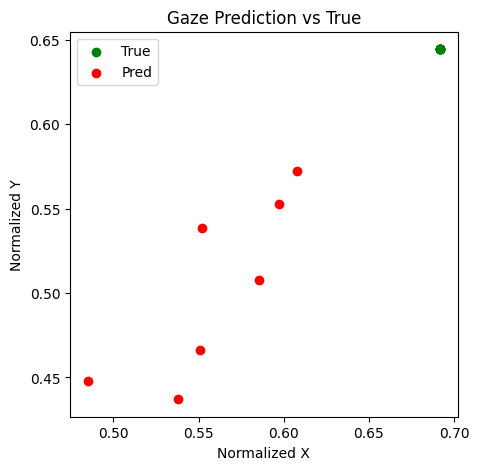

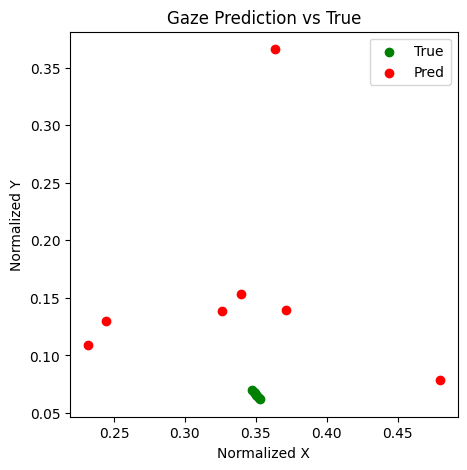

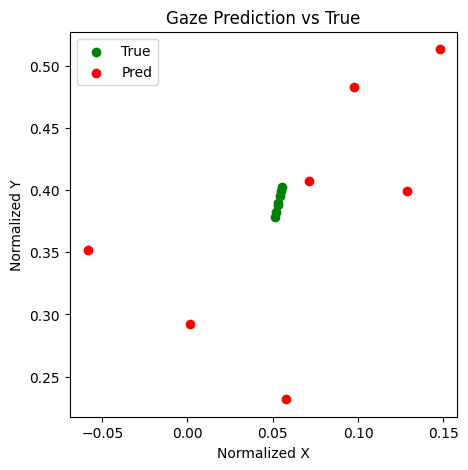

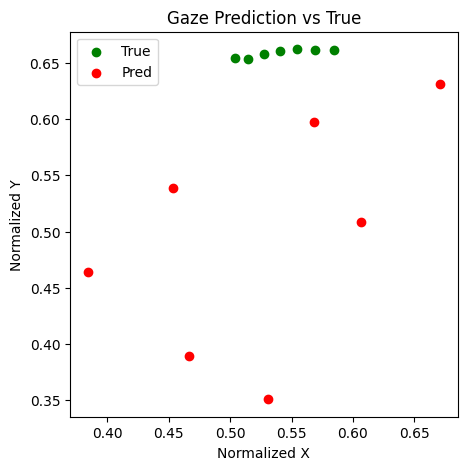

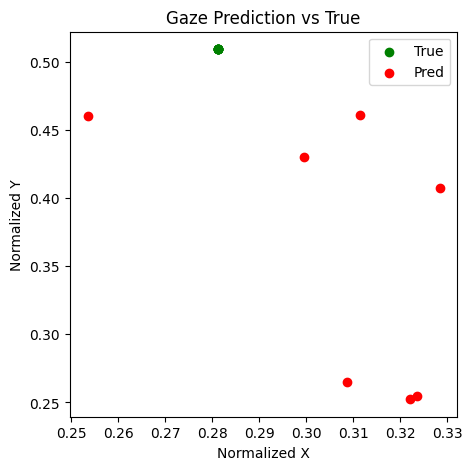

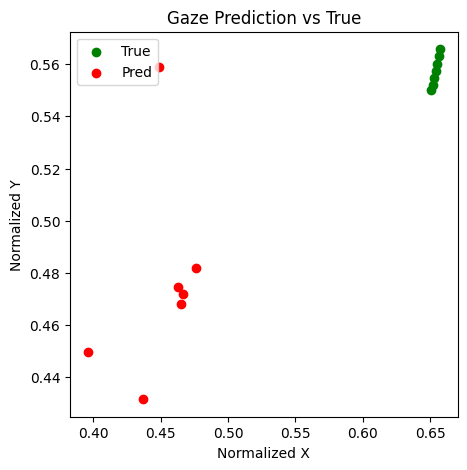

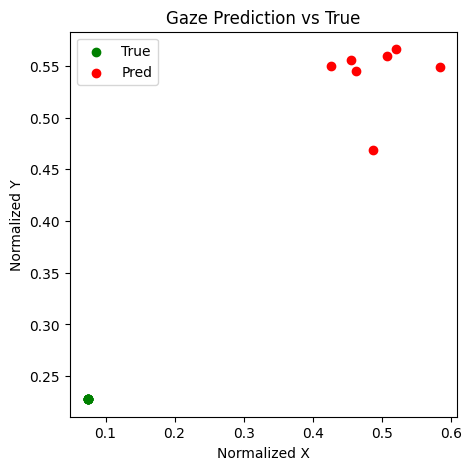

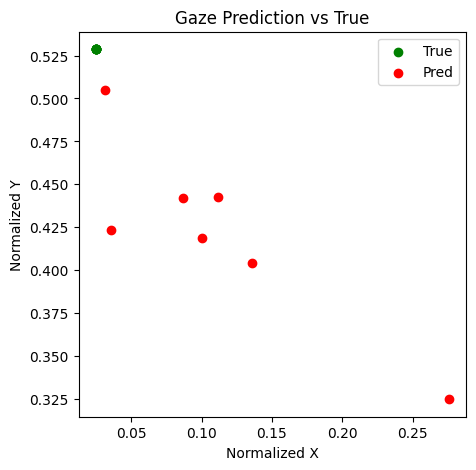

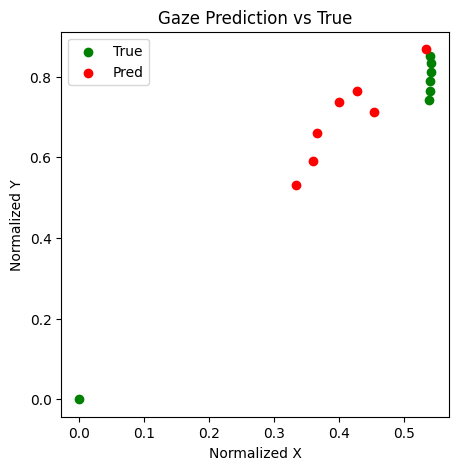

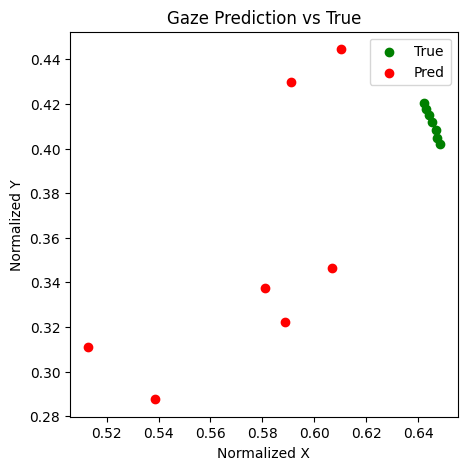

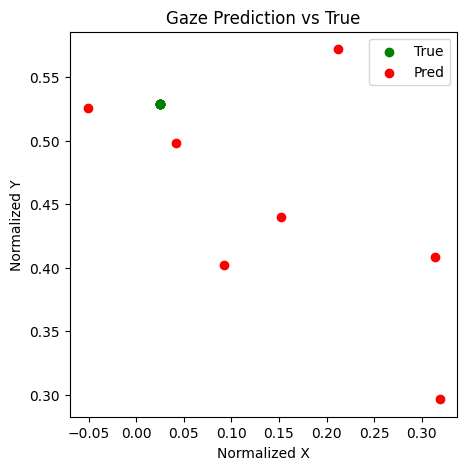

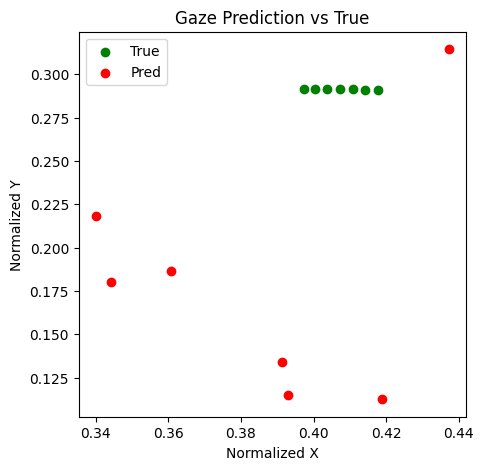

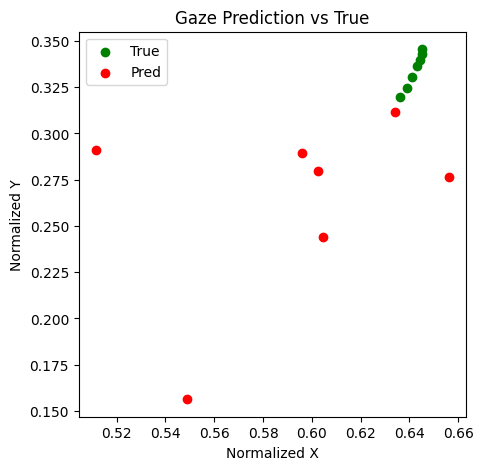

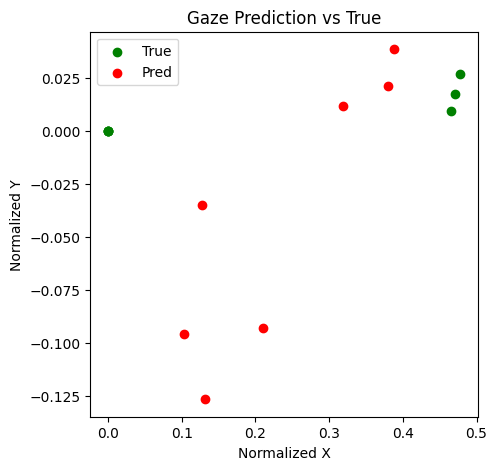

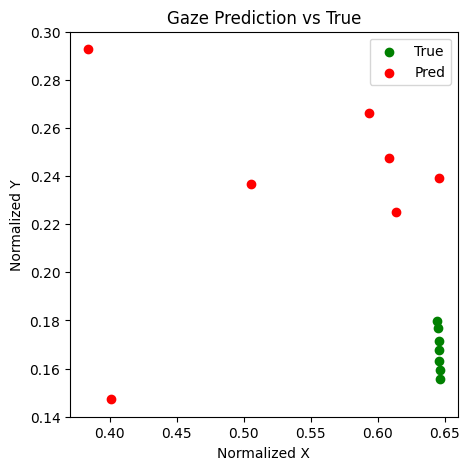

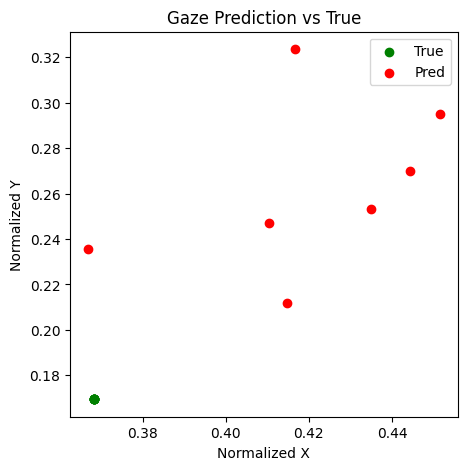

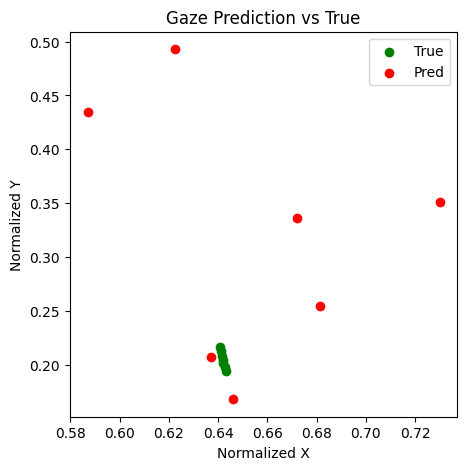

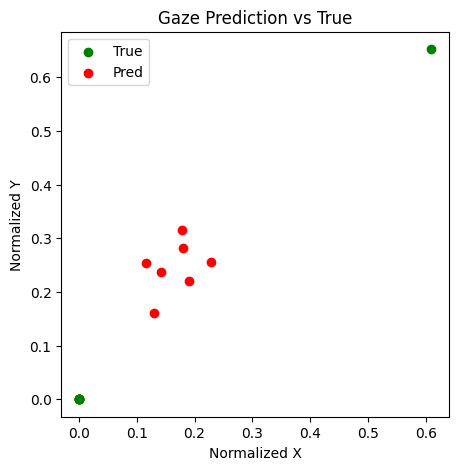

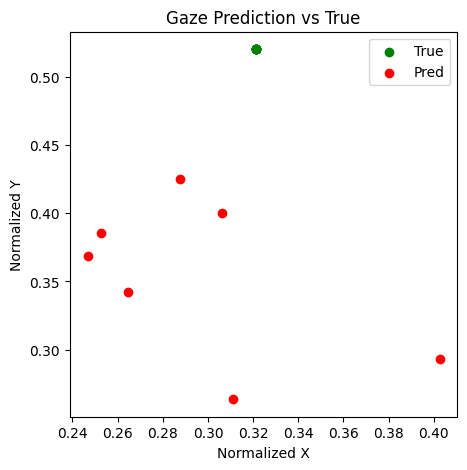

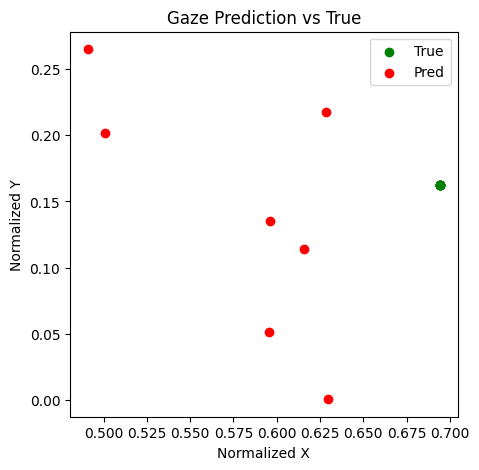

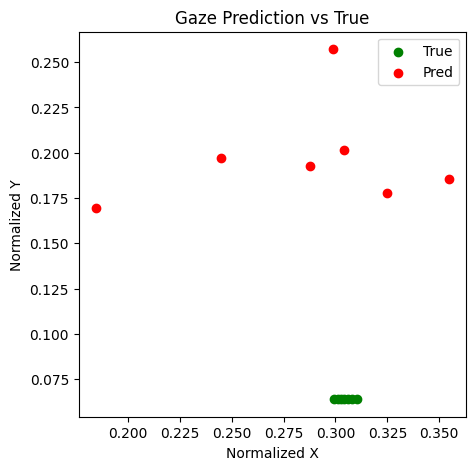

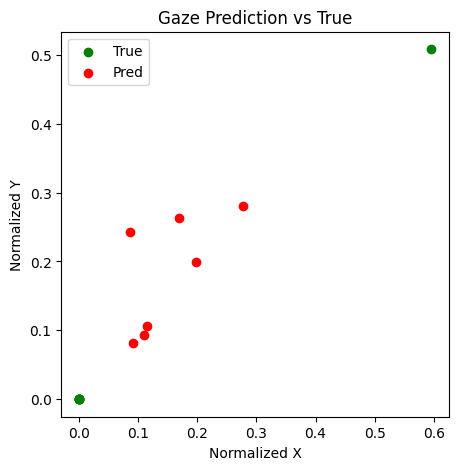

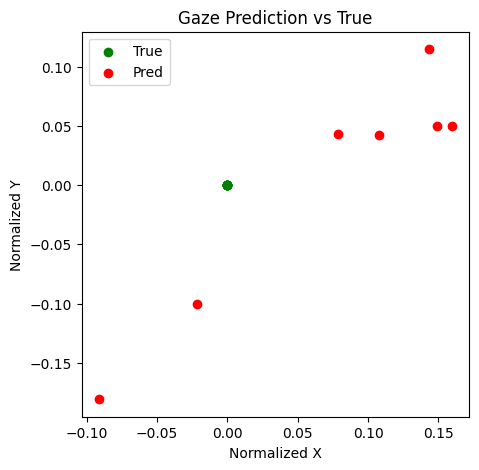

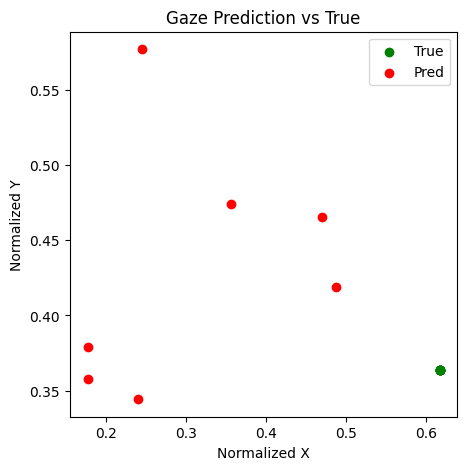

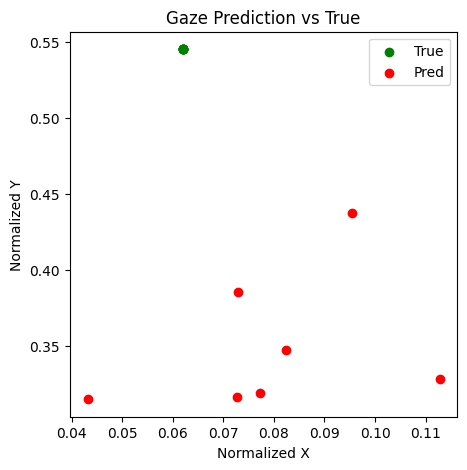

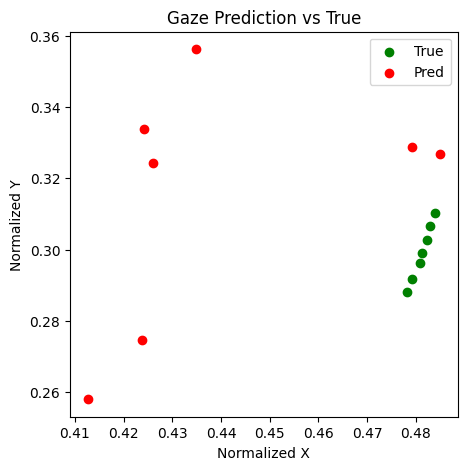

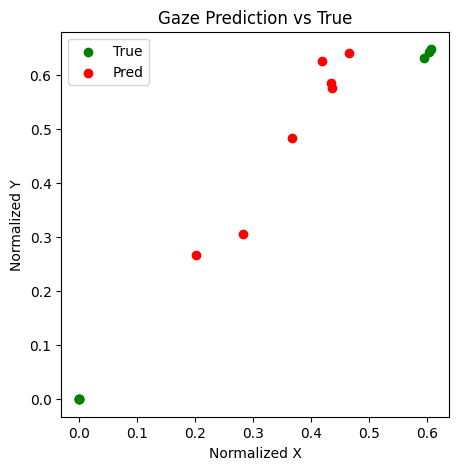

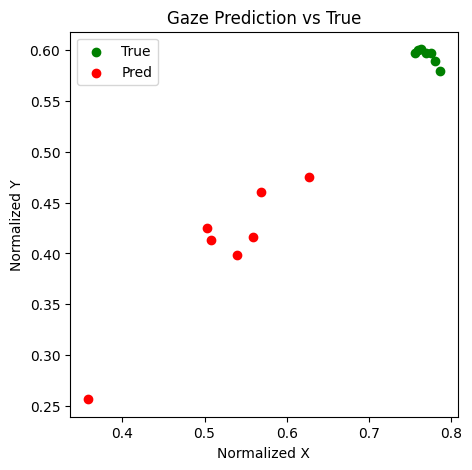

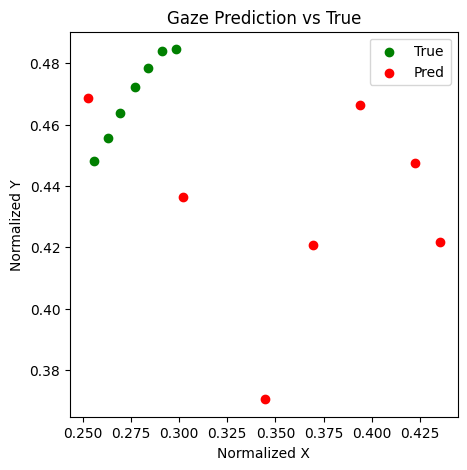

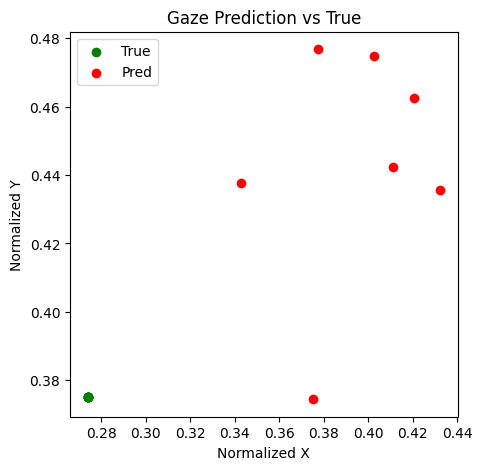

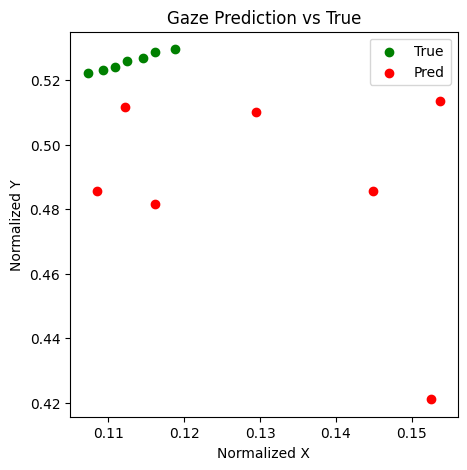

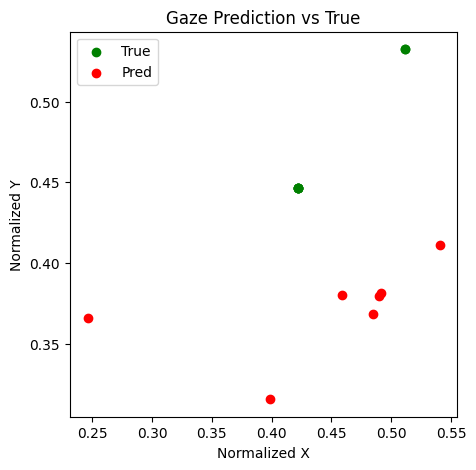

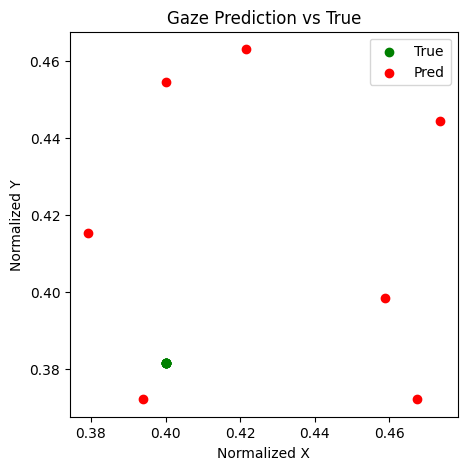

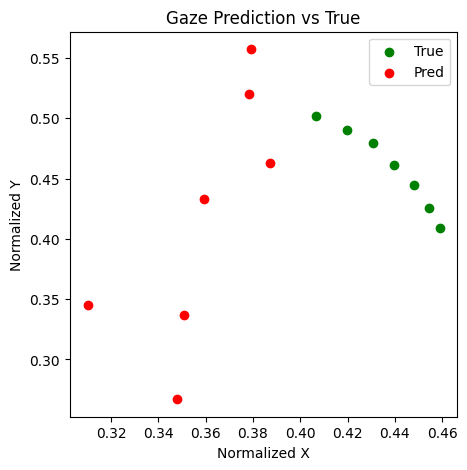

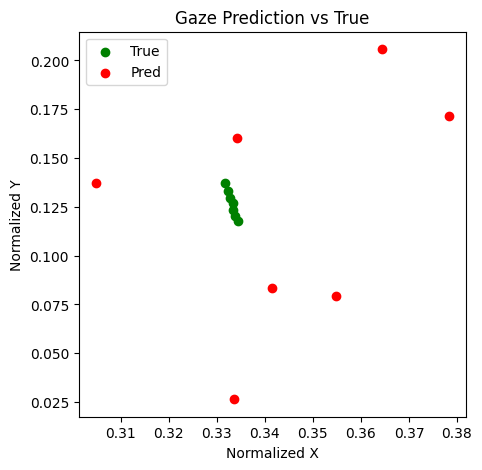

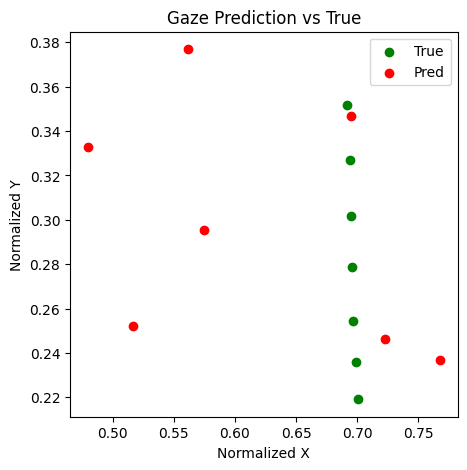

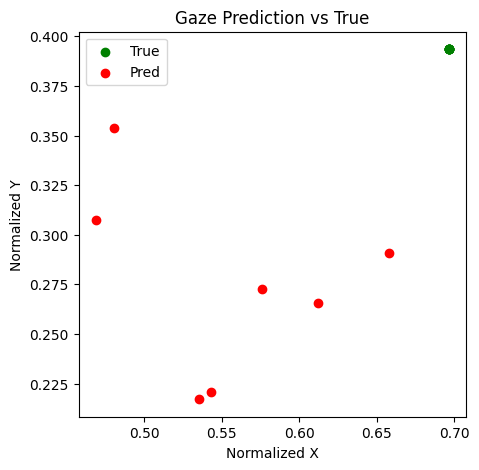

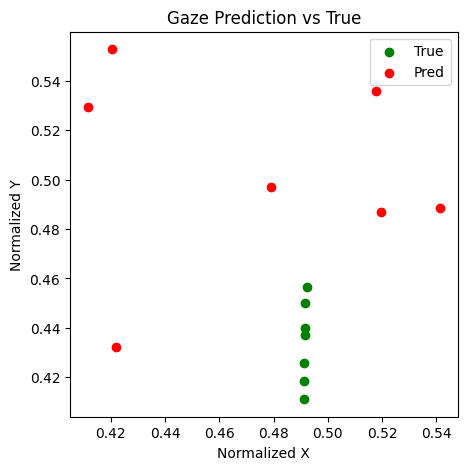

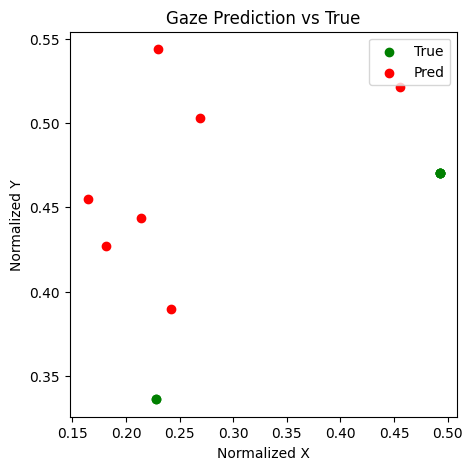

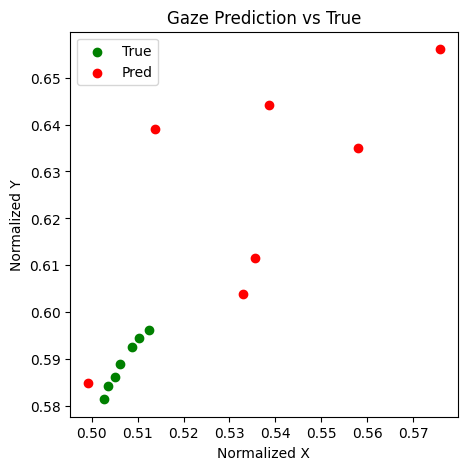

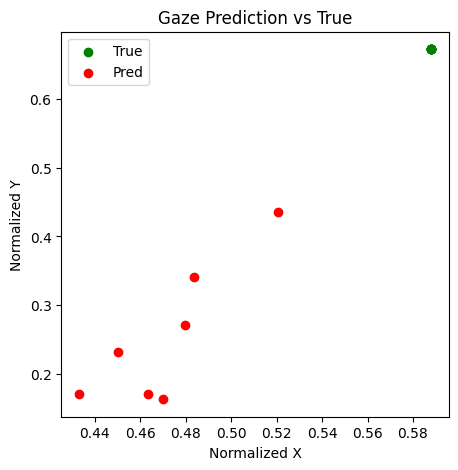

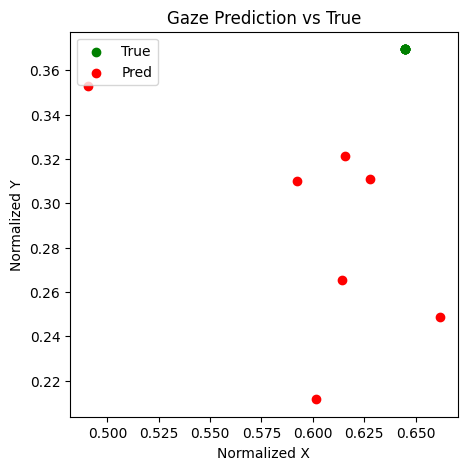

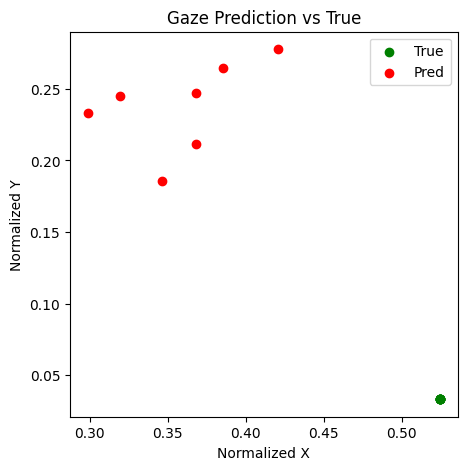

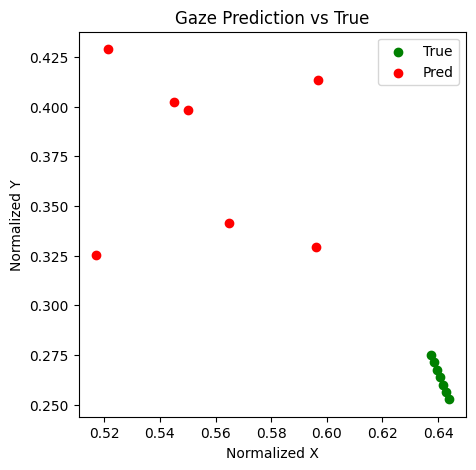

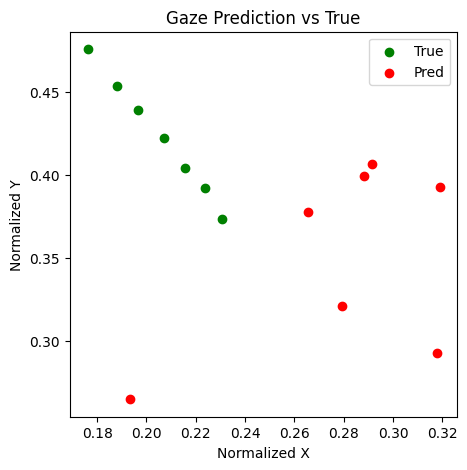

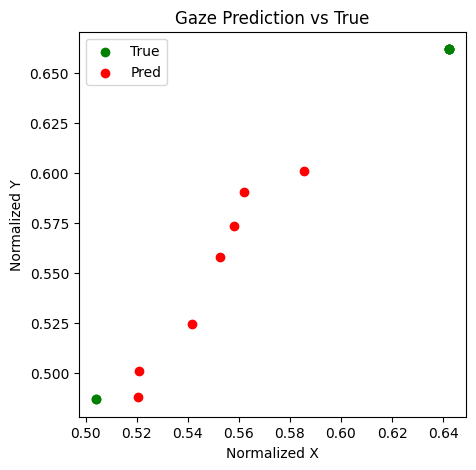

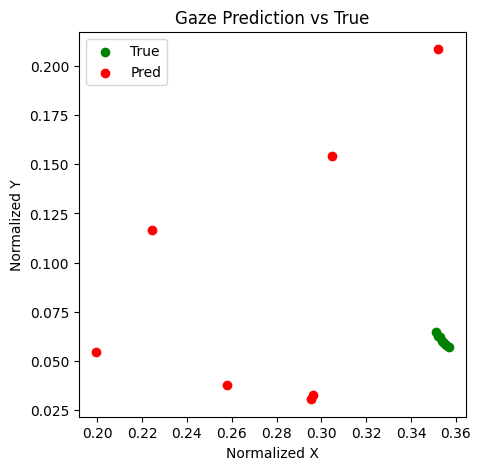

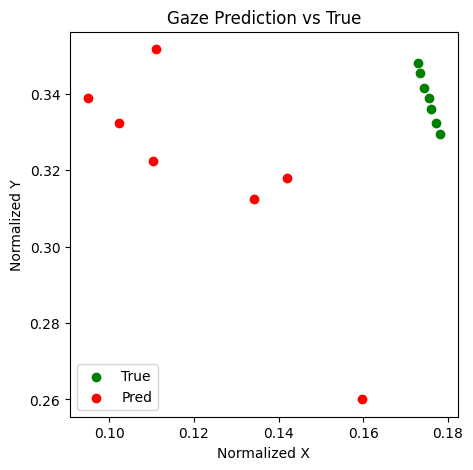

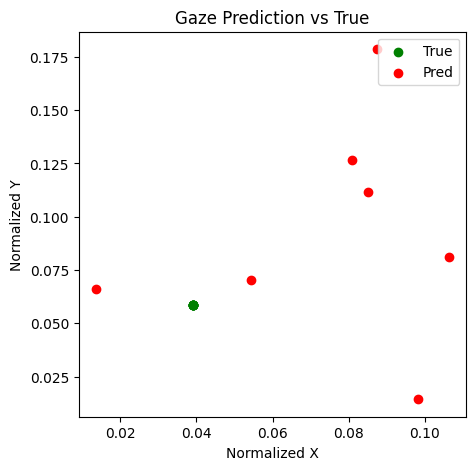

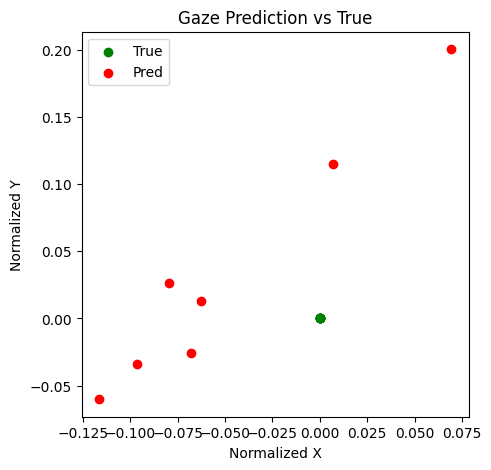

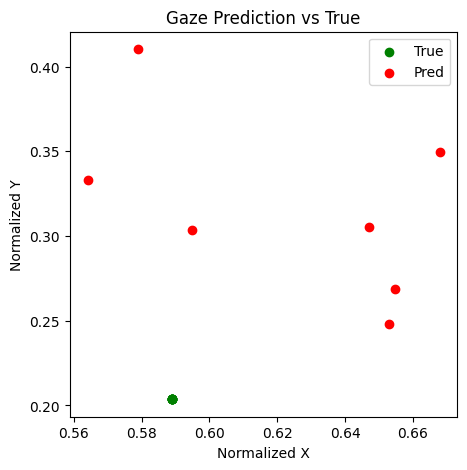

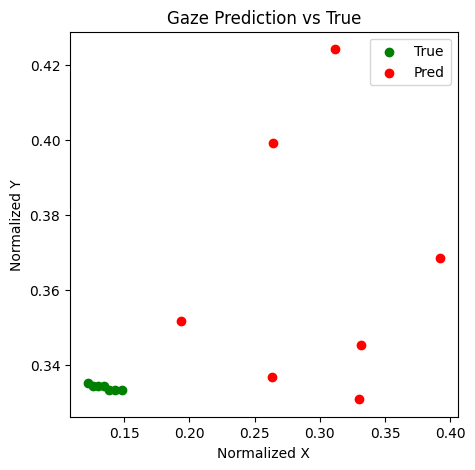

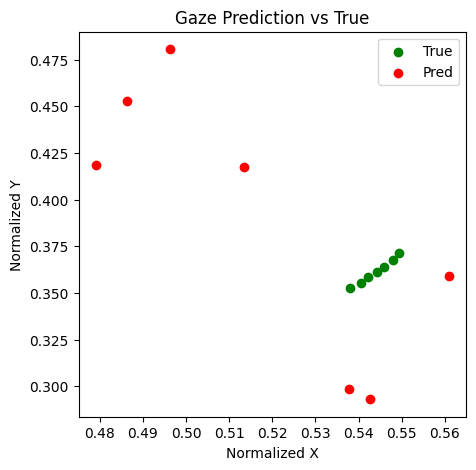

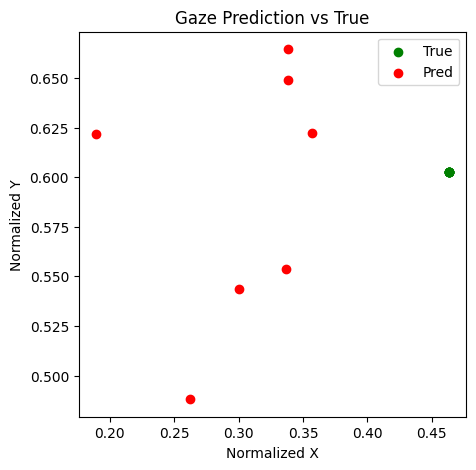

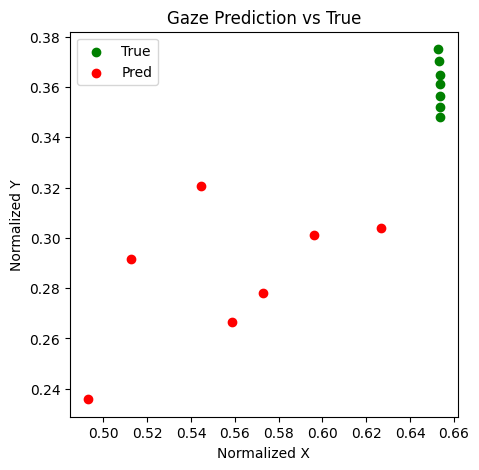

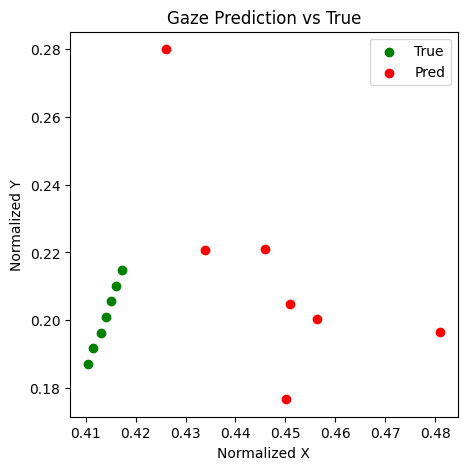

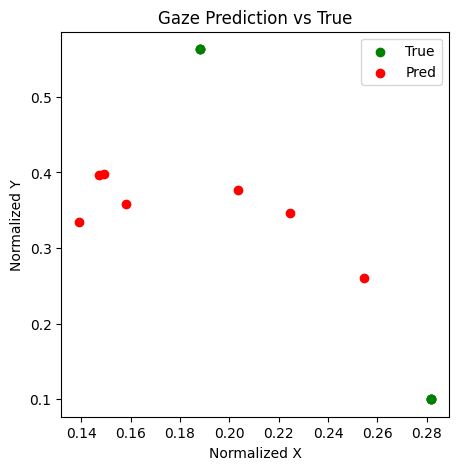

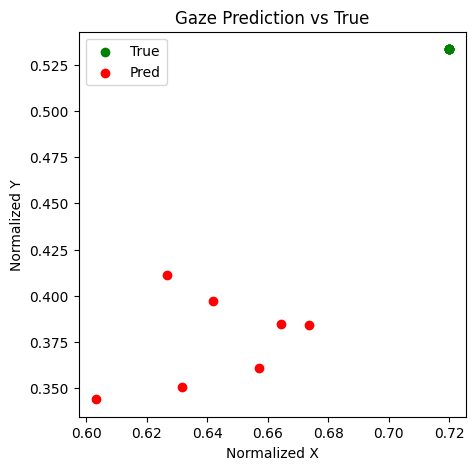

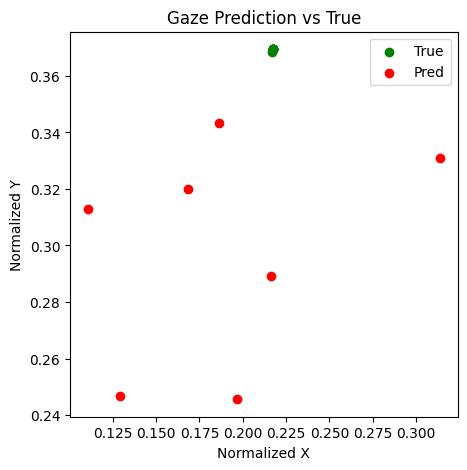

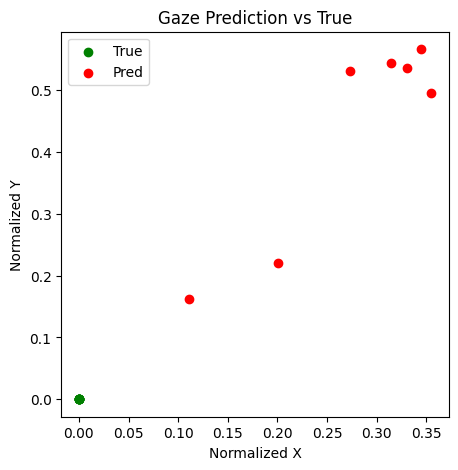

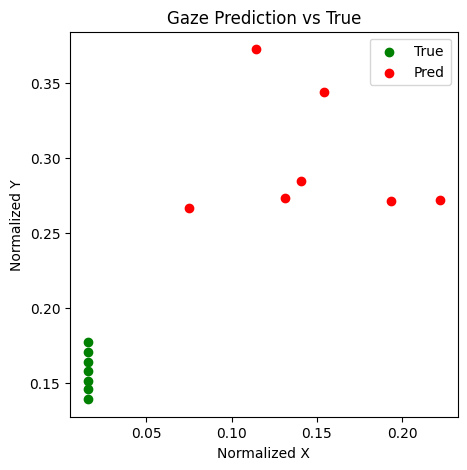

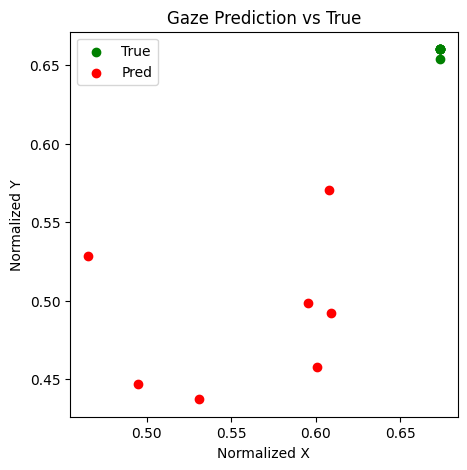

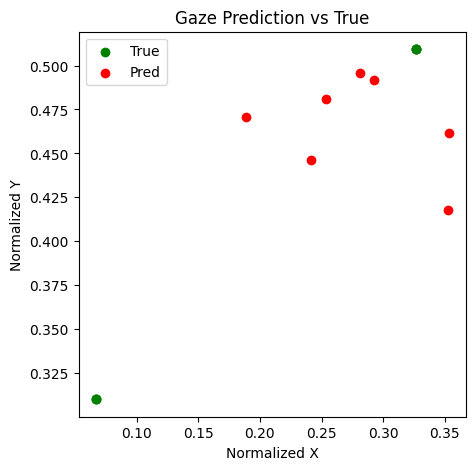

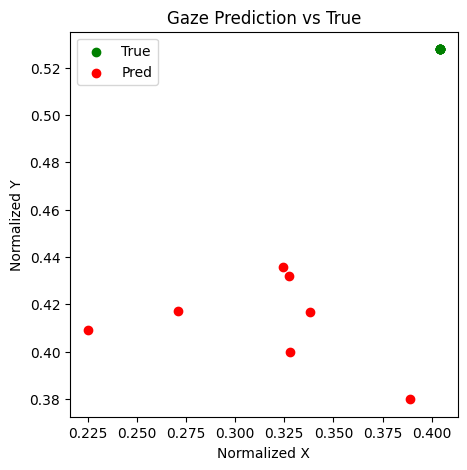

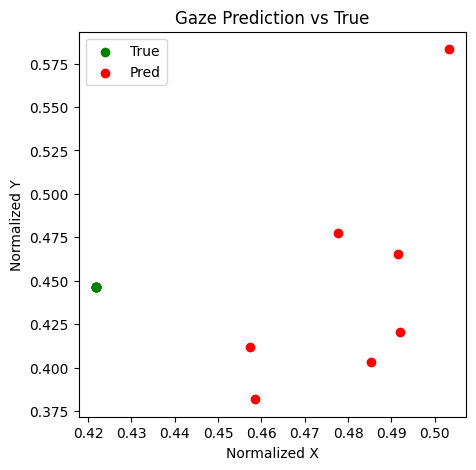

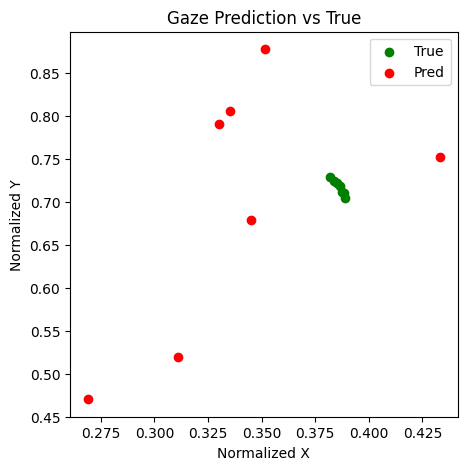

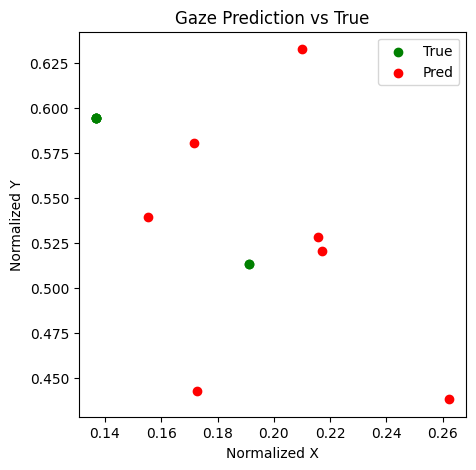

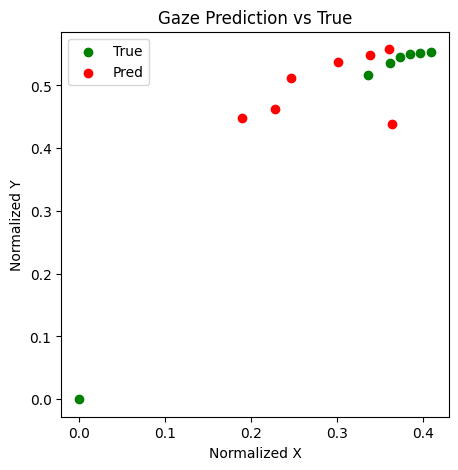

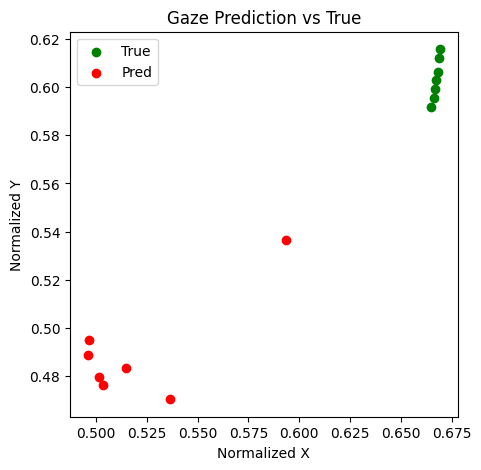

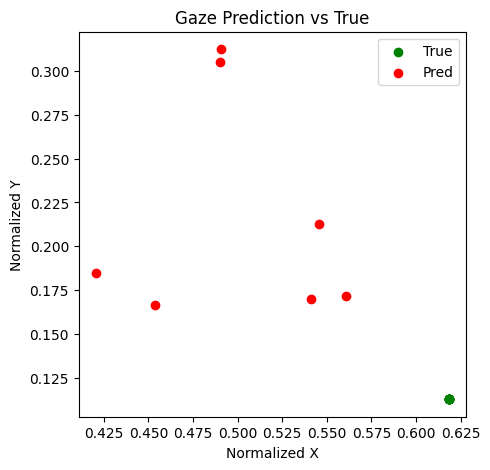

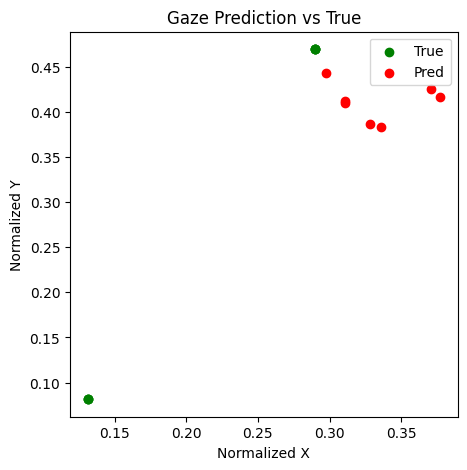

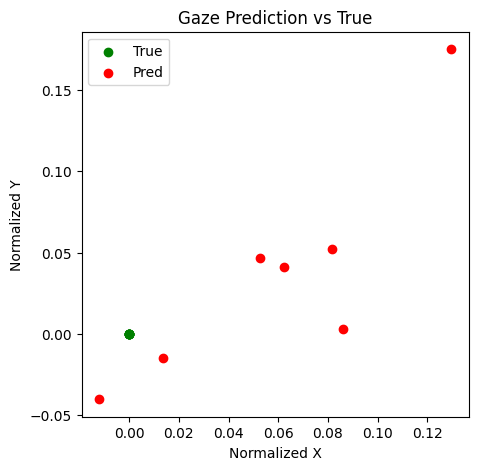

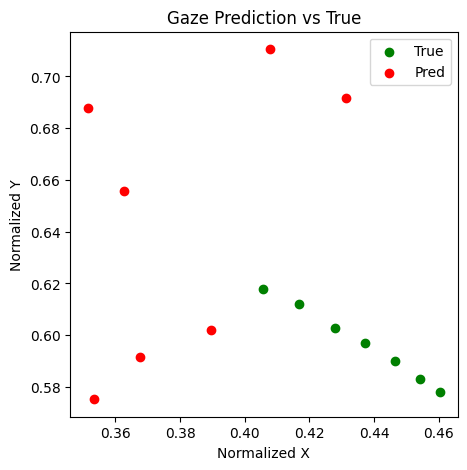

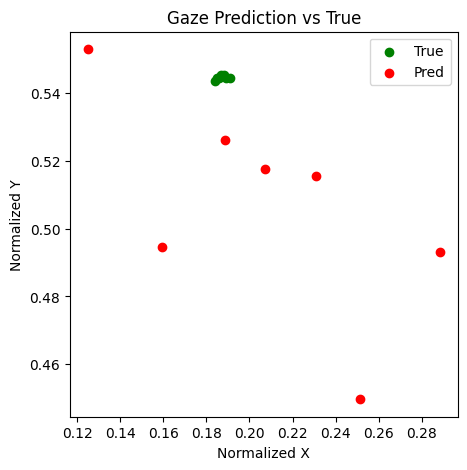

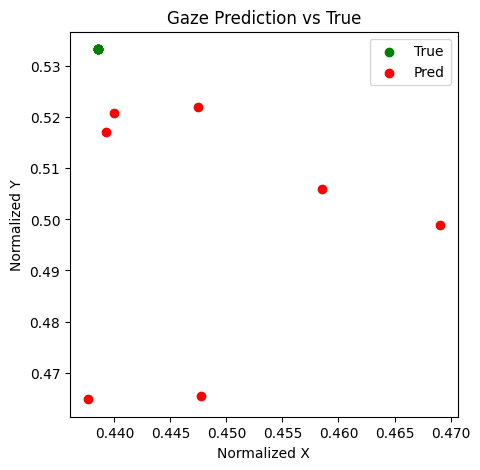

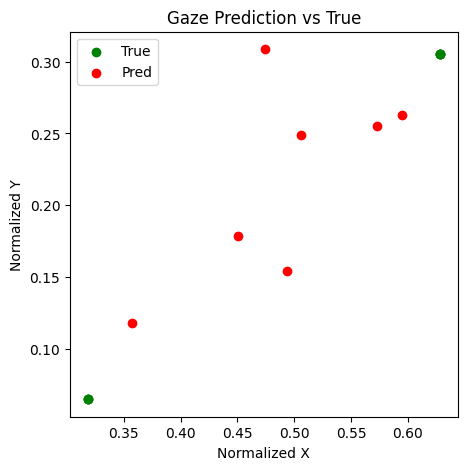

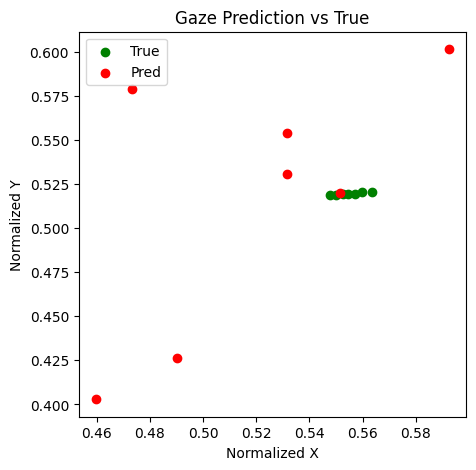

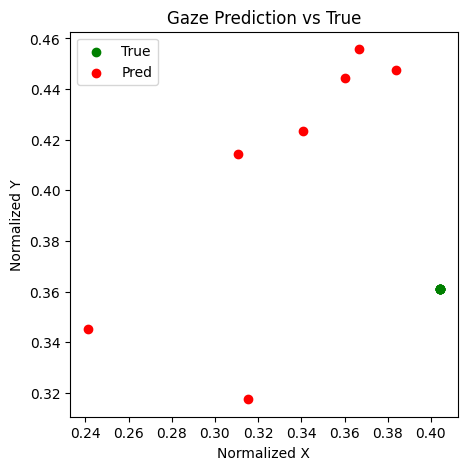

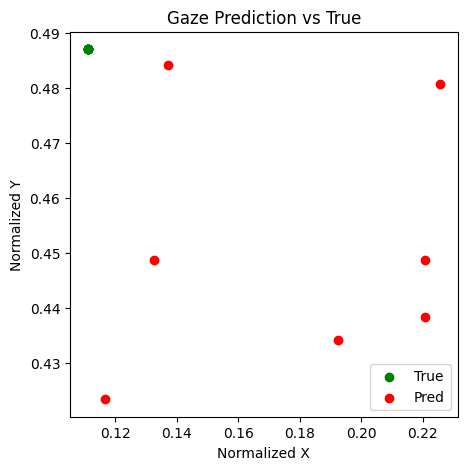

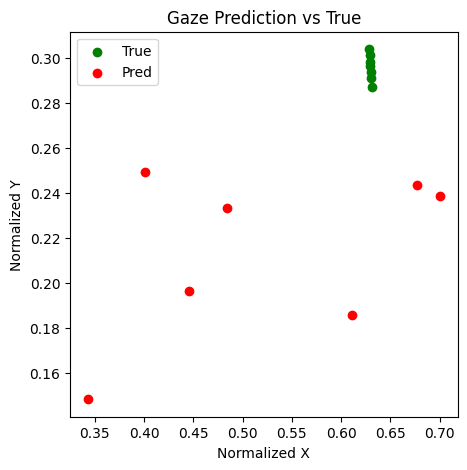

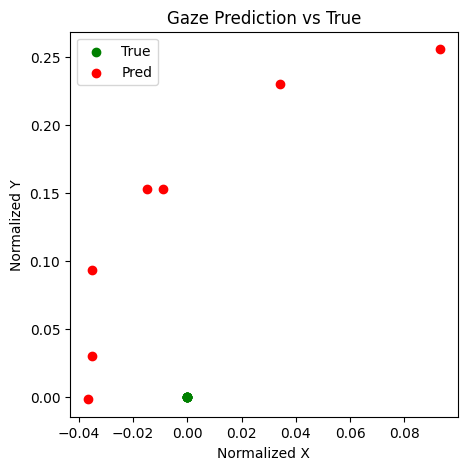

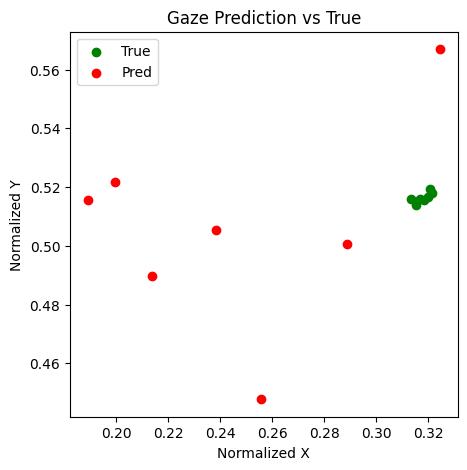

Mean Euclidean gaze error: 0.1486
Mean fixation stability (variance): 0.0049
Mean PRL offset from fovea: 0.3250


In [14]:
# -----------------------------
# EVALUATION & VISUALIZATION
# -----------------------------
def evaluate_and_plot(loader, model, n_samples=5):
    model.eval()
    errors = []
    fixation_var = []
    prl_offsets = []
    with torch.no_grad():
        for batch in loader:
            imgs = batch["image_seq"].to(DEVICE)
            gaze_true = batch["gaze_seq"].to(DEVICE)
            gaze_pred = model(imgs)
            diff = gaze_pred - gaze_true
            euc = torch.sqrt((diff**2).sum(dim=2))
            errors.append(euc.cpu().numpy())
            fixation_var.append(gaze_pred.var(dim=1).mean(dim=1).cpu().numpy())
            prl_offsets.append(compute_prl_offset(gaze_pred))

            # Visualize a few sequences
            for i in range(min(n_samples, imgs.shape[0])):
                plt.figure(figsize=(5,5))
                plt.scatter(gaze_true[i,:,0].cpu(), gaze_true[i,:,1].cpu(), label="True", c='g')
                plt.scatter(gaze_pred[i,:,0].cpu(), gaze_pred[i,:,1].cpu(), label="Pred", c='r')
                plt.title("Gaze Prediction vs True")
                plt.xlabel("Normalized X")
                plt.ylabel("Normalized Y")
                plt.legend()
                plt.show()

    errors = np.concatenate(errors)
    fixation_var = np.concatenate(fixation_var)
    print(f"Mean Euclidean gaze error: {errors.mean():.4f}")
    print(f"Mean fixation stability (variance): {fixation_var.mean():.4f}")
    print(f"Mean PRL offset from fovea: {np.mean(prl_offsets):.4f}")

# Evaluate and visualize
evaluate_and_plot(test_loader, model)

## PRL Detection + Classification + Stability

In [15]:
import numpy as np
import torch

# Fovea center (normalized)
FOVEA = np.array([0.5, 0.5])

def compute_phase4_metrics(gaze_pred):
    """
    gaze_pred: [batch, seq_len, 2] (normalized x,y)
    """

    gaze_np = gaze_pred.cpu().numpy()

    all_prl_offsets = []
    all_stability = []
    prl_categories = []

    for seq in gaze_np:
        x = seq[:, 0]
        y = seq[:, 1]

        # -----------------------
        # 1. PRL OFFSET
        # -----------------------
        offsets = np.sqrt((x - FOVEA[0])**2 + (y - FOVEA[1])**2)
        mean_offset = offsets.mean()
        all_prl_offsets.append(mean_offset)

        # -----------------------
        # 2. FIXATION STABILITY
        # -----------------------
        var_x = np.var(x)
        var_y = np.var(y)
        stability = np.sqrt(var_x + var_y)   # ✅ correct formula
        all_stability.append(stability)

        # -----------------------
        # 3. PRL DIRECTION
        # -----------------------
        mean_x = np.mean(x)
        mean_y = np.mean(y)

        if mean_y < 0.5:
            vertical = "Superior"
        else:
            vertical = "Inferior"

        if mean_x < 0.5:
            horizontal = "Nasal"
        else:
            horizontal = "Temporal"

        prl_categories.append(f"{vertical}-{horizontal}")

    return {
        "mean_prl_offset": np.mean(all_prl_offsets),
        "mean_stability": np.mean(all_stability),
        "prl_categories": prl_categories
    }

In [16]:
def evaluate_phase4(model, loader, device):
    model.eval()

    all_offsets = []
    all_stability = []
    all_categories = []

    with torch.no_grad():
        for batch in loader:
            imgs = batch["image_seq"].to(device)
            gaze_pred = model(imgs)

            metrics = compute_phase4_metrics(gaze_pred)

            all_offsets.append(metrics["mean_prl_offset"])
            all_stability.append(metrics["mean_stability"])
            all_categories.extend(metrics["prl_categories"])

    print(f"Mean PRL Offset: {np.mean(all_offsets):.4f}")
    print(f"Fixation Stability: {np.mean(all_stability):.4f}")

    print("\nSample PRL Categories:")
    print(all_categories[:10])

In [17]:
import cv2

def overlay_gaze_on_frame(frame, gaze_points):
    """
    frame: original image (numpy)
    gaze_points: list of (x,y) normalized
    """

    h, w, _ = frame.shape

    for (x, y) in gaze_points:
        px = int(x * w)
        py = int(y * h)

        cv2.circle(frame, (px, py), 5, (0, 0, 255), -1)

    return frame


# Example usage
def visualize_sequence(frames, gaze_seq):
    for i in range(len(frames)):
        frame = frames[i].copy()
        gaze_point = gaze_seq[i]

        frame = overlay_gaze_on_frame(frame, [gaze_point])

        cv2.imshow("Gaze Overlay", frame)
        cv2.waitKey(200)

    cv2.destroyAllWindows()

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_prl_heatmap(gaze_points):
    """
    gaze_points: list of (x,y)
    """

    x = [p[0] for p in gaze_points]
    y = [p[1] for p in gaze_points]

    plt.figure(figsize=(6,5))
    sns.kdeplot(x=x, y=y, cmap="Reds", fill=True)

    # mark fovea center
    plt.scatter(0.5, 0.5, color='blue', label="Fovea")

    plt.title("PRL Heatmap")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

In [19]:
def plot_gaze_trajectory(gaze_seq):
    x = gaze_seq[:,0]
    y = gaze_seq[:,1]

    plt.figure(figsize=(5,5))
    plt.plot(x, y, marker='o')
    plt.scatter(0.5, 0.5, color='red', label="Fovea")

    plt.title("Gaze Trajectory")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()